# Import libraries and setup

In [ ]:
import torch

# Standard libraries for data analysis, most of these should be automatically installed
import numpy as np
import scipy as sp

# Pandas for working with dataframes and tabular data
import pandas as pd

# AnnData for working with anndatas (annotated datas)
import anndata as ad

# Matplotlib and seaborn for plotting
import matplotlib
from matplotlib import rcParams
from matplotlib import colors
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
import seaborn as sb

# For access to good colour maps
import colorcet as cc

# OS and pathlib for opening/deleting files
import os
from pathlib import Path

# Scanpy 
import scanpy as sc
import scanpy.external as sce

# Squidpy
import squidpy as sq

#Packages to do Elbow analysis
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Import UMAP
# This can cause a crash if CaseViewer is installed! See comment above.
import umap 

#My module for importing IMC data into AnnData format
import mikeimc_v2
import mikeimc_v2 as mimc

#To display multiple dataframes in same output
from IPython.display import display

#ATHENA
from spatialOmics import SpatialOmics
import athena as sh

#Loading bar functionality for long tasks
from tqdm import tqdm

#For multiprocessing
from functools import partial
from multiprocessing import Pool

import networkx as nx

#### Reload mikeimc

In [ ]:
import mikeimc_v2
import imp
imp.reload(mikeimc_v2)

#### Setup or reset default parameters for plotting

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
# Reset plotting parameters to their defaults
matplotlib.pyplot.rcParams.update(matplotlib.rcParamsDefault)

# Set up output figure settings
plt.rcParams['figure.figsize']=(5,5) #rescale figures, increase sizehere

# Set up scanpy settings
sc.settings.verbosity = 3
sc.set_figure_params(dpi=75, dpi_save=75) #Increase DPI for better resolution figures

# Saving / loading adata objects
These don't need to be run initially, but will be useful to save and load analyses, or export data to a spreadsheet for external analyses.

<div class="alert alert-block alert-danger">
    <b>Be careful using save and load!</b> There will be no warning if you overwrite the wrong file, or load in an empty adata and therefore lose the one you're working on!
</div>

#### Save adata object
This will save the adata object in the current directory as a file called 'adata'

In [ ]:
adata.write('adata')
adata_myeloid.write('adata_myeloid')

#### Save SpatialOmics objects
This barely works, and a lot of information is lost in the saving process!

In [ ]:
for s in so.spl.index:
    for a in ['clustering','dpt','dpt_2']:
        try:
            so_myeloid.obs[s][a]=so_myeloid.obs[s][a].astype('float')
            so.obs[s][a]=so.obs[s][a].astype('float')
        except:
            None

In [ ]:
so.spl.index = so.spl.index.astype('string')

In [ ]:
so_myeloid.to_h5py('so_myeloid.h5py')

In [ ]:
so.to_h5py('so.h5py')

#### Export cell table
This will export the currently adata.obs, which will give you a table format of all your cells, what populations and results of several key analyses.

In [ ]:
adata.obs.to_csv('adata_obs.csv')

#### Load adata
This will open up a stored adata object (from the 'raw' directory)

In [ ]:
adata = ad.read_h5ad('adata')
adata_myeloid = ad.read_h5ad('adata_myeloid')

#### Load SpatialOmics
Barely works!

In [ ]:
so= SpatialOmics.from_h5py('so.h5py')
so_myeloid= SpatialOmics.from_h5py('so_myeloid.h5py')

# Importing raw data (*cell table*, *column* and *dictionary* .csv files) into the adata object

### Non-norm adata

In [ ]:
adata_non_norm.obs

In [ ]:
adata_non_norm = mikeimc_v2.celltable_to_adata(column_properties='raw/columns.csv', #Contents define how the columns in the cell table should be handled
                                                cell_table='raw/cells.csv', #The full cell table as exported by whatever cell segmentation pipeline
                                                dictionary='raw/dictionary.csv', #If this is specified, it will add extra observations based upon the ROI, e.g. what group/patient/treatment it came from
                                                marker_normalisation=None, #Marker normalisation, by default will be None
                                                misc_table=False) #Whether or not a second dataframe of 'misc' findings will be imported

#### Import cell data from .csv files
[See above for an explanation of how data should be layed out for importing](#celltable)

In [ ]:
adata_fullimport, df_misc = mimc.celltable_to_adata(column_properties='raw/columns.csv', #Contents define how the columns in the cell table should be handled
                                                cell_table='raw/cells.csv', #The full cell table as exported by whatever cell segmentation pipeline
                                                dictionary='raw/dictionary.csv', #If this is specified, it will add extra observations based upon the ROI, e.g. what group/patient/treatment it came from
                                                marker_normalisation='99th', #Marker normalisation, by default will be None
                                                misc_table=True) #Whether or not a second dataframe of 'misc' findings will be imported

#### Check AnnData import was worked as expected
Check that all the variables (markers) are listed here, as well as any obserations under 'obs'

In [ ]:
# Print a list of the variables imported
print(adata_fullimport.var_names)

# Print the structure of the AnnData
print(adata_fullimport)

#### Removing markers and non-primary samples to make the working AnnData

Use this code to remove any markers or samples which you don't want included in your final adata that you'll be using for analyses

In [ ]:
adata = mimc.filter_anndata(adata_source=adata_fullimport,
                            markers_to_remove=['DNA1', 'DNA3','PanCytokeratin','iNOS'], #List of markers to remove, e.g, DNA markers
                            obs_to_filter_on='ROI', #The .obs category which you want to filter on
                            obs_to_remove=['Tonsil_Test','BrainCtrl','2A3_Test','Tonsil']) #The types of .obs you want removing, e.g. test ROIs

# Only work with primary tumours
adata = adata[adata.obs['Type']=='Primary'].copy()

# Print a list of the variables that appear in the working anndata
print(adata.var_names)

# Print the structure of the working anndata
print(adata)

#### Convert some columns to category
This will save headaches in later stages - makes sure that all categorical variables in obs are stored as categories

In [ ]:
# This will list out the columns you may want to now convert...
adata.obs.columns.tolist()

In [ ]:
# Alter this with the categorical obs from above
for i in ['ROI','Case','Type','HEClass','HEClass_2class','HEClass_3class','HEClass_niches']:
    adata.obs[i]=adata.obs[i].astype('category')

#### Very quick QC check of data
Some simple QC checks - look at expression of all the markers in each ROI in a heatmap

In [ ]:
# The title of  the column in which defines each image/region of interest
image_var = 'ROI'

# Plot a heat of all the markers
sc.pl.matrixplot(adata, adata.var_names, groupby=image_var)

# Batch integration using BBKNN
This will batch correct using BBKNN. There are other options batch correction, such as Harmony, but I found this the easiest to implement. Read more here: https://bodenmillergroup.github.io/IMCDataAnalysis/batch-effects.html

#### Run PCA and BBKNN

In [ ]:
# Define the number of PCA dimensions to work with - one less than number of markers. Without this, it usually defaults to 50, which we don't have enough markers for.
n_for_pca = len(adata.var_names)-1

# Define the 'obs' which defines the different cases
batch_correction_obs = 'Case'

# Calculate PCA, this must be done before BBKNN
sc.tl.pca(adata, n_comps=n_for_pca)

# BBKNN - it is used in place of the scanpy 'neighbors' command that calculates nearest neighbours in the feature space
sc.external.pp.bbknn(adata, batch_key='Case', n_pcs=n_for_pca)

# UMAPS

#### Calculate UMAP

In [ ]:
sc.tl.umap(adata)

#### Plot UMAPs

In [ ]:
#Define a list of .obs to colour the UMAP by
UMAP_groups = ['Case','ROI', 'HEClass_2class', 'HEClass_3class', 'HEClass_niches'] 

# Plot UMAPs coloured by list above
sc.pl.umap(adata, color=UMAP_groups, ncols=1, size=3)

# This will plot a UMAP for each of the individual markers
sc.pl.umap(adata, color=adata.var_names.tolist(), color_map='plasma', ncols=4, size=3)

# Population identification

## Initial population identification using Leiden clustering
This is the same algorithm used by PhenoGraph, and is more or less the same

#### Initial Leiden clustering

In [ ]:
# Change this to alter the size of the clusters - small resolution results in bigger clusters (therefore, less clusters overall, but each with more cells)
resolution = 1
leiden_obs_name = 'leiden_'+str(resolution)

# This will perform the clustering, then add an 'obs' with name specified above, e.g leiden_0.35
sc.tl.leiden(adata, resolution=resolution, key_added = leiden_obs_name) 

#### TAM-sub clustering

In [ ]:
# Change this to alter the size of the clusters - small resolution results in bigger clusters (therefore, less clusters overall, but each with more cells)
resolution = 0.2
leiden_obs_name = 'leiden_'+str(resolution)

# This will perform the clustering, then add an 'obs' with name specified above, e.g leiden_0.35
sc.tl.leiden(adata, resolution=resolution, key_added = leiden_obs_name, restrict_to=('leiden_1',['16'])) 

#### Activated microglia clustering

In [ ]:
# Change this to alter the size of the clusters - small resolution results in bigger clusters (therefore, less clusters overall, but each with more cells)
resolution = 0.2
leiden_obs_name = 'leiden_final'

# This will perform the clustering, then add an 'obs' with name specified above, e.g leiden_0.35
sc.tl.leiden(adata, resolution=resolution, key_added = leiden_obs_name, restrict_to=('leiden_0.2',['18'])) 

#### Plot clustering results

In [ ]:
image_var = 'ROI' # The adata.obs that defines each image or ROI

sc.set_figure_params(figsize=(5, 5))
sc.pl.umap(adata, color=leiden_obs_name,size=2)

# Plot a heatmap
sc.pl.matrixplot(adata,
                 adata.var_names.tolist(), 
                 groupby=leiden_obs_name, 
                var_group_rotation = 0,
                vmax=0.6,
                dendrogram=True)

# Alter this list with adata.obs variables that you want to plot against the resulting leiden population
for i in ['Case','HEClass_2class']:

    mikeimc_v2.grouped_graph(adata,
                             ROI_id=image_var,
                             group_by_obs=i,
                             x_axis=leiden_obs_name,
                             fig_size=(10,3),
                             log_scale=True,
                            display_tables=False) #If you change display_tables to True, will also do stats on the groups
    plt.show()

## Label final populations

#### Remapping populations

In [ ]:
leiden_obs_name = 'leiden_final'

populations={'0':'Tumour, Sox2+Nestin+',
'1':'Tumour,  Cd44+S100B+',
'2':'TAM/Micro intermediate',
'3':'Tumour, Sox2+Olig2+',
'4':'Tumour, Cd44+',
'5':'Tumour, Sox2+',
'6':'Tumour, Cd44+GFAP+Vimentin+',
'7':'Tumour, GLUT1+',
'8':'Tumour, pERK+',
'9':'Stroma',
'10':'Stroma',
'11':'Astrocytes',
'12':'Microglia, resting',
'13':'Vascular',
'14':'Stroma',
'15':'Tumour, Sox2+',
'16,0':'TAMs, Cd206+',
'16,1':'TAMs, Cd74+VISTA+',
'17':'Tumour, Sox2+Nestin+Ki67+',
'18,0':'Microglia, Cd16+VISTA+',
'18,1':'Microglia',
'19':'Vascular',
'20':'Tumour, Cd44+',
'21':'Myeloid, Cd68+',
'22':'Immune, HIF1a+',
'23':'Cd8 lymphocytes'
}

hierarchy={'0':'Tumour',
'1':'Tumour',
'2':'Myeloid',
'3':'Tumour',
'4':'Tumour',
'5':'Tumour',
'6':'Tumour',
'7':'Tumour',
'8':'Tumour',
'9':'Stroma',
'10':'Stroma',
'11':'Stroma',
'12':'Myeloid',
'13':'Vascular',
'14':'Stroma',
'15':'Tumour',
'16,0':'Myeloid',
'16,1':'Myeloid',
'17':'Tumour',
'18,0':'Myeloid',
'18,1':'Myeloid',
'19':'Vascular',
'20':'Tumour',
'21':'Myeloid',
'22':'Immune',
'23':'Lymphocytes'
}

population_broad={
'0':'Tumour',
'1':'Tumour',
'2':'TAM/Micro intermediate',
'3':'Tumour',
'4':'Tumour',
'5':'Tumour',
'6':'Tumour',
'7':'Tumour',
'8':'Tumour',
'9':'Stroma',
'10':'Stroma',
'11':'Stroma',
'12':'Microglia, resting',
'13':'Vascular',
'14':'Stroma',
'15':'Tumour',
'16,0':'TAMs, Cd206+',
'16,1':'TAMs, Cd74+VISTA+',
'17':'Tumour',
'18,0':'Microglia, Cd16+VISTA+',
'18,1':'Microglia',
'19':'Vascular',
'20':'Tumour',
'21':'Myeloid, Cd68+',
'22':'Immune, HIF1a+',
'23':'Cd8 lymphocytes'
}    
    
adata.obs['population']=adata.obs[leiden_obs_name].map(populations).astype('category')
adata.obs['population_broad']=adata.obs[leiden_obs_name].map(population_broad).astype('category')
adata.obs['hierarchy']=adata.obs[leiden_obs_name].map(hierarchy).astype('category')

#### Final populations with new names

In [ ]:
for i in ['population','population_broad','hierarchy']:
    sc.set_figure_params(figsize=(5, 5), dpi=200)
    sc.pl.umap(adata, color=i,size=2)
        
    sc.pl.matrixplot(adata,
                     adata.var_names, 
                     groupby=i, 
                    var_group_rotation = 0,
                    vmax=0.7,
                    dendrogram=True)

    mikeimc_v2.grouped_graph(adata[adata.obs.ROI!='4A2'],
                     ROI_id=image_var,
                     group_by_obs='HEClass_2class',
                     x_axis=i,
                     fig_size=(10,3),
                     log_scale=False) #If you change display_tables to True, will also do stats on the groups

# Spatial mapping of cells

#### Myeloid cells

In [ ]:
sb.set_style("whitegrid", {'axes.grid' : False})

# Define colours, e.g non myeloid cells are grey
order=["Non-myeloid",
    "Microglia",
    "Microglia, activated",    
    "TAM/Micro intermediate", 
    "TAMs"]


myeloid_plotting_colours = {
  "TAMs": "red",
  "Microglia": "green",    
  "Microglia, activated": "orange",
  "TAM/Micro intermediate":"blue",
  "Non-myeloid":'#E0E0E0',
  }
    
# Extract the adata.obs to a new dataframe
plotting = adata.obs.copy()

# Add a new column that uses phen_broadgroups if the cells are myeloid, and non-myeloid otherwise
plotting['new'] = np.where(plotting['hierarchy']=='Myeloid',plotting['population'],'Non-myeloid')

# Create new data frames for each edge and core - this is to avoid empty facets where edge/bulk would be otherwise
plotting_edge = plotting[plotting['HEClass_2class']=='Edge']
plotting_bulk = plotting[plotting['HEClass_2class']=='Bulk']

#This code prevents empty facets on the graph where edge/bulk would otherwise be
plotting_edge.ROI.cat.remove_unused_categories(inplace=True)
plotting_bulk.ROI.cat.remove_unused_categories(inplace=True)

areas_list = [plotting_edge,plotting_bulk]
areas = ['Edge','Core']

for a,b in zip(areas,areas_list):
    print(a+" ")
    graph = sb.lmplot(data = b,x = 'X_loc',y='Y_loc',hue='new',hue_order=order,
                      palette = cell_type_colours,
                      height = 4,col = 'ROI',col_wrap = 3,fit_reg = False, aspect=1,scatter_kws={"s": 5})
    graph.savefig("figures/MappedPlots"+a+".png")    
    plt.show()

#### Non-myeloid cells

In [ ]:
sb.set_style("whitegrid", {'axes.grid' : False})

# Extract the adata.obs to a new dataframe
plotting = adata.obs.copy()

# Add a new column that uses phen_broadgroups if the cells are myeloid, and non-myeloid otherwise
plotting['new'] = np.where(plotting['hierarchy']!='Myeloid',plotting['population'],'Myeloid')

# Create new data frames for each edge and core - this is to avoid empty facets where edge/bulk would be otherwise
plotting_edge = plotting[plotting['HEClass_2class']=='Edge']
plotting_bulk = plotting[plotting['HEClass_2class']=='Bulk']

#This code prevents empty facets on the graph where edge/bulk would otherwise be
plotting_edge.ROI.cat.remove_unused_categories(inplace=True)
plotting_bulk.ROI.cat.remove_unused_categories(inplace=True)

areas_list = [plotting_edge,plotting_bulk]
areas = ['Edge','Core']

for a,b in zip(areas,areas_list):
    print(a+" ")
    graph = sb.lmplot(data = b,x = 'X_loc',y='Y_loc',hue='new',
                      #palette = myeloid_plotting_colours,
                      height = 4,col = 'ROI',col_wrap = 3,fit_reg = False, aspect=1,scatter_kws={"s": 3})
    graph.savefig("figures/MappedPlots"+a+".png")    
    plt.show()

# ATHENA setup

#### Transfer data into ATHENA format ('so' object)

Make a copy of the adata to import

In [ ]:
ad = adata.copy()

Add a cell_index - numbers each cell in each sample (starting again at 0 for each sample)

In [ ]:
for roi in ad.obs.ROI.cat.categories:
    ad.obs.loc[ad.obs.ROI==roi,'cell_id'] = ad.obs.loc[ad.obs.ROI==roi,'Master_Index'] - ad.obs.loc[ad.obs.ROI==roi,'Master_Index'].min() + 1

Convert the group names into ids - numbers for each group. This is required for some of athenas plotting functions. Here, we just convert each group name into a number.

In [ ]:
ad.obs['hierarchy_id'] = ad.obs.groupby('hierarchy').ngroup()
ad.obs['population_id'] = ad.obs.groupby('population').ngroup()
ad.obs['population_broad_id'] = ad.obs.groupby('population_broad').ngroup()

Make sure the columns are set to 'category' type, to enable correct plotting

In [ ]:
for i in ['ROI', 'Case', 'Type', 'HEClass_2class', 'hierarchy_id', 'population_id','population_broad_id']:
    ad.obs.loc[:, i] = ad.obs[i].astype('category')

#### Construct the SpatialOmics object

We need to create a new data frame that containts the 'sample level' meta data, these are currently stored in the adata.obs

In [ ]:
spl = ad.obs[['Case', 'ROI', 'Type','HEClass_2class','HEClass_niches']]  #These are the sample level obs in the adata
spl = spl[~spl.duplicated()]
spl.set_index('ROI', inplace=True) #Set the index as ROI, which is the unique ID for each region

If you use the Bodenmiller pipeline, the masks are created in the 'CP_Output' folder. Unfortunately they all have quite confusing names that won't match with your ROI names. You can find out which masks match to which ROI by looking at the Image.csv file in the same folder as the outputted masks. There is a row per image analysed (per ROI), the columns you are looking for are 'Metadata_description' and 'Metadata_acname' to work out which ROI each line coresponds to, then look for 'URL_cellmask' to get the file name. I then created a subfolder called 'masks', and copied the masks into there. If you look at the 'mask_dict.csv' example here, you can see how I then layed out the dictionary file that will point each ROI to it's relevant mask file.

In [ ]:
#Open the mask dictionary
map_file = pd.read_csv('mask_dict.csv').set_index('ROI').to_dict()['mask_path']

#Map into the spl dataframe
spl.loc[:, 'cell_mask_file'] = spl.index.map(map_file)

Create the SpatialOmics instance and add in the sample data

In [ ]:
so = SpatialOmics()
so.spl = spl

#### Add in cell masks

In [ ]:
for r in so.spl.index:
    mask = ad.obs.ROI == r
    so.X[r] = pd.DataFrame(ad.X[mask], columns=ad.var.index)
    so.obs[r] = ad.obs[mask]
    so.obs[r].set_index('cell_id', inplace=True)
    so.X[r].index = so.obs[r].index

    # this is how you can add masks to the spatial omics instance
    # please use `to_store=False` as this prevents writing the file to disk which is still experimental
    cell_mask_file = spl.loc[r].cell_mask_file

    # first argument is the sample name
    # second argument is the KEY in so.masks[KEY] under which the mask is stored
    # third argument the file name
    so.add_mask(r, 'cellmasks', cell_mask_file, to_store=False)
    so.masks[r]['cellmasks'] = so.masks[r]['cellmasks'].astype(int)  # should be int

    # process segmentation masks and remove masks that do not represent a cell
    existing_cells = set(so.obs[r].index)
    segmentation_ids = set(np.unique(so.masks[r]['cellmasks']))
    idsToDelete = segmentation_ids - existing_cells
    for i in idsToDelete:
        cm = so.masks[r]['cellmasks']
        cm[cm == i] = 0

#### Check that the number of cell IDs matches the number of cell masks

In [ ]:
for spl in so.spl.index:
   ids = np.unique(so.masks[spl]['cellmasks'])
   ids = ids[ids != 0]  # drop the background identifier
   if len(so.obs[spl]) == len(ids):
       print(f'Sample: {spl} has {len(ids)} cell identifiers in cellmasks but {len(so.obs[spl])} cells in so.obs[spl]')

## ATHENA Colour maps

#### Create colour maps dictionaries and labels
This will create dictionaries that pair up the id numbers to the actual names

In [ ]:
infil_dict = dict(zip(list(so.obs['1A1']['CD206_Infil_id'].cat.categories), list(so.obs['1A1']['CD206_Infil'].cat.categories)))
so.uns['cmap_labels'].update({'CD206_Infil_id': infil_dict})

In [ ]:
population_dict = dict(zip(ad.obs['population_id'].cat.categories, ad.obs['population'].cat.categories))
hierarchy_dict = dict(zip(ad.obs['hierarchy_id'].cat.categories, ad.obs['hierarchy'].cat.categories))
population_broad_dict = dict(zip(ad.obs['population_broad_id'].cat.categories, ad.obs['population_broad'].cat.categories))


In [ ]:
population_dict = dict(zip(ad.obs['population_id'].cat.categories, ad.obs['population'].cat.categories))
hierarchy_dict = dict(zip(ad.obs['hierarchy_id'].cat.categories, ad.obs['hierarchy'].cat.categories))
population_broad_dict = dict(zip(ad.obs['population_broad_id'].cat.categories, ad.obs['population_broad'].cat.categories))

so.uns['cmap_labels'].update({'population_id': population_dict})
#so_myeloid.uns['cmap_labels'].update({'population_id': population_dict})
so.uns['cmap_labels'].update({'hierarchy_id': hierarchy_dict})
#so_myeloid.uns['cmap_labels'].update({'hierarchy_id': hierarchy_dict})
so.uns['cmap_labels'].update({'population_broad_id': population_broad_dict})
#so_myeloid.uns['cmap_labels'].update({'population_broad_id': population_broad_dict})

#### Assign colour map
This will assign colours in the order they appear in the dictionaries created above.

In [ ]:
# Specify different colour maps here
colourmap = cc.glasbey_category10

for i in ['hierarchy_id','population_id','population_broad_id', 'CD206_Infil_id']:
    length = len(so.obs[so.spl.index[0]][i].cat.categories)
    cmap = colourmap[:length]
    cmap = ListedColormap(cmap)
    print(i)
    display(cmap)
    so.uns['cmaps'].update({i: cmap})
    #so_myeloid.uns['cmaps'].update({i: cmap})
    

cmap=ListedColormap(['magenta',
                     'lightgrey',
                     colourmap[11],
                     colourmap[8]])
    
#so.uns['cmaps'].update({'CD206_Infil_id':cmap})   

#### Duplicate colour maps in format friendly for matplotlib and scanpy etc

In [ ]:
items = list(population_dict.values())
colours = so.uns['cmaps']['population_id'].colors
population_colours = {items[i]: colours[i] for i in range(len(items))}

items = list(population_broad_dict.values())
colours = so.uns['cmaps']['population_broad_id'].colors
population_broad_colours = {items[i]: colours[i] for i in range(len(items))}

items = list(hierarchy_dict.values())
colours = so.uns['cmaps']['hierarchy_id'].colors
hierarchy_colours = {items[i]: colours[i] for i in range(len(items))}

population_colours.update({"Non-myeloid":'#E0E0E0'})
population_broad_colours.update({"Non-myeloid":'#E0E0E0'})

# ATHENA calculations

## Graph construction

This will construct the different spatial connectivity graphs, these define which cells are considered neighbours for later analyses.

use your extracted cell locations to build a {radius, knn} graph (it does not use the cellmasks)

you need to define the 'r' parameter to a specific ROI, otherwise the code runs only for the last ROI in the SO object. Or the original code does not work.

#### Setup

In [ ]:
# This select which samples to use - all by default
samples = so.spl.index 

# Import the default graph settings
from athena.graph_builder.constants import GRAPH_BUILDER_DEFAULT_PARAMS

#### Extract centroids from masks
We can define where cells are in two ways - either from the centre of the mask or from the cell locations extracted from the cell profiler pipeline. In theory, they should be almost identical, and in previous tests they are.

In [ ]:
# Extract cell centroids across all samples
for r in tqdm(so.obs.keys()):
    sh.pp.extract_centroids(so, r, mask_key='cellmasks')

#### KNN graph
k nearest neighbors - change 'number_neighbours' to define number of nearest neighbors to identify per cell. 

The graph key will be knn_[number_neighbours]

In [ ]:
number_neighbours = 6

#kNN graph, without cellmasks, using predetermined X, Y locs
config = GRAPH_BUILDER_DEFAULT_PARAMS['knn']
config['builder_params']['n_neighbors'] = number_neighbours # set parameter k
for spl in tqdm(samples):
             sh.graph.build_graph(so, spl,
                     key_added='knn_'+str(number_neighbours),
                     builder_type='knn', mask_key=None, coordinate_keys=('X_loc', 'Y_loc'), config=config) 

#### Radius graph
Defines a cells neighbours using a radius (in um) from the cell

The graph key will be radius_[radius]

In [ ]:
radius = 20

# radius graph without cellmasks, using my predetermined X, Y locs
config = GRAPH_BUILDER_DEFAULT_PARAMS['radius']
config['builder_params']['radius'] = radius
for spl in tqdm(samples):
             sh.graph.build_graph(so, spl,
                     key_added='radius_'+str(radius),
                     builder_type='radius', mask_key=None, coordinate_keys=('X_loc', 'Y_loc'), config=config)

#### Contact graph (with multiprocessing)
Defines neighbours using direct cell-cell contact using cell mask

In [ ]:
# Use parallel processing?
parallel = True

# This select which samples to use - all by default
samples = so.spl.index.tolist() #so.spl.index 

# Number of cores to use for parallel processing
num_cores = 5

# Run the paralell processing
if parallel==True:
    
    contact_graph_partial = partial(mikeimc_v2.contact_graph, so)
    
    with Pool(processes = num_cores) as pool:      
        data = pool.map(contact_graph_partial, tqdm(samples))
        print('Complete')
    
    for spl,grph in zip(samples,data):

        if spl in so.G:
            so.G[spl].update({'contact': grph})
        else:
            so.G[spl] = {'contact':grph}
    
    print('Added back into original SO!')
    
elif parallel==False:
    
    for spl in samples:
        try:
            sh.graph.build_graph(so, spl, builder_type='contact', mask_key='cellmasks')
        except KeyboardInterrupt:
            pass
        except BaseException as err:
            print("An exception occurred in calculating contact graph for " + spl)
            print(f"Unexpected {err=}, {type(err)=}")        

## Cell-level scores

In their original deﬁnition, all entropic scores described above do not take the spatial component into account when calculated on a whole tumor level. For this reason, ATHENA implements two ﬂavors of these scores: a global ﬂavor, in which the metrics are computed at a whole sample level using only the phenotype distribution, and a local ﬂavor, in which the scores are computed at a single-cell level, using also the graph structure. Speciﬁcally, when computing local scores, ATHENA iterates over all cells, and for each cell, computes the local entropy within its neighborhood. In this way, highly diverse regions where cells from multiple diferent phenotypes coexist can be highlighted, and, instead of computing a single entropy value as for the global ﬂavor, a distribution of entropic values is returned.

Cell-level scores quantify heterogeneity in a spatial manner, accounting for local effects, and return a value per single cell, saved in so.obs. To apply these scores to the data we use again .metrics but this time with local=True. Since these scores heavily depend on the tumor topology, the graph type and occasionally additional parameters also need to be provided.

#### Calculate richness, shannon and quadratic entropy (with multiprocessing)

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Population identifiers
obs = ['hierarchy_id','population_broad_id']

# Use parallel processing?
parallel = True

# Get a list of all samples
all_samples = so.spl.index.values

# Number of cores to use for parallel processing
num_cores = 5

# Get a list of graphs
graph_keys = list(so.G[all_samples[0]].keys())

# Setting up lists for either parallel or normal processing
s_list=[]
o_list=[]
g_list=[]

for g in graph_keys:
    for s in all_samples:
        for o in obs:    
            o_list.append(o)
            s_list.append(s)
            g_list.append(g)

pool_func_input=list(zip(s_list,o_list,g_list))

# To keep the same 'so' object passed every time
cell_metrics_partial = partial(mikeimc_v2.cell_metrics, so)

# Parallel processing option
if parallel==True:
       
    with Pool(processes = num_cores) as pool:
        data = pool.starmap(cell_metrics_partial, tqdm(pool_func_input, total=len(pool_func_input)))
        print('Complete')

    data_iter = iter(data)
    for s, _, _ in pool_func_input:        
        so.obs[s] = pd.concat((so.obs[s], next(data_iter)), axis=1)

    print('Added back into original SO!')
        
        
# Non-parallel processing option        
elif parallel==False:

    for s, o, g in tqdm(func_input):

        try:
            sh.metrics.richness(so, s, o, local=True, graph_key=g)
            sh.metrics.shannon(so, s, o, local=True, graph_key=g)
            sh.metrics.quadratic_entropy(so, s, o, local=True, graph_key=g, metric='cosine')              
        except KeyboardInterrupt:
            pass  
        except BaseException as err:
            print(f'Error caclculating sample:{s}, graph:{g}, observation:{o}')
            print(f"Unexpected {err=}, {type(err)=}")  

# This will delete duplicate columns in the .obs
#for i in all_samples:
#    so.obs[i]=so.obs[i].loc[:,~so.obs[i].columns.duplicated()].copy()

## Cell type interactions

mode: it can be classical, histocat or proportion

Classic: In the classic ﬂavor of the neighborhood analysis score, the average number of interactions between cells of the same phenotype is computed.

HistoCAT: In the histoCAT ﬂavor, the global average of interaction score is only computed across cells that actually show this interaction.

Proportional: Finally, the proportional ﬂavor uses interaction frequencies instead of counts, i.e., divides the counts of pairwise interactions by all interactions a given cell has. We propose this approach as an alternative that normalizes the scores with respect to varying cell density. In contrast to the classic or the histoCAT ﬂavor, the proportional ﬂavor is not inﬂuenced by the number of cells in a sample and the score is bounded in the range of [0,1].

graph_key can be knn, radius or contact

prediction_type can be observation, pvalue or diff
In addition to a p-value, we propose to compute the di↵erence between the observed proportion of interactions obs ij between cell type i ! j and the randomised proportion of interactions rand ij . This di↵erence can be asymmetrical (i ! j = 6 j ! i), is bounded in the range of [-1,1], and might be more suited as input for certain machine learning models.

#### Calculate all potential interaction metrics (with multiprocessing)

In [ ]:
list(so.G[all_samples[0]].keys())

In [ ]:
# Use parallel processing?
parallel = True

# Number of cores to use for parallel processing
num_cores = 5

# Get a list of all samples
all_samples = so.spl.index.values

# Modes to run the analyses in
calc_modes = ['classic']#['proportion']#['proportion', 'histoCAT', 'classic']

# Population identifiers
pop_ids = ['population_broad_id']#['hierarchy_id','population_broad_id']

# Get a list of all graphs
graph_keys = ['contact']#list(so.G[all_samples[0]].keys())

import logging
logging.getLogger().setLevel(logging.ERROR)  # set logger to logging.INFO if you want to see more progress information

# Create blank lists
m_list=[]
o_list=[]
s_list=[]
g_list=[]

# Creates several parallel lists with the order of inputs we will need to call in the pool function
for m in calc_modes:
    for o in pop_ids:
        for s in all_samples:
            for g in graph_keys:
                m_list.append(m)
                o_list.append(o)
                s_list.append(s)
                g_list.append(g)

neigh_int_partial = partial(mikeimc_v2.neigh_int, so)

# Create a 'list of lists' for the pool.starmap
pool_func_input=list(zip(m_list,o_list,s_list,g_list))


if parallel==True:
          
    with Pool(processes = num_cores) as pool:
        data = pool.starmap(neigh_int_partial, tqdm(pool_func_input, total=len(pool_func_input)))
        print('Multiprocessing complete')
                      
    data_iter = iter(data)
    for m, o, s, g in pool_func_input:
        key = f'{o}_{m}_diff_{g}'
        sh.neighborhood.estimators.add2uns(so, next(data_iter), s, 'interactions', key) 

    print('Added back into original SO!')
            
elif parallel==False:
    
    for m, o, s, g in tqdm(pool_func_input):
        try:
            sh.neigh.interactions(so, s, o, mode=m, prediction_type='diff', graph_key=g)    
        except KeyboardInterrupt:
            pass  
        except BaseException as err:
            print(f'Error caclculating sample:{s}, graph:{g}, observation:{o}, mode:{m}')
            print(f"Unexpected {err=}, {type(err)=}")
            
logging.getLogger().setLevel(logging.INFO)

In [ ]:
# Get a list of all samples
all_samples = so.spl.index.values

# Modes to run the analyses in
calc_modes = ['classic']#['proportion']#['proportion', 'histoCAT', 'classic']

# Population identifiers
pop_ids = ['population_broad_id']#['hierarchy_id','population_broad_id']

# Get a list of all graphs
graph_keys = ['contact']#list(so.G[all_samples[0]].keys())

import logging
logging.getLogger().setLevel(logging.ERROR)  # set logger to logging.INFO if you want to see more progress information

# Create blank lists
m_list=[]
o_list=[]
s_list=[]
g_list=[]

# Creates several parallel lists with the order of inputs we will need to call in the pool function
for m in calc_modes:
    for o in pop_ids:
        for s in all_samples:
            for g in graph_keys:
                m_list.append(m)
                o_list.append(o)
                s_list.append(s)
                g_list.append(g)

neigh_int_partial = partial(mikeimc_v2.neigh_int, so)

# Create a 'list of lists' for the pool.starmap
pool_func_input=list(zip(m_list,o_list,s_list,g_list))

for m, o, s, g in tqdm(pool_func_input):
    try:
        sh.neigh.interactions(so, s, o, mode=m, prediction_type='observation', graph_key=g)    
    except KeyboardInterrupt:
        pass  
    except BaseException as err:
        print(f'Error caclculating sample:{s}, graph:{g}, observation:{o}, mode:{m}')
        print(f"Unexpected {err=}, {type(err)=}")
            
logging.getLogger().setLevel(logging.INFO)

# Cell environment analysis

## Environmental analyis on denoised-structured data

This function assumes the raw images are all in one folder, which contains a folder named after each ROI, which each contains a .tiff for each marker.

**folder_dir / ROI_name / marker_name.tiff**

The marker names should match the names of the files - make sure it won't match more than one file, e.g. Cd4 would also match Cd45!

In [ ]:
environmental_analysis(adata, 
                       samples_list=adata.obs.ROI.unique(),
                       num_cores=6,
                       marker_list=['GLUT1','pERK','GFAP', 'CD44', 'Met', 'Fibrinogen', 'Cd109', 'Cd235ab'],
                       folder_dir='processed')

In [ ]:
def environmental_analysis(adata,
                           samples_list, 
                           marker_list, 
                           radius=20, 
                           num_cores=4,
                           folder_dir='images',
                           x_loc = 'X_loc', 
                           y_loc = 'Y_loc', 
                           cell_index_id = 'Master_Index'):

    import pathlib
    from mikeimc_v2 import analyse_cell
    import numpy as np
    from multiprocessing import Pool
    import itertools
    from tqdm import tqdm
    from skimage.draw import disk, ellipse
    from skimage.measure import label, regionprops, regionprops_table
    import skimage.io as skio
    import os                           

    # Make list of markers a list if needed                           
    if not isinstance(marker_list, list):
            marker_list=[marker_list]

    for marker in marker_list:

        # Make blank lists which will be re-used to make dictionaries
        cell_id=[]
        intensity=[]

        print('Marker: ' +marker)

        Img_collect, Img_file_list, img_folders = mikeimc_v2.load_imgs_from_directory(folder_dir,marker)
        roi_list = [os.path.basename(pathlib.Path(x)) for x in img_folders]

        for image, img_file_name, roi in zip(Img_collect, Img_file_list, roi_list):

            # Check that the image found is in the samples list we want to analyse
            if roi in samples_list:        

                print('ROI: '+roi)

                adata_roi = adata.obs[adata.obs.ROI==roi]
                number_of_cells = range(len(adata_roi))

                roi_cells_index = adata_roi[cell_index_id]            

                raw_image = image

                raw_image_list = [raw_image for i in number_of_cells]
                size0 = [len(raw_image[0]) for i in number_of_cells]
                size1 = [len(raw_image[1]) for i in number_of_cells]                     
                radius_list = [radius for i in number_of_cells]
                roi_cells_x = adata_roi[x_loc]
                roi_cells_y = adata_roi[y_loc]

                analyse_cells_inputs=list(zip(raw_image_list,size0,size1,radius_list,roi_cells_x,roi_cells_y))

                #analyse_cell(raw_image, size0, size1, radius, cell_axis0, cell_axis1)

                with Pool(processes = num_cores) as pool:
                    intensity_data = pool.starmap(analyse_cell, tqdm(analyse_cells_inputs, total=len(raw_image_list)))

                cell_id.extend(roi_cells_index)
                intensity.extend(intensity_data)

            else:
                pass

        # Create a mapping dictionary for all the cells
        mapping_dict = dict(zip(cell_id,intensity))

        # Map into a new obs in the original adata
        adata.obs[(marker+"_"+str(radius))]=adata.obs[cell_index_id].map(mapping_dict)

#### Multi-threading version (old)

In [ ]:
from mikeimc_v2 import analyse_cell
import numpy as np
#from multiprocessing import Process
from multiprocessing import Pool
import itertools
from tqdm import tqdm
from skimage.draw import disk, ellipse
from skimage.measure import label, regionprops, regionprops_table
import skimage.io as skio

# Setup
radius=20 #Define the radius of the circle to measure
marker_list=['GLUT1','pERK','GFAP', 'CD44']
x_loc = 'X_loc'
y_loc = 'Y_loc'
cell_index_id = 'Master_Index'
num_cores = 6
images = adata.obs.ROI.unique()


for marker in marker_list:
    
    # Make blank lists which will be re-used to make dictionaries
    cell_id=[]
    intensity=[]    
        
    print('Marker: ' +marker)

    for i in images:
        print('Image: '+i)

        adata_roi = adata.obs[adata.obs.ROI==i]
        number_of_cells = range(len(adata_roi))

        roi_cells_index = adata_roi[cell_index_id]            
      
        raw_image  = skio.imread(marker+"/"+i+".tiff")
        
        raw_image_list = [raw_image for i in number_of_cells]
        size0 = [len(raw_image[0]) for i in number_of_cells]
        size1 = [len(raw_image[1]) for i in number_of_cells]                     
        radius_list = [radius for i in number_of_cells]
        roi_cells_x = adata_roi[x_loc]
        roi_cells_y = adata_roi[y_loc]
                     
        analyse_cells_inputs=list(zip(raw_image_list,size0,size1,radius_list,roi_cells_x,roi_cells_y))
                 
        #analyse_cell(raw_image, size0, size1, radius, cell_axis0, cell_axis1)
        
        with Pool(processes = num_cores) as pool:
            intensity_data = pool.starmap(analyse_cell, tqdm(analyse_cells_inputs, total=len(raw_image_list)))

        cell_id.extend(roi_cells_index)
        intensity.extend(intensity_data)
    
    # Create a mapping dictionary for all the cells
    mapping_dict = dict(zip(cell_id,intensity))

    # Map into a new obs in the original adata
    adata.obs[(marker+"_"+str(radius))]=adata.obs[cell_index_id].map(mapping_dict)

#### Cell environment

In [ ]:
ymax_list=[25,2.5,15, 5,5,3,3, 0.5]

for z,s in zip(['all','edge','core'],[so.spl.index, edge_cases, core_cases]):

    for mode in ['Cell averages','ROI averages']:

        plotting_data = adata.obs[adata.obs.hierarchy=='Myeloid'].copy()
        plotting_data=plotting_data[plotting_data.ROI.isin(s)]
        
        #plotting_data = plotting_data[plotting_data.Case!=6]

        plotting_data.population.cat.remove_unused_categories(inplace=True)

        if mode=='ROI averages':   
            plotting_data=plotting_data.groupby(['population','ROI']).mean().reset_index()

        fig, axs = plt.subplots(2, 4, figsize=(12, 6), dpi=200)
        fig.suptitle(mode+"_"+z, fontsize=16)
        fig.tight_layout()
        plt.subplots_adjust(hspace = 1.25)

        
        for count, i, ymax in zip(range(8),['GLUT1_20', 'pERK_20', 'GFAP_20', 'CD44_20', 'Met_20', 'Fibrinogen_20', 'Cd109_20', 'Cd235ab_20'], ymax_list):        

            #Plotting
            sb.barplot(data = plotting_data, 
                       y = i, 
                       x='population',
                       palette=population_broad_colours,
                       ci=68,
                       order=myeloid_order,
                       ax=axs.flat[count])

            #Plotting settings
            axs.flat[count].tick_params(axis='x', labelrotation = 90)
            axs.flat[count].set_ylim(ymin=0,ymax=ymax)
            plt.savefig((f'figures/cell_environment/{mode}_{z}.eps'), bbox_inches='tight')
            
            



In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#perform two-way ANOVA
model = ols('GLUT1_20 ~ C(population_broad) + C(HEClass_2class) + C(population_broad):C(HEClass_2class)', data=plotting_data.dropna()).fit()
sm.stats.anova_lm(model, typ=2)

In [ ]:
ymax_list=[25,2.5,15, 5,5,3,3, 0.5]

for z,s in zip(['all'],[so.spl.index]):

    plotting_data = adata.obs[adata.obs.hierarchy=='Myeloid'].copy()


    plotting_data.population.cat.remove_unused_categories(inplace=True)


    fig, axs = plt.subplots(2, 4, figsize=(12, 7.5), dpi=200)
    fig.suptitle(mode+"_"+z, fontsize=16)
    fig.tight_layout()
    plt.subplots_adjust(hspace = 1.25)


    for count, i, ymax in zip(range(8),['GLUT1_20', 'pERK_20', 'GFAP_20', 'CD44_20', 'Met_20', 'Fibrinogen_20', 'Cd109_20', 'Cd235ab_20'], ymax_list):        

        #Plotting
        sb.boxplot(data = plotting_data, 
                   y = i, 
                   x='population',
                   hue='HEClass_2class',
                   #palette=population_broad_colours,
                   #ci='sd',
                   showfliers = False,
                   order=myeloid_order,
                   ax=axs.flat[count])

        #Plotting settings
        axs.flat[count].tick_params(axis='x', labelrotation = 90)
        #axs.flat[count].set_ylim(ymin=0,ymax=ymax)
        axs.flat[count].get_legend().remove()
        plt.savefig((f'figures/cell_environment/{mode}_{z}_bar.eps'), bbox_inches='tight')


#### MLMs for GLUT1 and pERK between edge/core

In [ ]:
df = plotting_data[['ROI','Case','HEClass_2class','population_broad','GLUT1_20','pERK_20']]

mlm_df = df.dropna()

groups = 'HEClass_2class'

for i in [' ', ',', '+', '/']:
    mlm_df.columns = mlm_df.columns.str.replace(i, '_')
    

for m in ['GLUT1_20', 'pERK_20']:

    celltype = []
    mlm = []
    
    for x in list(mlm_df.population_broad.unique()):

        data= mlm_df[mlm_df.population_broad==x]

        formula = f"GLUT1_20 ~ {groups}"
        print(formula)

        md = smf.mixedlm(formula, data, groups=data['ROI'])
        mdf = md.fit()

        celltype.append(x)
        mlm.append(mdf.pvalues[1])

    stats = pd.DataFrame(list(zip(celltype,mlm)),columns = ['Cell Type', 'Mixed linear model'])

    stats['MLM - corrected'] = sm.stats.multitest.multipletests(stats['Mixed linear model'],alpha=0.05,method='holm-sidak')[0]

    stats['marker']=m
    
    display(stats)

In [ ]:
plotting_data = adata.obs[adata.obs.hierarchy=='Myeloid'].copy()
plotting_data.population.cat.remove_unused_categories(inplace=True)

for x in 
for i in ['pERK_20','GLUT1_20','GFAP_20','CD44_20']:        

    fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
    fig.tight_layout()    
    
    #Plotting
    sb.barplot(data = plotting_data, 
               y = i, 
               x='population',
               palette=population_broad_colours,
               ci=68,
               order=myeloid_order,
               ax=ax)

    #Plotting settings
    ax.tick_params(axis='x', labelrotation = 90)
    plt.savefig((f'figures/cell_environment/{i}.eps'), bbox_inches='tight')

In [ ]:
# ROI average instead
#plotting_data = plotting_data.dropna().groupby(['ROI','population'], observed=True).mean().reset_index()

fig, axs = plt.subplots(3,4,figsize=(20, 15), dpi=150)
fig.tight_layout()
fig.subplots_adjust(hspace=0.6, wspace=0.3)

ax_it = iter(axs.ravel())

for z,s in zip(['all','edge','core'],[so.spl.index, edge_cases, core_cases]):

    plotting_data = adata.obs[adata.obs.hierarchy=='Myeloid'].copy()
    

    plotting_data.population.cat.remove_unused_categories(inplace=True)    
    
    plotting_data=plotting_data[plotting_data.ROI.isin(s)]   
    
    for i in ['pERK_20','GLUT1_20','GFAP_20','CD44_20']:        

        #fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
        #fig.tight_layout()    

        ax=next(ax_it)
        
        #Plotting
        sb.barplot(data = plotting_data, 
                   y = i, 
                   x='population',
                   palette=population_broad_colours,
                   ci=68,
                   order=myeloid_order,
                   ax=ax)

        #Plotting settings
        ax.tick_params(axis='x', labelrotation = 90)
        ax.set_title(z)
        #plt.savefig((f'figures/cell_environment/{i}_{z}.eps'), bbox_inches='tight')

plt.savefig((f'figures/cell_environment/all.eps'), bbox_inches='tight')

#### Plot cell populations over markers

In [ ]:
from analyse import analyse_cell
import numpy as np
#from multiprocessing import Process
from multiprocessing import Pool
import itertools
from tqdm import tqdm
from skimage.draw import disk, ellipse
from skimage.measure import label, regionprops, regionprops_table
import skimage.io as skio

population= 'population_broad_id'
figsize=(5,5)
norm_percentile=0.95
cmap='gist_gray'

for marker in ['GLUT1','pERK','GFAP', 'CD44']:
    
    # First work out the percentile of all the images in the channel, so that we're normalising intensity over all the images
    
    raw_image_list=[]
    
    # Load all the images into a list
    for i in so.spl.index:
        raw_image_list.append(skio.imread(f'{marker}/{i}.tiff'))    
        
    # Convert to a numpy array and then get the quantile of all the pixels in the images (now stored in a numpy array)
    raw_image_list  = np.array(raw_image_list)
    norm_value = np.quantile(raw_image_list, q=norm_percentile)
        
        
    for i in so.spl.index:
        
        # We only want to look at myeloid cells
        so_c =so.copy()
        so_c.obs[i]=so_c.obs[i][so_c.obs[i].hierarchy=='Myeloid']

        # Open the raw image then normalise to the 90th percentile
        raw_image  = skio.imread(f'{marker}/{i}.tiff')
        norm_image = np.clip((raw_image / norm_value),0,1)
        
        fig, ax = plt.subplots(figsize=figsize)

        # Show cell populations and then the marker image on the same axis, and then save
        sh.pl.spatial(so_c, i, population, ax=ax, node_size=3) 
        ax.imshow(norm_image, vmin=0, vmax = 1, alpha=1, cmap=cmap)
        fig.savefig((f'figures/pops_with_env/{marker}/{i}.svg'), bbox_inches='tight')
        fig.savefig((f'figures/pops_with_env/{marker}/{i}.png'), bbox_inches='tight')


In [ ]:
plt.rcParams['scatter.edgecolors'] = "black"

for i in so.spl.index:

    
    fig, ax = plt.subplots(figsize=(15,15))
    image  = skio.imread(f'images_output/Figure4/Environment_{i}_r_glut1_g_fibrinogen_b_perk.png')
    ax.imshow(image)
    sh.pl.spatial(so_myeloid, i, 'population_broad_id', ax=ax, node_size=100)
    #plt.rc_context({'patch.edgecolor': 'white'})

    fig.savefig((f'images_output/Figure4/MAPPED_{i}_r_glut1_g_fibrinogen_b_perk.png'), bbox_inches='tight')
    
    plt.close()

In [ ]:
so.spl

In [ ]:
plt.rcParams['scatter.edgecolors'] = "black"
plt.rcParams['lines.linewidth'] = 1.75

import skimage.io as skio

for i in so.spl.index:

    
    fig, ax = plt.subplots(figsize=(15,15))
    image  = skio.imread(f'images_output/Figure4/Environment_{i}_g_fibrinogen.png')
    ax.imshow(image)
    sh.pl.spatial(so_myeloid, i, 'population_broad_id', ax=ax, node_size=60)
    #plt.rc_context({'patch.edgecolor': 'white'})

    fig.savefig((f'images_output/Figure4/MAPPED_{i}_g_fibrinogen.png'), bbox_inches='tight')
    
    plt.close()

In [ ]:
plt.rcParams['scatter.edgecolors'] = "black"

import skimage.io as skio

for i in so.spl.index:

    
    fig, ax = plt.subplots(figsize=(15,15))
    image  = skio.imread(f'images_output/Figure4/Environment_{i}_r_glut1_b_perk.png')
    ax.imshow(image)
    sh.pl.spatial(so_myeloid, i, 'population_broad_id', ax=ax, node_size=60)
    #plt.rc_context({'patch.edgecolor': 'white'})

    fig.savefig((f'images_output/Figure4/MAPPED_{i}_r_glut1_b_perk.png'), bbox_inches='tight')
    
    plt.close()

In [ ]:
plt.rcParams['scatter.edgecolors'] = "black"

for i in so.spl.index:
    
    fig, ax = plt.subplots(figsize=(15,15))
    image  = skio.imread(f'images_output/Figure4/Environment_{i}_c_vimentin_m_nestin.png')
    ax.imshow(image)
    sh.pl.spatial(so_myeloid, i, 'population_broad_id', ax=ax, node_size=100)
    #plt.rc_context({'patch.edgecolor': 'white'})

    fig.savefig((f'images_output/Figure4/MAPPED_{i}_c_vimentin_m_nestin.png'), bbox_inches='tight')
    
    plt.close()

In [ ]:
for marker in ['GLUT1','pERK','Fibrinogen','Vimentin','Nestin']:
    cells_in_environment(so_myeloid,list(so_myeloid.spl.index),'processed','images_env',marker, node_size=100,show=False, low_val=0.5, upper_val='q0.97')

In [ ]:
def cells_in_environment(so, samples, image_folder, save_folder, marker, low_val=0.2, upper_val='q0.99', show=True, node_size=10):
    
    from pathlib import Path
    
    # If only one sample, make into a list anyway
    if not isinstance(samples, list):
        samples = [samples] 
    
    # Create output folder if not already made
    save_folder = Path(save_folder)
    try:
        os.makedirs(save_folder)
    except:
        pass
    
    image_list, roi_list = mikeimc_v2.load_rescale_images(image_folder, samples, marker, low_val, upper_val)


    for image, roi in zip(image_list,roi_list):

        #raw_image  = skio.imread('processed/1A1/32_20_Dy163_GLUT1.tiff')

        #norm_value = np.quantile(raw_image, q=0.99)

        #norm_image = np.clip((raw_image / norm_value),0,1)

        fig, ax = plt.subplots(figsize=(20,20),dpi=300)
        ax.imshow(image, vmin=0, vmax = 1, cmap='gist_gray')

        #sh.pl.spatial(so, '1A1', attr='population_broad_id', mode='mask', ax=ax, background_color='white')
        sh.pl.spatial(so_myeloid, roi, attr='population_broad_id', ax=ax, node_size=node_size)

        filename=f'{roi}_{marker}.png'
        fig.savefig(os.path.join(save_folder,filename), bbox_inches='tight')

        if not show:
            plt.close()


In [ ]:
adata_non_norm

# Non-spatial graphs

### Categorise samples using UMAP for cell abundance

In [ ]:
mikeimc_v2.cellabundance_UMAP(adata,ROI_id='ROI',population='population',colour_by='HEClass_niches',annotate=True,save='roi_abundance_umap.svg')

In [ ]:
mikeimc_v2.cellabundance_UMAP(adata,ROI_id='ROI',population='population',colour_by='HEClass_2class',annotate=True,save='roi_abundance_umap.svg')

### Abundance graphs

#### Breakdown of populations per case

In [ ]:
adata_m = adata[adata.obs.hierarchy=='Myeloid']
adata_t = adata[adata.obs.hierarchy=='Tumour']

fig, axs = plt.subplots(1,3,figsize=(11, 6),constrained_layout=True)

tmp = pd.crosstab(adata_m.obs['Case'],adata.obs['population'], normalize='index')
tmp.plot.bar(color=population_colours,ax=axs[0],stacked=True).legend(bbox_to_anchor=(0.75, -0.2))#.legend(bbox_to_anchor=(1.1, 1))

tmp = pd.crosstab(adata_t.obs['Case'],adata.obs['population'], normalize='index')
tmp.plot.bar(color=population_colours,ax=axs[1],stacked=True).legend(bbox_to_anchor=(0.75, -0.2))#.legend(bbox_to_anchor=(1.1, 1))

tmp = pd.crosstab(adata_t.obs['Case'],adata.obs['population_broad'], normalize='index')
tmp.plot.bar(color=population_broad_colours,ax=axs[2],stacked=True).legend(bbox_to_anchor=(0.75, -0.2))#.legend(bbox_to_anchor=(1.1, 1))

fig.savefig('pop_breakdowns.eps')

#### Abundances graphs with stats

##### 'Population' - Case averaged - edge vs core

In [ ]:
mikeimc_v2.pop_stats(adata,
          groups='HEClass_2class',
          Case_id='Case',
          ROI_id='ROI',
          x_axis='population',
          display_tables=True,
          fig_size=(8,3),
        #save='myeloid_casegroup.png',
           log_scale=True
         )

##### 'Population_broad' - Case averaged - edge vs core

In [ ]:
mikeimc_v2.pop_stats(adata,
          groups='HEClass_2class',
          Case_id='Case',
          ROI_id='ROI',
          x_axis='population_broad',
          display_tables=True,
          fig_size=(8,3),
        #save='myeloid_casegroup.png',
           log_scale=True
         )

##### 'Population' - ROI averaged - edge vs core

In [ ]:
mikeimc_v2.grouped_graph(adata,
          group_by_obs='HEClass_2class',
          ROI_id='ROI',
          x_axis='population',
          display_tables=True,
          fig_size=(8,3),
        #save='myeloid_casegroup.png',
           log_scale=True
         )

##### 'Population_broad' - ROI averaged - edge vs core

In [ ]:
mikeimc_v2.grouped_graph(adata,
          group_by_obs='HEClass_2class',
          ROI_id='ROI',
          x_axis='population_broad',
          display_tables=True,
          fig_size=(6,3),
        #save='myeloid_casegroup.png',
           log_scale=True
         )

##### Tumour cells only, population, ROI averaged

In [ ]:
mikeimc_v2.grouped_graph(adata[adata.obs.hierarchy=='Tumour'],
          group_by_obs='HEClass_2class',
          ROI_id='ROI',
          x_axis='population',
          display_tables=True,
          fig_size=(6,3),
         )

##### NON-Myeloid cells only, population_broad, ROI averaged

In [ ]:
mikeimc_v2.grouped_graph(adata[(adata.obs.hierarchy!='Myeloid')],
          group_by_obs='HEClass_2class',
          ROI_id='ROI',
          x_axis='population_broad',
          display_tables=True,
          fig_size=(3,3),
        save='figures/abundance_graphs/nonmyeloid.svg',
         )

##### Myeloid cells only, ROI-averaged

In [ ]:
mikeimc_v2.mlm_pops(adata[adata.obs.hierarchy=='Myeloid'],
          groups='HEClass_2class',
          ROI_id='ROI',
          Case_id='Case',
          x_axis='population_broad',
          display_tables=True,
          fig_size=(3,3),
        save='figures/abundance_graphs/myeloid.eps',
           log_scale=True,
            hue_order=['Edge','Bulk'],
            boxplot=False,
            mult_comp='holm-sidak',
            order=myeloid_order,
                   scale_factor=2.25)

In [ ]:
mikeimc_v2.mlm_pops(adata[adata.obs.hierarchy!='Myeloid'],
          groups='HEClass_2class',
          ROI_id='ROI',
          Case_id='Case',
          x_axis='population_broad',
          display_tables=True,
          fig_size=(3,3),
        save='figures/abundance_graphs/nonmyeloid.eps',
           log_scale=True,
            hue_order=['Edge','Bulk'],
            boxplot=False,
            mult_comp='holm-sidak',
                   scale_factor=2.25)

In [ ]:
mikeimc_v2.grouped_graph(adata[adata.obs.hierarchy=='Myeloid'],
          group_by_obs='HEClass_2class',
          ROI_id='ROI',
          x_axis='population_broad',
          display_tables=True,
          fig_size=(3,3),
        save='figures/abundance_graphs/myeloid.eps',
           log_scale=True,
        order=myeloid_order
         )

### Clustermap of pops in ROIs

In [ ]:
cluster_pops(adata,
          groups='HEClass_2class',
        Case_id='Case',
          ROI_id='ROI',
          x_axis='population')

In [ ]:
list(cells.T.reset_index()['population_broad'])

In [ ]:
population_broad_colours={'Cd8 lymphocytes':'#238A8D',
 'Immune, HIF1a+':'#FF7F0E',
 'Microglia':'#3A923A',
 'Microglia, Cd16+VISTA+':'#C03D3E',
 'Microglia, resting':'#9372B2',
 'Myeloid, Cd68+':'#845B53',
 'Stroma':'#E377C2',
 'TAM/Micro intermediate':'#7F7F7F',
 'TAMs, Cd206+':'#A9AA35',
 'TAMs, Cd74+VISTA+':'#2EABB8',
 'Tumour':'#3A0183',
 'Vascular':'#004301'}

population_colours={'Astrocytes':'#E377C2',
 'Cd8 lymphocytes':'#238A8D',
 'Immune, HIF1a+':'#FF7F0E',
 'Microglia':'#3A923A',
 'Microglia, Cd16+VISTA+':'#C03D3E',
 'Microglia, resting':'#9372B2',
 'Myeloid, Cd68+':'#845B53',
 'Stroma':'#E377C2',
 'TAM/Micro intermediate':'#7F7F7F',
 'TAMs, Cd206+':'#A9AA35',
 'TAMs, Cd74+VISTA+':'#2EABB8',
 'Tumour,  Cd44+S100B+':'#3A0183',
 'Tumour, Cd44+':'#3A0183',
 'Tumour, Cd44+GFAP+Vimentin+':'#3A0183',
 'Tumour, GLUT1+':'#3A0183',
 'Tumour, Sox2+':'#3A0183',
 'Tumour, Sox2+Nestin+':'#3A0183',
 'Tumour, Sox2+Nestin+Ki67+':'#3A0183',
 'Tumour, Sox2+Olig2+':'#3A0183',
 'Tumour, pERK+':'#3A0183',
 'Vascular':'#004301',
}


In [ ]:
population

In [ ]:
list(cells.T.reset_index()['population'])

In [ ]:
row_colours

In [ ]:
adata.obs.population.cat.categories

In [ ]:
sc.plotting.palettes.vega_20_scanpy

In [ ]:
    #c=[sb.color_palette()[x] for x in df2[i].cat.codes],
    c=[cc.glasbey_warm[x] for x in df2[i].cat.codes],

In [ ]:
sc.plotting.palettes.vega_20

In [ ]:
mikeimc_v2.abundance_clustermap(adata,
                     row_obs='population',
                     col_obs='HEClass_2class',
                     #row_colourmap=population_colours,
                     #col_colourmap={'Bulk':'#E1812C','Edge':'#3274A1'},
                     zscore=0)
                     

In [ ]:
def abundance_clustermap(adata,
                         row_obs,
                         col_obs,
                         row_colourmap,
                         col_colourmap,
                         row_cluster=True,
                         col_cluster=True,
                         ROI_obs='ROI',
                         log10=False,
                         figsize=(10,10),
                         zscore=None,
                         cmap=None, 
                         vmin=None, 
                         vmax=None,
                         save=None
                        ):

    import pandas as pd
    import numpy as np

    # Crosstab to get abundances
    plotting = pd.crosstab(adata.obs[row_obs],[adata.obs[col_obs],adata.obs[ROI_obs]],normalize=False)

    col_colours = list(plotting.T.reset_index()[col_obs].map(col_colourmap))
    row_colours = list(plotting.reset_index()[row_obs].map(row_colourmap))

    if log10:
        plotting= np.log10(plotting)
        plotting.replace([np.inf, -np.inf], 0, inplace=True)

    clustermap = sb.clustermap(plotting,
                                figsize=figsize, 
                                linewidths=0.5,
                                method='single',
                                z_score=zscore,
                                row_cluster=row_cluster,
                                col_cluster=col_cluster,
                                col_colors=col_colours,
                                row_colors=row_colours,
                                cmap=cmap, 
                                vmin=vmin, 
                                vmax=vmax
                 )

    if save:
        clustermap.savefig(save, dpi=200, bbox_inches='tight')                         

In [ ]:
[sc.plotting.palettes.vega_20_scanpy[x] for x in range(10)]

In [ ]:
adata_m = adata[adata.obs.hierarchy=='Myeloid']

plotting = pd.crosstab(adata_m.obs['population'],[adata_m.obs['HEClass_2class'],adata_m.obs['ROI']],normalize=False)

#plotting = cells.T[cells.T.index.isin(['TAM/Micro intermediate', 'Microglia, Cd16+VISTA+', 'Microglia', 'TAMs, Cd74+VISTA+', 'TAMs, Cd206+', 'Microglia, resting', 'Myeloid, Cd68+'])]

col_colours = list(plotting.T.reset_index()['HEClass_2class'].map({'Bulk':'#E1812C','Edge':'#3274A1'}))
row_colours = list(plotting.reset_index()['population'].map(population_colours))

#plotting= np.log10(plotting)
#plotting.replace([np.inf, -np.inf], 0, inplace=True)

def reshape_clustermap(cmap, cell_width=0.02, cell_height=0.02):
    ny, nx = cmap.data2d.shape

    hmap_width = nx * cell_width
    hmap_height = ny * cell_height

    hmap_orig_pos = cmap.ax_heatmap.get_position()
    cmap.ax_heatmap.set_position(
        [hmap_orig_pos.x0, hmap_orig_pos.y0, hmap_width, hmap_height]
    )

    top_dg_pos = cmap.ax_col_dendrogram.get_position()
    cmap.ax_col_dendrogram.set_position(
        [hmap_orig_pos.x0, hmap_orig_pos.y0 + hmap_height, hmap_width, top_dg_pos.height]
    )

    left_dg_pos = cmap.ax_row_dendrogram.get_position()
    cmap.ax_row_dendrogram.set_position(
        [left_dg_pos.x0, left_dg_pos.y0, left_dg_pos.width, hmap_height]
    )
    
    if cmap.ax_cbar:
        cbar_pos = cmap.ax_cbar.get_position()
        hmap_pos = cmap.ax_heatmap.get_position()
        cmap.ax_cbar.set_position(
            [cbar_pos.x0, hmap_pos.y1, cbar_pos.width, cbar_pos.height]
        )

#df= np.log2(cells.T)
#df.replace([np.inf, -np.inf], 0, inplace=True)


cmap = sb.clustermap(plotting,
                     #cmap='gnuplot',
             figsize=(12,4), 
            linewidths=0.5,
              method='single',
              #standard_scale=1,
              z_score=0,
              row_cluster=False,
              col_colors=col_colours,
              row_colors=row_colours,
                     #annot=True,
                     #vmax=1000
             )


cmap.savefig('pop_distribution_heatmap.svg')

In [ ]:
plotting.sum(axis=1)

In [ ]:
plotting.div(plotting.sum(axis=0), axis=1)

In [ ]:
adata_m = adata[adata.obs.hierarchy=='Myeloid']

plotting = pd.crosstab(adata_m.obs['population'],[adata_m.obs['HEClass_2class'],adata_m.obs['ROI']],normalize=False)

#plotting = cells.T[cells.T.index.isin(['TAM/Micro intermediate', 'Microglia, Cd16+VISTA+', 'Microglia', 'TAMs, Cd74+VISTA+', 'TAMs, Cd206+', 'Microglia, resting', 'Myeloid, Cd68+'])]

col_colours = list(plotting.T.reset_index()['HEClass_2class'].map({'Bulk':'#E1812C','Edge':'#3274A1'}))
row_colours = list(plotting.reset_index()['population'].map(population_colours))


cmap = sb.clustermap(plotting.div(plotting.sum(axis=0), axis=1),
                     cmap='gnuplot',
             figsize=(12,4), 
            linewidths=0.5,
              method='single',
              #standard_scale=1,
              #z_score=0,
              row_cluster=False,
                col_cluster=False,
              col_colors=col_colours,
              row_colors=row_colours,
                     #annot=True,
                     vmax=1
             )


#cmap.savefig('pop_distribution_heatmap.svg')

In [ ]:
(df*100).round(0).astype(np.int64)

In [ ]:
fig, ax = plt.subplots(figsize=(13,5))

df = plotting.div(plotting.sum(axis=0), axis=1)

sb.heatmap(df,
                cmap='gnuplot',
                linewidths=0.5,
                vmax=1,
                 ax=ax,
           annot=(df*100).round(0).astype(np.int64),
          square=True)

fig.savefig('pop_abundance_percentage.svg')


In [ ]:
df= np.log10(cells.T)
df.replace([np.inf, -np.inf], 0, inplace=True)
df

In [ ]:
def cluster_pops(adata_plotting,
                 groups,
                 Case_id,
                 ROI_id,
                 x_axis,
                 display_tables=True,
             fig_size=(5,5), 
             confidence_interval=68,
             save=False, 
             log_scale=True,
            crosstab_norm=False,
            col_remap=None,
            hue_order=None,
            boxplot=True,
            mult_comp='holm-sidak',
            order=None,
            scale_factor=None):

    import seaborn as sb
    import pandas as pd
    import statsmodels.api as sm
    import scipy as sp
    import matplotlib.pyplot as plt 
    #import statsmodels.api as sm
    import statsmodels.formula.api as smf
    
    global cells
    global cells_long
    global case_average_long
    
    cells = pd.crosstab([adata_plotting.obs[groups], adata_plotting.obs[Case_id], adata_plotting.obs[ROI_id]],adata_plotting.obs[x_axis],normalize=crosstab_norm)
    cells.columns=cells.columns.astype('str')

    cells_long = cells.reset_index().melt(id_vars=[groups,Case_id,ROI_id])
    cells_long.columns=cells_long.columns.astype('str')
    
    if scale_factor:
        
        if isinstance(scale_factor, dict):       
            for g in scale_factor:                    
                cells_long.loc[cells_long[groups]==g, 'value'] = cells_long.loc[cells_long[groups]==g, 'value'] / scale_factor[g]
        else:
            cells_long['value'] = cells_long['value'] / scale_factor        
            

    fig, ax = plt.subplots(figsize=fig_size)
    
    #Plotting
    #
    if boxplot:
        sb.boxplot(data = cells_long, y = "value", x = x_axis, hue = groups, hue_order=hue_order, ax=ax, showfliers=False)       
    else:
        sb.barplot(data = cells_long, y = "value", x = x_axis, hue = groups, hue_order=hue_order, ci=confidence_interval, ax=ax, order=order)
    
    #Plotting settings
    ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)
    ax.set_ylabel('Cells')
              
    if log_scale:
        ax.set_yscale("log")
   
    ax.set_xlabel(x_axis)
    ax.legend(bbox_to_anchor=(1.01, 1))
    
    if save:
        fig.savefig(save, bbox_inches='tight',dpi=200)

## UMAPs

#### Categorical

In [ ]:
for col, pal in zip(['population','population_broad','hierarchy'],[population_colours,population_broad_colours, hierarchy_colours]):

    fig, ax = plt.subplots(figsize=(5,5))
    sc.pl.umap(adata, color=col, palette=pal, size=3,ax=ax, save='UMAPS/'+col+'.svg')

#### Individual markers

In [ ]:
plt.rcParams['figure.figsize']=(5,5) #rescale figures, increase sizehere
sc.set_figure_params(dpi=100, dpi_save=200) #Increase DPI for better resolution figures

sc.pl.umap(adata, color=adata.var_names, size=3, ncols=4, color_map='viridis', save='UMAPS/umap_allmarkers.svg')

#### Separate UMAPs for myeloid and non-myeloid

In [ ]:
sc.pl.umap(adata, color=['iba1','CD163','P2RY12','Sox2','CD44','CD31'], size=3, ncols=3, color_map='viridis', save='UMAPS/umap_nocb.svg', colorbar_loc=None)

In [ ]:
plt.rcParams['figure.figsize']=(5,5) #rescale figures, increase sizehere
sc.set_figure_params(dpi=100, dpi_save=200) #Increase DPI for better resolution figures

sc.pl.umap(adata, color=['iba1','CD163','CD16','Cd74','VISTA','CD206','P2RY12','TMEM119'], size=3, ncols=4, color_map='viridis', save='UMAPS/umap_myeloid_nocb.svg', colorbar_loc=None)

sc.pl.umap(adata, color=['CD44','Olig2','Sox2','Ki67','CD31','Sma',], size=3, ncols=3, color_map='viridis', save='UMAPS/umap_nonmyeloid_nocb.svg', colorbar_loc=None)

sc.pl.umap(adata, color=['iba1','CD163','P2RY12','Sox2','CD44','CD31'], size=3, ncols=3, color_map='viridis', save='UMAPS/umap_nocb.svg', colorbar_loc=None)

## Heatmaps

#### Marker lists

In [ ]:
myeloid_markers = ['CD11b','CD11c','CD14','CD163','CD16','CD206','CD45','CD66b','CD68','Cd74','HLADR','P2RY12','TMEM119','VISTA','iba1','HIF1a','Ki67']

tumour_markers = ['Cd109','CD44','GFAP','GLUT1','HIF1a','Ki67','MHCI','Met','Nestin','Olig2','S100B','Sox2','Vimentin','pERK']

marker_dict_2 = {'Lymphocyte': ['CD3','Cd8a','GranzymeB'],
                'Pan-immune': ['CD11b','CD45'],
                'Neoplastic': ['MHCI','CD44','Cd109','Met','S100B','Ki67','Nestin','Olig2','Sox2','pERK','GLUT1','GFAP','HIF1a','Vimentin'],
                'Vascular': ['CD31','Sma','Fibrinogen', 'Cd235ab']}

#Order for cases to appear on 3 column graph (to check!)
case_ordered = ['1A2','1A1','1A3','2A3','2A2','2A1','3A3','3A2','3A1','4A2','4A1','4A3','5A2','5A1','5A3','6A2','6A1','6A3','7A1','7A2','7A3','8A1','8A2','8A3']

marker_dict = {'Lymphocyte': ['CD3','Cd8a','GranzymeB'],
                'Myeloid': ['iba1','P2RY12','TMEM119','CD68','CD11c','CD14','CD16','CD163','CD206','CD66b','VISTA','Cd74','HLADR'],
                'Pan-immune': ['CD11b','CD45'],
                'Neoplastic': ['MHCI','CD44','Cd109','Met','S100B','Ki67','Nestin','Olig2','Sox2','pERK','GLUT1','GFAP','HIF1a','Vimentin'],
                'Vascular': ['CD31','Sma','Fibrinogen']}
 
    
    
    

#### Non-myeloid heatmap

In [ ]:
adata_nm = adata[adata.obs.hierarchy!='Myeloid'].copy()
try:
    del adata_nm.uns['dendrogram_population']
    del adata_nm.uns['dendrogram_population_broad']
except:
    'None'
    
sc.pl.matrixplot(adata_nm,
                 marker_dict_2, 
                 groupby='population', 
                 #save='myeloid_heatmap.svg',
                var_group_rotation = 0,
                vmax=0.6,
                dendrogram=True,
                save='heatmap_nonmyeloid_population.svg')


sc.pl.matrixplot(adata_nm,
                 marker_dict_2, 
                 groupby='population_broad', 
                 #save='myeloid_heatmap.svg',
                var_group_rotation = 0,
                vmax=0.6,
                dendrogram=True,
                save='heatmap_nonmyeloid_populationbroad.svg')

#### Myeloid heatmap

In [ ]:
adata_m = adata[adata.obs.hierarchy=='Myeloid'].copy()
try:
    del adata_m.uns['dendrogram_population']
except:
    'None'

sc.pl.matrixplot(adata_m,
                 myeloid_markers, 
                 groupby='population', 
                 save='heatmaps/myeloid_population_dendrograms.svg',
                var_group_rotation = 0,
                vmax=0.7,
                dendrogram=True)

mp = sc.pl.matrixplot(adata_m,
                 myeloid_markers, 
                 groupby='population', 
                var_group_rotation = 0,
                vmax=0.7,
                return_fig=True)

#mp = sc.pl.matrixplot(adata, markers, 'bulk_labels', return_fig=True)
mp.add_totals().style(edge_color='black')#.show()
mp.savefig('figures/matrixplot_heatmaps/myeloid_population_cellnumbers.svg')

#### Tumour heatmap

In [ ]:
adata_t = adata[adata.obs.hierarchy=='Tumour'].copy()
try:
    del adata_t.uns['dendrogram_population']
    del adata_t.uns['dendrogram_population_broad']
except:
    'None'
    
sc.pl.matrixplot(adata_t,
                 tumour_markers, 
                 groupby='population', 
                 save='heatmaps/tumour_population.svg',
                var_group_rotation = 0,
                vmax=0.6,
                dendrogram=True)

#### Stroma heatmap

In [ ]:
adata_s = adata[(adata.obs.hierarchy!='Tumour') & (adata.obs.hierarchy!='Myeloid')].copy()
try:
    del adata_s.uns['dendrogram_population']
    del adata_s.uns['dendrogram_population_broad']
except:
    'None'
    
sc.pl.matrixplot(adata_s,
                 marker_dict_2, 
                 groupby='population', 
                 save='heatmaps/stroma_population.svg',
                var_group_rotation = 0,
                vmax=0.6,
                dendrogram=True)

sc.pl.matrixplot(adata_s,
                 marker_dict_2, 
                 groupby='population_broad', 
                 save='heatmaps/stroma_broad_population.svg',
                var_group_rotation = 0,
                vmax=0.6,
                dendrogram=True)

# Population mapping using masks (ATHENA)

### Save spatial mapping of pops using cell masks (without displaying)

In [ ]:
#for obs in ['hierarchy_id', 'population_id', 'population_broad_id']:
for obs in ['population_broad_id']:
    for bgd in ['white']: 
        for i in so.spl.index:
            fig, ax = plt.subplots(figsize=(70,70),dpi=350)
            sh.pl.spatial(so, i, obs, mode='mask', background_color=bgd, ax=ax)
            fig.savefig(f'figures/population_maps/{bgd}_{obs}__{i}.png', bbox_inches='tight')
            plt.close()


### Map only specific pops with myeloid

In [ ]:
pop_ids=[2,3,4,5,7,8,9]

addition = zip([11,10,6],['Vascular','Tumour','Stroma'])

for num,a in addition:
    pops=['Microglia','Microglia, Cd16+VISTA+', 'Microglia, resting', 'Myeloid, Cd68+','TAM/Micro intermediate', 'TAMs, Cd206+', 'TAMs, Cd74+VISTA+']
    pop_ids=[2,3,4,5,7,8,9]
    pops.append(a)
    pop_ids.append(num)
    
    so_c = so.copy()
    
    new_cmap = so_c.uns['cmaps']['population_broad_id'].colors
    
    for num,x in enumerate(new_cmap):
        
        if (num) not in pop_ids:
            new_cmap[num]=[0.95,0.95,0.95]

    cmap = ListedColormap(new_cmap)       
    
    so_c.uns['cmaps'].update({'population_broad_id': cmap})       
                
    for i in so_c.spl.index:
        fig, ax = plt.subplots(figsize=(20,20),dpi=350)
        sh.pl.spatial(so_c, i, attr='population_broad_id', mode='mask', ax=ax)
        fig.savefig(f'figures/population_maps/{i}_{a}_Fig3.png', bbox_inches='tight')
        plt.close()

# Interaction graphs (ATHENA)

#### Interaction heatmaps (all)

In [ ]:
for t,s in zip(['all','edge','core'],[samples, edge_cases, core_cases]):
    mikeimc_v2.interactions_summary(so,s,'hierarchy_id_proportion_diff_contact',population_dictionary=so.uns['cmap_labels']['hierarchy_id'],calc_ttest_p_value=0.05, title=t)

In [ ]:
mikeimc_v2.interactions_summary(so,all_samples,'population_broad_id_proportion_diff_contact',population_dictionary=so.uns['cmap_labels']['population_broad_id'],calc_ttest_p_value=0.05)

####  Interaction bar graphs - Cell type ID

In [ ]:
remap_dict={'Astrocytes':'Stroma',
 'Cd11b+Cd44+':'Other immune',
 'Cd8 lymphocytes':'Lymphocytes',
 'Immune, Cd68+':'Other immune',
 'Immune, HIF1a+':'Other immune',
 'Microglia':'Mcroglia',
 'Microglia, activated':'Microglia, activated',
 'RBC-associated':'Stroma',
 'Stroma':'Stroma',
 'TAM/Micro intermediate':'TAM/Micro intermediate',
 'TAMs':'TAMs',
 'Tumour,  Cd44+S100B+':'Tumour',
 'Tumour, Cd44+':'Tumour',
 'Tumour, Cd44+GFAP+Vimentin+':'Tumour',
 'Tumour, GLUT1+':'Tumour',
 'Tumour, Sox2+':'Tumour',
 'Tumour, Sox2+Nestin+':'Tumour',
 'Tumour, Sox2+Nestin+Ki67+':'Tumour',
 'Tumour, Sox2+Olig2+':'Tumour',
 'Tumour, pERK+':'Tumour',
 'Vascular':'Vascular'
}

myeloid_pops=['Microglia',
'Microglia, activated',
'TAM/Micro intermediate',
'TAMs']

titles = ['Contact', 
          'Knn', 
          'Radius']

graphs = ['population_id_proportion_diff_contact',
          'population_id_proportion_diff_knn_6',     
          'population_id_proportion_diff_radius_20']


for b,k in zip(titles, graphs):    
#for b,k in zip(['Radius','4 kNN','Contact'], ['cell_type_id_proportion_diff_radius_1', 'cell_type_id_proportion_diff_knn_1', 'cell_type_id_proportion_diff_contact']): 
    
    for t in ['diff','score']:    
        variable=t

        summary = mikeimc_v2.interactions_table(so,
                            samples_list=samples,
                            interaction_reference=k,
                            var=variable,
                            population_dictionary=so.uns['cmap_labels']['population_id'],
                            mode='individual',
                            #remap=remap_dict,
                            #remap_agg='sum'
                                    )


        fig, axs = plt.subplots(1, 4, figsize=(8, 3), dpi=300)
        fig.suptitle(b, fontsize=16)
        fig.tight_layout()
        plt.subplots_adjust(wspace = 1)
        
        for count,i in enumerate(['Vascular','Lymphocytes','Tumour', 'Stroma']):

            data = summary.loc[summary.target_label==i,:]
            data = data.loc[np.where(data.source_label.isin(myeloid_pops),True,False),:]
            try:
                data.source_label.cat.remove_unused_categories(inplace=True)
                data.target_label.cat.remove_unused_categories(inplace=True)

            except:
                'None'


            sb.barplot(data = data, 
                       x = "source_label", 
                       y = variable, 
                       ci=68,
                       ax=axs[count],
                       palette=population_colours,
                      #order=data.groupby(['source_label','target_label']).mean().sort_values(variable).reset_index()['source_label']
                      )
            #axs[count].set_yscale("log")
            axs[count].set_title(i)
            axs[count].tick_params(axis='x', labelrotation = 90)
            plt.xticks(rotation=90)
        
        fig.savefig(('figures/interactiongraphs/'+t+'_'+k+'.svg'), bbox_inches='tight')



####  Interaction bar graphs - Cell type broad

In [ ]:
#all_samples = list(so.spl.index)
#remove_samples=['6A1','6A2','6A3']
#samples = [x for x in all_samples if x not in remove]

samples = list(so.spl.index)


myeloid_pops=['Microglia, resting',
            'Microglia',
            'Microglia, Cd16+VISTA+',
            'TAM/Micro intermediate',
            'Myeloid, Cd68+',
            'TAMs, Cd74+VISTA+',
            'TAMs, Cd206+']

remap_dict={'Microglia, resting':'Myeloid',
            'Microglia':'Myeloid',
            'Microglia, Cd16+VISTA+':'Myeloid',
            'TAM/Micro intermediate':'Myeloid',
            'Myeloid, Cd68+':'Myeloid',
            'TAMs, Cd74+VISTA+':'Myeloid',
            'TAMs, Cd206+':'Myeloid',
           'Cd8 lymphocytes':'Lymphocytes'}                    

titles = ['Contact, Broad', 
          'Knn, Broad', 
          'Radius, Broad']

graphs = ['population_broad_id_proportion_diff_contact',
          'population_broad_id_proportion_diff_knn_6',          
          'population_broad_id_proportion_diff_radius_20']


for b,k in zip(titles, graphs):    
    
    for t in ['diff','score']:    
        variable=t

        summary = mikeimc_v2.interactions_table(so,
                            samples_list=samples,
                            interaction_reference=k,
                            var=variable,
                            #population_dictionary=so.uns['cmap_labels']['population_broad_id'],
                            mode='individual',
                            remap=remap_dict,
                            remap_agg='sum')



        fig, axs = plt.subplots(1, 5, figsize=(8, 3), dpi=300)
        fig.suptitle(b, fontsize=16)
        fig.tight_layout()
        plt.subplots_adjust(wspace = 1)
        
        for count,i in enumerate(['Vascular','Lymphocytes','Myeloid','Tumour','Stroma']):

            data = summary.loc[summary.target_label==i,:]
            data = data.loc[np.where(data.source_label.isin(myeloid_pops),True,False),:]
            try:
                data.source_label.cat.remove_unused_categories(inplace=True)
                data.target_label.cat.remove_unused_categories(inplace=True)

            except:
                'None'


            sb.barplot(data = data, 
                       x = "source_label", 
                       y = variable, 
                       ci=68,
                       ax=axs[count],
                       palette=population_broad_colours,
                      order=data.groupby(['source_label','target_label']).mean().sort_values(variable).reset_index()['source_label']
                      )
            #axs[count].set_yscale("log")
            axs[count].set_title(i)
            axs[count].tick_params(axis='x', labelrotation = 90, labelsize=8)
            axs[count].tick_params(axis='y', labelsize=8)
            plt.xticks(rotation=90)
            axs[count].set_ylabel(t, fontsize=12)
        
        #fig.savefig(('figures/interaction_bargraphs/'+t+'_'+k+'.svg'), bbox_inches='tight')



#### Number of interactions for each population (22 Feb 2023)

In [ ]:
so.uns['3A3']['interactions']['population_broad_id_classic_diff_contact']

In [ ]:
#all_samples = list(so.spl.index)
#remove_samples=['6A1','6A2','6A3']
#samples = [x for x in all_samples if x not in remove]

samples = list(so.spl.index)

myeloid_pops=['Microglia, resting',
            'Microglia',
            'Microglia, Cd16+VISTA+',
            'TAM/Micro intermediate',
            'Myeloid, Cd68+',
            'TAMs, Cd74+VISTA+',
            'TAMs, Cd206+']

remap_dict={'Microglia, resting':'Myeloid',
            'Microglia':'Myeloid',
            'Microglia, Cd16+VISTA+':'Myeloid',
            'TAM/Micro intermediate':'Myeloid',
            'Myeloid, Cd68+':'Myeloid',
            'TAMs, Cd74+VISTA+':'Myeloid',
            'TAMs, Cd206+':'Myeloid',
           'Cd8 lymphocytes':'Lymphocytes'}                    

titles = ['Contact, Broad']

graphs = ['population_broad_id_classic_diff_contact']

for b,k in zip(titles, graphs):    
    
    for t in ['diff','score']:    
        variable=t

        summary = mikeimc_v2.interactions_table(so,
                            samples_list=samples,
                            interaction_reference=k,
                            var=variable,
                            population_dictionary=so.uns['cmap_labels']['population_broad_id'],
                            mode='individual',
                            remap=remap_dict,
                            remap_agg='sum')



        fig, axs = plt.subplots(1, 3, figsize=(8, 3), dpi=300)
        fig.suptitle(b, fontsize=16)
        fig.tight_layout()
        plt.subplots_adjust(wspace = 1)
        
        for count,i in enumerate(['Tumour','Stroma', 'Vascular']):

            data = summary.loc[summary.target_label==i,:]
            data = data.loc[np.where(data.source_label.isin(myeloid_pops),True,False),:]
            try:
                data.source_label.cat.remove_unused_categories(inplace=True)
                data.target_label.cat.remove_unused_categories(inplace=True)

            except:
                'None'


            sb.barplot(data = data, 
                       x = "source_label", 
                       y = variable, 
                       ci=68,
                       ax=axs[count],
                       palette=population_broad_colours,
                      order=myeloid_order#data.groupby(['source_label','target_label']).mean().sort_values(variable).reset_index()['source_label']
                      )
            #axs[count].set_yscale("log")
            axs[count].set_title(i)
            axs[count].tick_params(axis='x', labelrotation = 90, labelsize=8)
            axs[count].tick_params(axis='y', labelsize=8)
            plt.xticks(rotation=90)
            axs[count].set_ylabel(t, fontsize=12)
        
        #fig.savefig(('figures/interaction_bargraphs/'+t+'_'+k+'.svg'), bbox_inches='tight')



#### Check

Check weird result that perm_mean is sometimes 0?

In [ ]:
from copy import copy

spl_l=[]
k_l = []
n_l = []
f_l = []

for i in so.spl.index:
    for k in so.uns[i]['interactions'].keys():
        inter = so.uns[i]['interactions'][k]
        
        full_length = len(inter)
        #num_zeros = len(inter[inter.perm_mean==0])
        num_zeros = len(inter[(inter.perm_mean==0) & (inter.score!=0)])
        
        spl_l.append(str(copy(i)))
        k_l.append(str(copy(k)))
        n_l.append(str(copy(num_zeros)))
        n_l.append(str(copy(num_zeros)))
        f_l.append(str(copy(full_length)))

        
check_df = pd.DataFrame(zip(spl_l,k_l,n_l, f_l),columns=['samples','graph','zeroes','full'])

#check_df['prop']= check_df['zeroes'] / check_df['full']
print_full(check_df)
        

### Hierarchy

In [ ]:
edge_cases=so.spl.index[so.spl.HEClass_2class=='Edge']
core_cases=so.spl.index[so.spl.HEClass_2class!='Edge']
samples = list(so.spl.index)

titles = ['Edge', 'Core']
samples_lists = [edge_cases, core_cases]

fig, axs = plt.subplots(2, 2, figsize=(4, 4), dpi=200)
#fig.suptitle(b, fontsize=16)
fig.tight_layout()
plt.subplots_adjust(wspace = 0.55, hspace=0.75)
        
ax_i = iter(axs.ravel())

for v in ['score','diff']:
    for b,k in zip(titles, samples_lists):  

        summary = mikeimc_v2.interactions_table(so,
                            samples_list=k,
                            interaction_reference='hierarchy_id_proportion_diff_contact',
                            var='diff',
                            population_dictionary=so.uns['cmap_labels']['hierarchy_id'],
                            mode='individual',
                            remap_agg='sum')

        summary['HEClass_2class']=summary['sample'].map(dict(so.spl['HEClass_2class']))
        
        summary_view = summary[summary.source_label=='Myeloid']
        summary_view = summary_view[~summary_view.target_label.isin(['Immune','Lymphocytes'])]

        #fig, ax = plt.subplots(figsize=(2, 3), dpi=200)

        ax = next(ax_i)
        
        sb.barplot(data = summary_view, 
                   x = "target_label",
                   #hue="source_label",
                   y = v, 
                   ci=68,
                   ax=ax,
                   #palette=population_broad_colours,
                  #order=myeloid_order#data.groupby(['source_label','target_label']).mean().sort_values(variable).reset_index()['source_label']
                  )#.legend(bbox_to_anchor=(1.01, 1))

        ax.tick_params(axis='x', labelrotation = 90, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        plt.xticks(rotation=90)
        ax.set_title(f"{b} - {v}")
        
        #fig.savefig((f'figures/interaction_bargraphs/hierarchy_{b}_{v}_2.svg'), bbox_inches='tight')
        
        if v=='diff':
                ymin= -0.35
                ymax = 0.45

                groupby_ttest
                                                
        if v=='score':
                ymin= 0
                ymax = 0.7

         
        summary_view_1 = summary_view[~summary_view.target_label.isin(['Immune','Lymphocytes'])]
        summary_stats = groupby_ttest(summary_view_1, ['source_label','target_label'], variable='diff')
        summary_stats['variable']=v
        summary_stats['region']=b
        display(summary_stats)
                
        ax.set_ylim(ymin=ymin,ymax=ymax)
        
fig.savefig((f'figures/interaction_bargraphs/hierarchy.svg'), bbox_inches='tight')

In [ ]:
copy('t')

In [ ]:
def groupby_ttest(data, groupby_list,variable, mult_comp='holm-sidak', alpha=0.05):
    import statsmodels as sm
    
    ttest_df = data.groupby(groupby_list).agg(ttest).reset_index()

    if mult_comp:    
        mult_comp=sm.stats.multitest.multipletests(ttest_df[variable],alpha=0.05,method=mult_comp)
        ttest_df['corr_pvalue']=mult_comp[1]
        ttest_df['reject_null']=mult_comp[0]

    return ttest_df
                  
def ttest(data):
    return ttest_1samp(data,0).pvalue

summary_stats = groupby_ttest(summary_view_1, ['source_label','target_label'], variable='diff')

In [ ]:
# Define cases
edge_cases=so.spl.index[so.spl.HEClass_2class=='Edge']
core_cases=so.spl.index[so.spl.HEClass_2class!='Edge']
samples = list(so.spl.index)

titles = ['All', 'Edge', 'Core']
samples_lists = [samples, edge_cases, core_cases]

myeloid_pops=['Microglia, resting',
            'Microglia',
            'Microglia, Cd16+VISTA+',
            'TAM/Micro intermediate',
            'Myeloid, Cd68+',
            'TAMs, Cd74+VISTA+',
            'TAMs, Cd206+']
            

# This will allow us to do 1 samp t test
from scipy.stats import ttest_1samp
import statsmodels as sm

def ttest(data):
    return ttest_1samp(data,0).pvalue

# Prepare a blank dataframe

score='diff'

ttest_summary = pd.DataFrame(columns=['area','source_label', 'target_label', 'score', 'perm_mean', 'perm_std', 'perm_median', 'diff', 'corr_pvalue', 'reject_null'])

for b,k in zip(titles, samples_lists):    

    for t in [score]:    
        variable=t

        summary = mikeimc_v2.interactions_table(so,
                            samples_list=k,
                            interaction_reference='population_broad_id_proportion_diff_contact',
                            var='diff',
                            population_dictionary=so.uns['cmap_labels']['population_broad_id'],
                            mode='individual',
                            remap_agg='sum')

        # Remove where score=0, which means there were no interactions
        summary = summary[~(summary.score==0)]
        
        fig, axs = plt.subplots(1, 3, figsize=(6, 3), dpi=100)
        fig.suptitle(b, fontsize=16)
        fig.tight_layout()
        plt.subplots_adjust(wspace = 0.55)

        for count,i in enumerate(['Vascular','Tumour','Stroma']):
            
            data = summary.loc[summary.target_label==i,:]
            data = data.loc[np.where(data.source_label.isin(myeloid_pops),True,False),:]
            

            try:
                data.source_label.cat.remove_unused_categories(inplace=True)
                data.target_label.cat.remove_unused_categories(inplace=True)
            except:
                pass
            
            data['area']=data['sample'].map(dict(so.spl.reset_index()[['ROI','HEClass_2class']].set_index('ROI'))['HEClass_2class'])
           
            ttest_df = data.groupby(['source_label','target_label']).agg(ttest).reset_index()

            mult_comp=sm.stats.multitest.multipletests(ttest_df[variable],alpha=0.05,method='holm-sidak')
            ttest_df['corr_pvalue']=mult_comp[1]
            ttest_df['reject_null']=mult_comp[0]
            ttest_df['area']=b
            
            ttest_summary = pd.concat([ttest_summary, ttest_df])
                                                
            sb.barplot(data = data, 
                       x = "source_label", 
                       y = variable,
                       #hue='area',
                       ci=68,
                       ax=axs[count],
                       palette=population_broad_colours,
                      order=myeloid_order#data.groupby(['source_label','target_label']).mean().sort_values(variable).reset_index()['source_label']
                      )
            #axs[count].set_yscale("log")
            axs[count].set_title(i)
            axs[count].tick_params(axis='x', labelrotation = 90, labelsize=8)
            axs[count].tick_params(axis='y', labelsize=8)
            plt.xticks(rotation=90)
            axs[count].set_ylabel(t, fontsize=12)
            axs[count].grid(False)
            
            
            if score=='diff':
                if i=='Vascular':
                    ymin=0
                    ymax = 0.19
                elif i=='Tumour':
                    ymin = -0.3
                    ymax = 0.05
                elif i=='Stroma':
                    ymin= -0.3
                    ymax = 0.05
            
            if score=='score':
                if i=='Vascular':
                    ymin=0
                    ymax = 0.2
                elif i=='Tumour':
                    ymin = 0
                    ymax = 0.55
                elif i=='Stroma':
                    ymin= 0
                    ymax = 0.25
            
            axs[count].set_ylim(ymin=ymin,ymax=ymax)

        #fig.savefig((f'figures/interaction_bargraphs/{b}_{score}.svg'), bbox_inches='tight')



In [ ]:
data['Case']=data['sample'].map(dict(so.spl.Case))

for target in ['Stroma','Tumour','Vascular']:

mlm_res = mikeimc_v2.mlm_two_way(data_full = data, 
                value_cols = 'score', 
                groups_col = 'area',
                populations_col = 'source_label',
                control_population= 'Microglia', 
                mult_comp='holm-sidak',
                use_cell_level=False,
                factors='both')
mlm_res

### Myeloid to non-myeloid cell interactions bar graphs

In [ ]:
# Define cases
edge_cases=so.spl.index[so.spl.HEClass_2class=='Edge']
core_cases=so.spl.index[so.spl.HEClass_2class!='Edge']
samples = list(so.spl.index)

titles = ['All']#['All', 'Edge', 'Core']
samples_lists = [samples]#[samples, edge_cases, core_cases]

myeloid_pops=['Microglia, resting',
            'Microglia',
            'Microglia, Cd16+VISTA+',
            'TAM/Micro intermediate',
            'Myeloid, Cd68+',
            'TAMs, Cd74+VISTA+',
            'TAMs, Cd206+']
 
myeloid_order=['Myeloid, Cd68+',
'Microglia, resting',
'Microglia',
'Microglia, Cd16+VISTA+',
'TAM/Micro intermediate',
'TAMs, Cd74+VISTA+',
'TAMs, Cd206+']    

# This will allow us to do 1 samp t test
from scipy.stats import ttest_1samp, wilcoxon
import statsmodels as sm

def ttest(data):
    return ttest_1samp(data,0).pvalue

def wilcoxon_test(data):
    return wilcoxon(data, zero_method='wilcox', correction=False).pvalue

# Prepare a blank dataframe

score=['diff']

ttest_summary = []

for b,k in zip(titles, samples_lists):    

    for t in score:    
        variable=t

        summary = mikeimc_v2.interactions_table(so,
                            samples_list=k,
                            interaction_reference=['population_broad_id_classic_diff_contact'],
                            var='diff',
                            population_dictionary=so.uns['cmap_labels']['population_broad_id'],
                            mode='individual',
                            remap_agg='sum')

        # Remove where score=0, which means there were no interactions
        summary = summary[~(summary.score==0)]
        
        fig, axs = plt.subplots(1, 3, figsize=(8, 3), dpi=200)
        fig.suptitle(b, fontsize=16)
        fig.tight_layout()
        plt.subplots_adjust(wspace = 0.45)
        
        mlm_list=[]

        for count,i in enumerate(['Vascular','Tumour','Stroma']):
            
            data = summary.loc[summary.target_label==i,:]
            data = data.loc[np.where(data.source_label.isin(myeloid_pops),True,False),:]
            

            try:
                data.source_label.cat.remove_unused_categories(inplace=True)
                data.target_label.cat.remove_unused_categories(inplace=True)
            except:
                pass
            
            data['area']=data['sample'].map(dict(so.spl.reset_index()[['ROI','HEClass_2class']].set_index('ROI'))['HEClass_2class'])
            data['Case']=data['sample'].map(dict(so.spl.Case))

            mlm_df = mikeimc_v2.mlm_two_way(data_full = data, 
                value_cols = t, 
                groups_col = 'area',
                populations_col = 'source_label',
                control_population= 'Microglia', 
                mult_comp='holm-sidak',
                use_cell_level=False,
                factors='both')
            
            mlm_df['Target']=copy(i)
            mlm_list.append(copy(mlm_df))
                    
            #ttest_df = data.groupby(['source_label','target_label']).agg(ttest).reset_index()4            
            #ttest_df = data.groupby(['area','source_label','target_label']).agg(ttest).reset_index()
            ttest_df = data.groupby(['area','source_label','target_label']).agg(wilcoxon_test).reset_index()

            mult_comp=sm.stats.multitest.multipletests(ttest_df[variable],alpha=0.05,method='fdr_bh')
            ttest_df['corr_pvalue']=mult_comp[1]
            ttest_df['reject_null']=mult_comp[0]
            #ttest_df['area']=b
            
            ttest_summary.append(copy(ttest_df))
                                                
            sb.boxplot(data = data, 
                       x = "source_label", 
                       y = variable,
                       hue='area',
                       hue_order=['Edge','Bulk'],
                       fliersize=0,
                       ax=axs[count],
                       #palette=population_broad_colours,
                      order=myeloid_order#data.groupby(['source_label','target_label']).mean().sort_values(variable).reset_index()['source_label']
                      )
            #axs[count].set_yscale("log")
            axs[count].set_title(i)
            axs[count].tick_params(axis='x', labelrotation = 90, labelsize=8)
            axs[count].tick_params(axis='y', labelsize=8)
            plt.xticks(rotation=90)
            axs[count].set_ylabel(t, fontsize=12)
            axs[count].grid(False)
            axs[count].get_legend().remove()
            
            if score=='diff':
                if i=='Vascular':
                    ymin=0
                    ymax = 0.19
                elif i=='Tumour':
                    ymin = -0.3
                    ymax = 0.05
                elif i=='Stroma':
                    ymin= -0.3
                    ymax = 0.05
            
            if score=='score':
                if i=='Vascular':
                    ymin=0
                    ymax = 0.2
                elif i=='Tumour':
                    ymin = 0
                    ymax = 0.55
                elif i=='Stroma':
                    ymin= 0
                    ymax = 0.25
            
            #axs[count].set_ylim(ymin=ymin,ymax=ymax)
        mlm_results = pd.concat(mlm_list)
        fig.savefig((f'figures/interaction_bargraphs/{b}_{score}_ANOVA.svg'), bbox_inches='tight')

ttest_summary = pd.concat(ttest_summary)

In [ ]:
so.uns['3A3']['interactions']['population_broad_id_classic_diff_contact']

In [ ]:
total_interactions = mikeimc_v2.interactions_table.results.groupby(['sample','source_label']).sum().reset_index()

In [ ]:
total_interactions = mikeimc_v2.interactions_table.results.groupby(['sample','source_label']).sum().reset_index()

total_interactions = total_interactions[total_interactions.perm_mean != 0]

total_interactions['area']=total_interactions['sample'].map(dict(so.spl)['HEClass_2class'])

sb.boxplot(data = total_interactions, 
           x = "source_label", 
           y = 'score',
           hue='area',
           hue_order=['Edge','Bulk'],
           fliersize=0,
           #ax=axs[count],
           #palette=population_broad_colours,
          order=myeloid_order#data.groupby(['source_label','target_label']).mean().sort_values(variable).reset_index()['source_label']
          )

In [ ]:
summary

In [ ]:
summary = mikeimc_v2.interactions_table(so,
                            samples_list=k,
                            interaction_reference='population_broad_id_classic_diff_contact',
                            var='diff',
                            population_dictionary=so.uns['cmap_labels']['population_broad_id'],
                            mode='individual',
                            remap_agg='sum')

In [ ]:
so.uns['3A3']['interactions']['population_broad_id_classic_observation_contact']

In [ ]:
so.uns['3A3']['interactions']['population_broad_id_classic_diff_contact']

In [ ]:
# Define cases
edge_cases=so.spl.index[so.spl.HEClass_2class=='Edge']
core_cases=so.spl.index[so.spl.HEClass_2class!='Edge']
samples = list(so.spl.index)

titles = ['All']#['All', 'Edge', 'Core']
samples_lists = [samples]#[samples, edge_cases, core_cases]

myeloid_pops=['Microglia, resting',
            'Microglia',
            'Microglia, Cd16+VISTA+',
            'TAM/Micro intermediate',
            'Myeloid, Cd68+',
            'TAMs, Cd74+VISTA+',
            'TAMs, Cd206+']
 
myeloid_order=['Myeloid, Cd68+',
'Microglia, resting',
'Microglia',
'Microglia, Cd16+VISTA+',
'TAM/Micro intermediate',
'TAMs, Cd74+VISTA+',
'TAMs, Cd206+']    

# This will allow us to do 1 samp t test
from scipy.stats import ttest_1samp, wilcoxon
import statsmodels as sm

def ttest(data):
    return ttest_1samp(data,0).pvalue

def wilcoxon_test(data):
    return wilcoxon(data, zero_method='wilcox', correction=False).pvalue

# Prepare a blank dataframe

score=['score']

ttest_summary = []

for b,k in zip(titles, samples_lists):    

    for t in score:    
        variable=t

        summary = mikeimc_v2.interactions_table(so,
                            samples_list=k,
                            interaction_reference='population_broad_id_classic_diff_contact',
                            var='diff',
                            population_dictionary=so.uns['cmap_labels']['population_broad_id'],
                            mode='individual',
                            remap_agg='sum')

        # Remove where score=0, which means there were no interactions
        summary = summary[~(summary.score==0)]
        
        fig, axs = plt.subplots(1, 3, figsize=(8, 3), dpi=200)
        fig.suptitle(b, fontsize=16)
        fig.tight_layout()
        plt.subplots_adjust(wspace = 0.45)
        
        mlm_list=[]

        for count,i in enumerate(['Vascular','Tumour','Stroma']):
            
            data = summary.loc[summary.target_label==i,:]
            data = data.loc[np.where(data.source_label.isin(myeloid_pops),True,False),:]
            

            try:
                data.source_label.cat.remove_unused_categories(inplace=True)
                data.target_label.cat.remove_unused_categories(inplace=True)
            except:
                pass
            
            data['area']=data['sample'].map(dict(so.spl.reset_index()[['ROI','HEClass_2class']].set_index('ROI'))['HEClass_2class'])
            data['Case']=data['sample'].map(dict(so.spl.Case))

            mlm_df = mikeimc_v2.mlm_two_way(data_full = data, 
                value_cols = t, 
                groups_col = 'area',
                populations_col = 'source_label',
                control_population= 'Microglia', 
                mult_comp='holm-sidak',
                use_cell_level=False,
                factors='both')
            
            mlm_df['Target']=copy(i)
            mlm_list.append(copy(mlm_df))
                    
            #ttest_df = data.groupby(['source_label','target_label']).agg(ttest).reset_index()4            
            #ttest_df = data.groupby(['area','source_label','target_label']).agg(ttest).reset_index()
            ttest_df = data.groupby(['area','source_label','target_label']).agg(wilcoxon_test).reset_index()

            mult_comp=sm.stats.multitest.multipletests(ttest_df[variable],alpha=0.05,method='fdr_bh')
            ttest_df['corr_pvalue']=mult_comp[1]
            ttest_df['reject_null']=mult_comp[0]
            #ttest_df['area']=b
            
            ttest_summary.append(copy(ttest_df))
                                                
            sb.boxplot(data = data, 
                       x = "source_label", 
                       y = variable,
                       hue='area',
                       hue_order=['Edge','Bulk'],
                       fliersize=0,
                       ax=axs[count],
                       #palette=population_broad_colours,
                      order=myeloid_order#data.groupby(['source_label','target_label']).mean().sort_values(variable).reset_index()['source_label']
                      )
            #axs[count].set_yscale("log")
            axs[count].set_title(i)
            axs[count].tick_params(axis='x', labelrotation = 90, labelsize=8)
            axs[count].tick_params(axis='y', labelsize=8)
            plt.xticks(rotation=90)
            axs[count].set_ylabel(t, fontsize=12)
            axs[count].grid(False)
            axs[count].get_legend().remove()
            
            if score=='diff':
                if i=='Vascular':
                    ymin=0
                    ymax = 0.19
                elif i=='Tumour':
                    ymin = -0.3
                    ymax = 0.05
                elif i=='Stroma':
                    ymin= -0.3
                    ymax = 0.05
            
            if score=='score':
                if i=='Vascular':
                    ymin=0
                    ymax = 0.2
                elif i=='Tumour':
                    ymin = 0
                    ymax = 0.55
                elif i=='Stroma':
                    ymin= 0
                    ymax = 0.25
            
            #axs[count].set_ylim(ymin=ymin,ymax=ymax)
        mlm_results = pd.concat(mlm_list)
        #fig.savefig((f'figures/interaction_bargraphs/{b}_{score}_ANOVA.svg'), bbox_inches='tight')

ttest_summary = pd.concat(ttest_summary)

In [ ]:
mlm_results

In [ ]:
ttest_summary.reject_null.value_counts()

In [ ]:
ttest_summary

In [ ]:
summary = mikeimc_v2.interactions_table(so,
                    samples_list=so.spl.index,
                    interaction_reference='population_broad_id_proportion_diff_contact',
                    var='diff',
                    population_dictionary=so.uns['cmap_labels']['population_broad_id'],
                    mode='individual',
                    remap_agg='sum')


remap_dict = dict(so.spl.reset_index()[['ROI','HEClass_2class']].set_index('ROI'))['HEClass_2class']

summary['area']=summary['sample'].map(dict(so.spl.reset_index()[['ROI','HEClass_2class']].set_index('ROI'))['HEClass_2class'])

summary.to_csv('summary.csv')

#### OLD CODE

In [ ]:
#### Old

# Define cases
edge_cases=so.spl.index[so.spl.HEClass_2class=='Edge']
core_cases=so.spl.index[so.spl.HEClass_2class!='Edge']
samples = list(so.spl.index)

# This will allow us to do 1 samp t test
from scipy.stats import ttest_1samp

def ttest(data):
    return ttest_1samp(data,0).pvalue


myeloid_pops=['Microglia, resting',
            'Microglia',
            'Microglia, Cd16+VISTA+',
            'TAM/Micro intermediate',
            'Myeloid, Cd68+',
            'TAMs, Cd74+VISTA+',
            'TAMs, Cd206+']

remap_dict={'Microglia, resting':'Myeloid',
            'Microglia':'Myeloid',
            'Microglia, Cd16+VISTA+':'Myeloid',
            'TAM/Micro intermediate':'Myeloid',
            'Myeloid, Cd68+':'Myeloid',
            'TAMs, Cd74+VISTA+':'Myeloid',
            'TAMs, Cd206+':'Myeloid',
           'Cd8 lymphocytes':'Lymphocytes'}                    

titles = ['All', 'Edge', 'Core']


samples_lists = [samples, edge_cases, core_cases]


for b,k in zip(titles, samples_lists):    

    for t in ['diff']:    
        variable=t

        summary = mikeimc_v2.interactions_table(so,
                            samples_list=k,
                            interaction_reference='population_broad_id_proportion_diff_contact',
                            var=variable,
                            population_dictionary=so.uns['cmap_labels']['population_broad_id'],
                            mode='individual',
                            remap=remap_dict,
                            remap_agg='sum')

        # Remove where score=0, which means there were no interactions
        summary = summary[~(summary.score==0)]
        
        fig, axs = plt.subplots(1, 3, figsize=(6, 3), dpi=300)
        fig.suptitle(b, fontsize=16)
        fig.tight_layout()
        plt.subplots_adjust(wspace = 0.55)

        for count,i in enumerate(['Vascular','Tumour','Stroma']):


            data = summary.loc[summary.target_label==i,:]
            data = data.loc[np.where(data.source_label.isin(myeloid_pops),True,False),:]

            
            try:
                data.source_label.cat.remove_unused_categories(inplace=True)
                data.target_label.cat.remove_unused_categories(inplace=True)

            except:
                pass


            sb.barplot(data = data, 
                       x = "source_label", 
                       y = variable, 
                       ci=68,
                       ax=axs[count],
                       palette=population_broad_colours,
                      order=myeloid_order#data.groupby(['source_label','target_label']).mean().sort_values(variable).reset_index()['source_label']
                      )
            #axs[count].set_yscale("log")
            axs[count].set_title(i)
            axs[count].tick_params(axis='x', labelrotation = 90, labelsize=8)
            axs[count].tick_params(axis='y', labelsize=8)
            plt.xticks(rotation=90)
            axs[count].set_ylabel(t, fontsize=12)
            axs[count].grid(False)

        #fig.savefig((f'figures/interaction_bargraphs/{b}.svg'), bbox_inches='tight')



### UMAP clustering of interactions - "cell_type_broad_id_proportion_diff_contact"

In [ ]:
samples = list(so.spl.index)
#remove_samples=['3A3']
#samples = [x for x in samples if x not in remove_samples]


mikeimc_v2.interactions_summary_UMAP(so,samples,'population_broad_id_proportion_diff_knn_6',var='diff',category_columns=['ROI','HEClass_2class','HEClass_3class','HEClass_niches'],annotate='ROI')

# Vascular distance analyses

### Calculate distance to vasculature for TAMs, Cd206+

In [ ]:
from scipy import spatial

adata.obs['CD206']=adata.X[:,np.where(adata.var_names=='CD206')[0][0]]
adata.obs['CD163']=adata.X[:,np.where(adata.var_names=='CD163')[0][0]]

for s in tqdm(so.spl.index):
    roi_cells = adata.obs.loc[adata.obs.ROI==s, :]
    Vascular_cells = adata.obs.loc[(adata.obs.population_broad=='Vascular')&(adata.obs.ROI==s), :]
    Vascular_locs = Vascular_cells[['X_loc','Y_loc']].to_numpy() 
    
    vasc_tree = spatial.KDTree(Vascular_locs)
    
    for i, cell in roi_cells.iterrows():
        cell_loc = cell[['X_loc','Y_loc']].to_numpy() 
        distance,_ = vasc_tree.query(cell_loc)
        
        adata.obs.loc[adata.obs.Master_Index==cell.Master_Index, 'Vasc_dist']=float(distance)
    

##### Add in non-normalised CD206 to the original data

In [ ]:
for marker in ['CD206', 'CD163']:

    adata_non_norm.obs[marker]=adata_non_norm.X[:,np.where(adata_non_norm.var_names==marker)[0][0]]
    non_norm_map = dict(adata_non_norm.obs[['Master_Index', marker]].set_index('Master_Index'))[marker]

    adata.obs[f'{marker}_non_norm']=adata.obs.Master_Index.map(non_norm_map)

In [ ]:
adata.obs.to_csv('adata_obs.csv')

### Correlate CD206 with proportion of interactions with vasculature

In [ ]:
cd206_master = []

for s in so.spl.index:
    cd206=so.X[s][['CD206']]
    cd206['cell_id']=list(so.obs[s].index)
    
    for c in ['population_broad
    cd206['population_broad']=list(so.obs[s]['population_broad'])
    cd206['Master_Index']=list(so.obs[s]['Master_Index'])
    cd206['X_loc']=list(so.obs[s]['X_loc'])


    cd206['ROI']=copy(s)
    print(s)
    
    g = mikeimc_v2.extract_athena_graph(so, s, 'contact', 'population_broad', cell_id='cell_id')

    prop_list =[]
    
    for cell in cd206['cell_id']:
        n_list = []
        for m in g.neighbors(cell):
            if g.nodes[m]['population_broad']=='Vascular':
                n_list.append(1)
            else:
                n_list.append(0)
        
        if not len(n_list)==0:
            proportion = sum(n_list)/len(n_list)
        else:
            proportion = 0
            
        prop_list.append(copy(proportion))
        
    cd206['vasc_prop']=copy(prop_list)
    
    cd206_master.append(cd206.copy())
    
cd206_master = pd.concat(cd206_master)

cd206_filter.to_csv('cd206.csv')

### What is shortest path from TAMs to Vasculature?

#### Nearest, in actual distance

In [ ]:
roi_list=[]
nearest_avg_list=[]
nearest_list=[]
edgecore_list=[]

from copy import copy

for s in tqdm(so.spl.index):
    
    g = mikeimc_v2.extract_athena_graph(so, s, 'knn_6', 'population_broad', cell_id='cell_id')
    
    #g = mikeimc_v2.graph_weights_to_distances
    
    TAM_nodes = subset_typeofnode(g, 'TAMs, Cd206+')
    
    Nearest = [find_nearest_distance(g, 'Vascular', x) for x in TAM_nodes]
    
    nearest_avg_list.append(np.array(Nearest).mean())
    nearest_list.append(copy(Nearest))
    
    roi_list.append(copy(s))
    edgecore_list.append(copy(so.spl.loc[s,'HEClass_2class']))
    
nearest_distance_df = pd.DataFrame(zip(roi_list,edgecore_list, nearest_avg_list, nearest_list), columns=['ROI','Region','Nearest_avg','Nearest'])

nearest_distance_df['Case']=nearest_distance_df['ROI'].map(dict(so.spl['Case']))
nearest_distance_df['Case']=nearest_distance_df['Case'].astype('category')

nearest_distance_df['Num_TAMs']=[len(nearest_distance_df.Nearest[x]) for x in range(len(nearest_distance_df.Nearest))]

#### Stats for nearest in distance

In [ ]:
from statsmodels.stats.weightstats import ttest_ind
from statsmodels.stats.nonparametric import rank_compare_2indep
import statsmodels.formula.api as smf

fig, ax = plt.subplots(figsize=(2,3))


nearest_distance_df_f = nearest_distance_df[nearest_distance_df.Num_TAMs>0]
sb.boxplot(data=nearest_distance_df_f, x='Region', y='Nearest_avg', ax=ax, 
             #'showfliers=False
            )

mwu =rank_compare_2indep(nearest_distance_df_f.loc[nearest_distance_df_f.Region=='Edge','Nearest_avg'], nearest_distance_df_f.loc[nearest_distance_df_f.Region=='Bulk','Nearest_avg'])
ttest =ttest_ind(nearest_distance_df_f.loc[nearest_distance_df_f.Region=='Edge','Nearest_avg'], nearest_distance_df_f.loc[nearest_distance_df_f.Region=='Bulk','Nearest_avg'])


formula = "Nearest_avg ~ Region"
md = smf.mixedlm(formula, nearest_distance_df_f, groups=nearest_distance_df_f['Case'])
mdf = md.fit()

mdf.summary()
print('MannWhitney P val: '+str(mwu.pvalue))

In [ ]:
edge_list = [item for sublist in nearest_distance_df[nearest_distance_df.Region=='Edge']['Nearest'] for item in sublist]
core_list = [item for sublist in nearest_distance_df[nearest_distance_df.Region=='Bulk']['Nearest'] for item in sublist]

In [ ]:
fig, ax = plt.subplots(figsize=(4,4))

sb.histplot(data=edge_list, bins=100, color='blue', ax=ax)
#plt.show()
sb.histplot(data=core_list, bins=100, color='orange', ax=ax)

### Nearest, in number of cell jumps in network

In [ ]:
roi_list=[]
nearest_list=[]
edgecore_list=[]

from copy import copy

for s in tqdm(so.spl.index):
    
    g = mikeimc_v2.extract_athena_graph(so, s, 'knn_6', 'population_broad', cell_id='cell_id')    
    
    TAM_nodes = subset_typeofnode(g, 'TAMs, Cd206+')
    
    Nearest = [find_nearest(g, 'Vascular', x) for x in TAM_nodes]
    
    nearest_list.append(np.array(Nearest).mean())
    roi_list.append(copy(s))
    edgecore_list.append(copy(so.spl.loc[s,'HEClass_2class']))
    
nearest_df = pd.DataFrame(zip(roi_list,edgecore_list, nearest_list), columns=['ROI','Region','Nearest'])

#### Stats for nearest

In [ ]:
fig, ax = plt.subplots(figsize=(1.5,3))

nearest_df['Case']=nearest_df['ROI'].map(dict(so.spl['Case']))
nearest_df['Case']=nearest_df['Case'].astype('category')

sb.boxplot(data=nearest_df, x='Region', y='Nearest', ax=ax, showfliers=False)

mwu =rank_compare_2indep(nearest_df.loc[nearest_df.Region=='Edge','Nearest'], nearest_df.loc[nearest_df.Region=='Bulk','Nearest'])
ttest =ttest_ind(nearest_df.loc[nearest_df.Region=='Edge','Nearest'], nearest_df.loc[nearest_df.Region=='Bulk','Nearest'])


formula = "Nearest ~ Region"
md = smf.mixedlm(formula, nearest_df, groups=nearest_df['Case'])
mdf = md.fit()


mdf.summary()
print('MannWhitney P val: '+str(mwu.pvalue))

fig.savefig('nearest_vasc.svg', bbox_inches='tight',dpi=200)

In [ ]:
mdf.summary()

# Myeloid to vasculature distance (improved)

In [ ]:
results_list_allowself=[]

myeloid_order=['Myeloid, Cd68+',
'Microglia, resting',
'Microglia',
'Microglia, Cd16+VISTA+',
'TAM/Micro intermediate',
'TAMs, Cd74+VISTA+',
'TAMs, Cd206+']  

for s in so.spl.index:
    
    # Define which graph we want to use for calculations
    g = mikeimc_v2.extract_athena_graph(so, s, 'knn_6', ['population_broad','X_loc','Y_loc'], cell_id='cell_id')    

    # Add distances into the graph
    g = mikeimc_v2.graph_add_distances(g)
    
    print('ROI: '+s)
    
    for to_pop in ['Vascular']:

        # Don't do population distance to itself
        from_pop_list = myeloid_order             

        # Multithreading for calculations
        average_nearest_partial = partial(mikeimc_v2.average_nearest, s, g, to_pop)

        with Pool(processes = 6) as pool:
            data = pool.map(average_nearest_partial, from_pop_list)

        results_list_allowself.append(pd.concat(data))

In [ ]:
results = pd.concat(results_list_allowself)

predicted_distance=[]
for index, data in tqdm(results.iterrows(), total=len(results)):
    
    # Get the actual locations of the vascular cells
    vasc_locs = adata.obs.loc[(adata.obs.ROI==data.ROI) & (adata.obs.population_broad=='Vascular'), ['X_loc','Y_loc']]
    vasc_locs = list(zip(vasc_locs['X_loc'],vasc_locs['Y_loc']))
    
    val,_,_ =mikeimc_v2.predict_distances(data['Number_from_pop'], data['Number_to_pop'],300, to_cells=vasc_locs)
    predicted_distance.append(copy(val))
    
results['predicted_distance']=predicted_distance
results['Distance_diff']=results['Avg_Distance']-results['predicted_distance']

results['Area']=results.ROI.map(dict(so.spl.HEClass_2class))

In [ ]:
results

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))    
    
sb.barplot(data = results.dropna(), 
                   y = 'Distance_diff', 
                   x='From_pop',
                   #width=1,
                   ci=68,
                   hue='Area',
                   hue_order=['Edge','Bulk'],
                   order=myeloid_order)

ax.grid(True)
#ax.get_legend().remove()
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)

ax.legend(bbox_to_anchor=(1.01, 1))

In [ ]:
results_backup = copy(results)

In [ ]:
results

In [ ]:
from statsmodels.stats.nonparametric import rank_compare_2indep
import statsmodels.formula.api as smf

results = copy(results_backup)

fig, ax = plt.subplots(figsize=(1.5,3))

results['Case']=results['ROI'].map(dict(so.spl['Case']))
results['Case']=results['Case'].astype('category')

results=results.loc[results.From_pop=='TAMs, Cd206+',:]

metric='Avg_Distance'

sb.boxplot(data=results.dropna(), 
           x='Area', 
           y=metric, 
           ax=ax, 
           showfliers=False
          )

mwu =rank_compare_2indep(results.loc[results.Area=='Edge',metric], results.loc[results.Area=='Bulk',metric])
#ttest =ttest_ind(nearest_df.loc[results.Area=='Edge',metric], results.loc[results.Area=='Bulk',metric])

formula = f"{metric} ~ Area"
md = smf.mixedlm(formula, results.dropna(), groups=results.dropna()['Case'])
mdf = md.fit()


mdf.summary()
print('MannWhitney P val: '+str(mwu.pvalue))

#fig.savefig('nearest_vasc.svg', bbox_inches='tight',dpi=200)

In [ ]:
mdf.summary()

### Are there are a greater proportion or number of infiltrated TAMS in the core?

In [ ]:
tmp

In [ ]:
from statsmodels.stats.nonparametric import rank_compare_2indep
import statsmodels.formula.api as smf

# Define cells that have infiltrated
distance_for_infiltration = 10
adata.obs['Infiltrated'] = adata.obs['Vasc_dist']>distance_for_infiltration
adata.obs['Infiltrated_far'] = adata.obs['Vasc_dist']>100

adata.obs.loc[adata.obs['Vasc_dist']<10, 'Infiltrated_far']='Vascular'
adata.obs.loc[(adata.obs['Vasc_dist']<100)&(adata.obs['Vasc_dist']>10), 'Infiltrated_far']='Perivascular'
adata.obs.loc[(adata.obs['Vasc_dist']>100), 'Infiltrated_far']='Infiltrated'



for population in myeloid_order:
    #population = 'TAMs, Cd206+'
    #population = 'TAMs, Cd206+'
    #population = 'Microglia'

    tmp = pd.crosstab([adata.obs['Infiltrated'], adata.obs['ROI']], adata.obs['population_broad'])
    tmp[[population]].reset_index().pivot(index='ROI', values=population, columns='Infiltrated')
    tmp = tmp[[population]].reset_index().pivot(index='ROI', values=population, columns='Infiltrated')

    tmp['Prop_infil']=tmp.iloc[:,1]/(tmp.iloc[:,0]+tmp.iloc[:,1])

    tmp['Case'] = tmp.index.map(dict(so.spl.Case))
    tmp['Area'] = tmp.index.map(dict(so.spl.HEClass_2class))
    tmp.columns=['Vascular', 'Infiltrated', 'Prop_infil', 'Case', 'Area']

    metric='Prop_infil'

    fig, ax = plt.subplots(figsize=(1.5,3))

    sb.boxplot(data=tmp, 
               x='Area', 
               y=metric,
               ax=ax,
               showfliers=False,
               order=['Edge','Bulk']
              )

    ax.set_title(population)

    mwu =rank_compare_2indep(tmp.loc[tmp.Area=='Edge',metric], tmp.loc[tmp.Area=='Bulk',metric])
    #ttest =ttest_ind(nearest_df.loc[results.Area=='Edge',metric], results.loc[results.Area=='Bulk',metric])

    formula = f"{metric} ~ Area"
    md = smf.mixedlm(formula, tmp.dropna(), groups=tmp.dropna()['Case'])
    mdf = md.fit()


    print(f'{population} MannWhitney P val: '+str(mwu.pvalue))
    print(f'{population} MLM P val: '+str(mdf.pvalues[1]))


    #fig.savefig('cd206_infiltration.svg', bbox_inches='tight',dpi=200)

In [ ]:
for population in ['TAMs, Cd206+']:

    tmp = pd.crosstab([adata.obs['Infiltrated_far'], adata.obs['ROI']], adata.obs['population_broad'])
    tmp[[population]].reset_index().pivot(index='ROI', values=population, columns='Infiltrated_far')
    tmp = tmp[[population]].reset_index().pivot(index='ROI', values=population, columns='Infiltrated_far')
    
    # Normalise
    tmp = tmp.div(tmp.sum(axis=1), axis=0)
    
    # Map
    tmp['Case'] = tmp.index.map(dict(so.spl.Case))
    tmp['Area'] = tmp.index.map(dict(so.spl.HEClass_2class))
    
    #fig, ax = plt.subplots(figsize=(1.5,3))


    for metric in ['Infiltrated','Perivascular','Vascular']:
    
        fig, ax = plt.subplots(figsize=(1.5,3))

        sb.boxplot(data=tmp, 
                   x='Area', 
                   y=metric,
                   ax=ax,
                   showfliers=False,
                   order=['Edge','Bulk']
                  )

        ax.set_title(population)

        mwu =rank_compare_2indep(tmp.loc[tmp.Area=='Edge',metric], tmp.loc[tmp.Area=='Bulk',metric])
        #ttest =ttest_ind(nearest_df.loc[results.Area=='Edge',metric], results.loc[results.Area=='Bulk',metric])

        formula = f"{metric} ~ Area"
        md = smf.mixedlm(formula, tmp.dropna(), groups=tmp.dropna()['Case'])
        mdf = md.fit()


        print(f'{population} MannWhitney P val: '+str(mwu.pvalue))
        print(f'{population} MLM P val: '+str(mdf.pvalues[1]))

In [ ]:
for population in ['TAMs, Cd206+']:

    tmp = pd.crosstab([adata.obs['Infiltrated_far'], adata.obs['ROI']], adata.obs['population_broad'])
    tmp[[population]].reset_index().pivot(index='ROI', values=population, columns='Infiltrated_far')
    tmp = tmp[[population]].reset_index().pivot(index='ROI', values=population, columns='Infiltrated_far')

    tmp['Prop_infil']=tmp.iloc[:,1]/(tmp.iloc[:,0]+tmp.iloc[:,1])

    tmp['Case'] = tmp.index.map(dict(so.spl.Case))
    tmp['Area'] = tmp.index.map(dict(so.spl.HEClass_2class))
    tmp.columns=['Vascular', 'Infiltrated', 'Prop_infil', 'Case', 'Area']

    metric='Prop_infil'

    fig, ax = plt.subplots(figsize=(1.5,3))

    sb.boxplot(data=tmp, 
               x='Area', 
               y=metric,
               ax=ax,
               showfliers=False,
               order=['Edge','Bulk']
              )

    ax.set_title(population)

    mwu =rank_compare_2indep(tmp.loc[tmp.Area=='Edge',metric], tmp.loc[tmp.Area=='Bulk',metric])
    #ttest =ttest_ind(nearest_df.loc[results.Area=='Edge',metric], results.loc[results.Area=='Bulk',metric])

    formula = f"{metric} ~ Area"
    md = smf.mixedlm(formula, tmp.dropna(), groups=tmp.dropna()['Case'])
    mdf = md.fit()


    print(f'{population} MannWhitney P val: '+str(mwu.pvalue))
    print(f'{population} MLM P val: '+str(mdf.pvalues[1]))


    #fig.savefig('cd206_infiltration.svg', bbox_inches='tight',dpi=200)

In [ ]:
mdf.summary()

In [ ]:
def replace_outliers_nan(data, columns, group_col):

    if not isinstance(columns, list):
        columns=[columns]
    
    for col in columns:

        for pop in data[group_col].unique():

            q75,q25 = np.percentile(data.loc[data[group_col]==pop,col],[75,25])
            intr_qr = q75-q25

            maxv = q75+(1.5*intr_qr)
            minv = q25-(1.5*intr_qr)

            data.loc[(data[col] < minv) & (data[group_col]==pop),col] = np.nan
            data.loc[(data[col] > maxv) & (data[group_col]==pop),col] = np.nan
    
    return data
            
    

## Compare environmental markers around infiltrated vs non-infiltrated CD206s

In [ ]:
# Define cells that have infiltrated
distance_for_infiltration = 10
adata.obs['Infiltrated'] = adata.obs['Vasc_dist']>distance_for_infiltration

# Define vascular, perivascular and infiltrated groups of cells
adata.obs.loc[adata.obs['Vasc_dist']<10, 'Infiltrated_far']='Vascular'
adata.obs.loc[(adata.obs['Vasc_dist']<100)&(adata.obs['Vasc_dist']>10), 'Infiltrated_far']='Perivascular'
adata.obs.loc[(adata.obs['Vasc_dist']>100), 'Infiltrated_far']='Infiltrated'

In [ ]:
# load saved new env data
new_env_data = pd.read_csv('environment_master.csv')

for i in ['Infiltrated', 'Infiltrated_far', 'Vasc_dist']:
    mapping = dict(adata.obs[['Master_Index',i]].set_index('Master_Index'))[i]
    new_env_data[i]=new_env_data.Master_Index.map(mapping)

In [ ]:
# Get only selected columns
data = new_env_data.loc[:,['Case','ROI','population_broad','Infiltrated','Infiltrated_far','Vasc_dist','HEClass_2class', 'Fibrinogen_Mean', 'GLUT1_Mean','pERK_Mean']]
data.to_csv('data.csv')

chan = ['Fibrinogen_Mean', 'GLUT1_Mean','pERK_Mean']

# Filter down to CD206 only
data = data[data.population_broad=='TAMs, Cd206+']

# Remove outliers
for c in chan:
    data = replace_outliers_nan(data, c,'population_broad')

# Drop NaNs
data = data.dropna()

#data.loc[:,'Fibrinogen_20'] = data['Fibrinogen_20'].div(data['Fibrinogen_20'].quantile(q=.999999)).clip(upper=1)

# Scale to max
for c in chan:
    data[c]=data[c]/np.max(data[c])

    
for c in chan:    
    fig, ax = plt.subplots(figsize=(2,4))

    sb.violinplot(data = data, 
                       y =c, 
                       x='Infiltrated_far',
                       #width=1,
                       showfliers=False,
                       #ci='sd',
                        order=['Vascular','Perivascular','Infiltrated'],
                       hue='HEClass_2class',
                       hue_order=['Edge','Bulk'],
                  #vmax=1.2,
                  ax=ax,
                 split=True
              )

    ax.grid(False)
    ax.get_legend().remove()

    #ax = plt.gca()
    #ax.set_xlim([xmin, xmax])
    ax.set_ylim([-0.1, 1.3])

    ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
    fig.savefig(f'cd206infil_{c}.eps', dpi=300, bbox_inches='tight')

In [ ]:
import statsmodels as sm
from copy import copy

group1 = 'Vascular'
mult_comp='fdr_bh'
pop_group='Infiltrated_far'
pops_list = ['Vascular','Perivascular','Infiltrated']


df_list=[]

markers=['Fibrinogen_Mean', 'GLUT1_Mean','pERK_Mean']

#for i in ['HEClass_2class', 'population_broad']

# First by population...

for m in markers:

    data_selected = data.loc[:,['Case','ROI',pop_group,'HEClass_2class', m]]
    
    data_outliers = data_selected #replace_outliers_nan(data_selected, m, pop_group)
    
    data_selected = data_outliers.dropna()
        
    type_list=[]
    marker_list=[]
    comparisson_list=[]
    group1_list=[]
    group2_list=[]
    p_value = []
    
    for group2 in ['Perivascular','Infiltrated']:

        data_test = data_selected[data_selected[pop_group].isin([group1,group2])]

        formula = f"{m} ~ {pop_group}"
        vc = {'ROI': '0 + C(ROI)'}

        md = sm.regression.mixed_linear_model.MixedLM.from_formula(formula=formula,
                                                                   vc_formula=vc, 
                                                                   data=data_test, 
                                                                   groups='Case', 
                                                                   re_formula='1')
        mdf = md.fit()

        mdf.summary()

        type_list.append('population')
        marker_list.append(copy(m))
        group1_list.append(copy(group1))
        group2_list.append(copy(group2))
        p_value.append(mdf.pvalues[1])
        
  
    for pop in pops_list:

        data_test = data_selected[data_selected[pop_group]==pop]

        formula = f"{m} ~ HEClass_2class"
        vc = {'ROI': '0 + C(ROI)'}

        md = sm.regression.mixed_linear_model.MixedLM.from_formula(formula=formula,
                                                                   vc_formula=vc, 
                                                                   data=data_test, 
                                                                   groups='Case', 
                                                                   re_formula='1')
        mdf = md.fit()

        mdf.summary()
        
        type_list.append('EdgeCore')
        marker_list.append(copy(m))
        group1_list.append(copy(pop))
        group2_list.append('NA')
        p_value.append(mdf.pvalues[1])
        
    dataframe = pd.DataFrame(zip(type_list,marker_list,group1_list,group2_list,p_value), columns=['Type','Marker','Group1','Group2','pvalue'])
    corrected_stats = statsmodels.stats.multitest.multipletests(dataframe['pvalue'],alpha=0.05,method='fdr_bh')
    dataframe['qval_fdr']=corrected_stats[1]
    corrected_stats = statsmodels.stats.multitest.multipletests(dataframe['pvalue'],alpha=0.05,method='holm-sidak')
    dataframe['qval_sidak']=corrected_stats[1]
    
    df_list.append(copy(dataframe))
    
df_list_master = pd.concat(df_list)

In [ ]:
df_list_master

### Make new adata.obs for infiltrated TAMS

In [ ]:
adata.obs.loc[adata.obs.population_broad=='Vascular','CD206_Infil']='Vascular'

adata.obs.loc[(adata.obs.population_broad=='TAMs, Cd206+') &
              (adata.obs.Infiltrated==True),'CD206_Infil']='Infiltrated TAMs'

adata.obs.loc[(adata.obs.population_broad=='TAMs, Cd206+') &
              (adata.obs.Infiltrated==False),'CD206_Infil']='Vascular TAMs'

adata.obs.loc[adata.obs['CD206_Infil'].isnull(), 'CD206_Infil']='Other'

adata.obs['CD206_Infil']=adata.obs['CD206_Infil'].astype('category')

#### Map back onto SO for visualisation

In [ ]:
for s in so.spl.index:
    for c in ['Vasc_dist','Infiltrated','Fibrinogen_Mean']:
        d = dict(adata.obs.set_index('Master_Index'))[c]
        so_myeloid.obs[s][c]=so_myeloid.obs[s]['Master_Index'].map(d)
        so.obs[s][c]=so.obs[s]['Master_Index'].map(d)

In [ ]:
so.obs['8A1'].CD206_Infil

In [ ]:
for S in [so, so_myeloid]:
    for s in so.spl.index:
        S.obs[s].loc[S.obs[s].population_broad=='Vascular','CD206_Infil']='Vascular'

        S.obs[s].loc[(S.obs[s].population_broad=='TAMs, Cd206+') &
                      (S.obs[s].Infiltrated==True),'CD206_Infil']='Infiltrated TAMs'

        S.obs[s].loc[(S.obs[s].population_broad=='TAMs, Cd206+') &
                  (S.obs[s].Infiltrated==False),'CD206_Infil']='Vascular TAMs'

        S.obs[s].loc[S.obs[s]['CD206_Infil'].isnull(), 'CD206_Infil']='Other'

        S.obs[s]['CD206_Infil']=S.obs[s]['CD206_Infil'].astype('category')

        S.obs[s]['CD206_Infil_id']=S.obs[s]['CD206_Infil'].cat.codes
        S.obs[s]['CD206_Infil_id']=S.obs[s]['CD206_Infil_id'].astype('category')

In [ ]:
cmap=ListedColormap(['darkorange',
                     'whitesmoke',
                     colourmap[11],
                     colourmap[8]])
    
so.uns['cmaps'].update({'CD206_Infil_id':cmap})   

cmap=ListedColormap(['darkorange',
                     'white',
                     colourmap[8]])

so_myeloid.uns['cmaps'].update({'CD206_Infil_id':cmap})   

#### Map pops over Fibrinogen

In [ ]:
adata.obs.CD206_Infil

In [ ]:
fig, ax = plt.subplots(figsize=(4,4))

sb.scatterplot(data = adata.obs[(adata.obs.ROI=='1A1')&(adata.obs.CD206_Infil.isin(['Vascular TAMs','Infiltrated TAMs']))],
                       x = 'X_loc',
                       y='Y_loc',
                       hue='CD206_Infil',
                       ax=ax,
                  #hue_order=order,
                  #palette = cell_type_colours,
            s=25)

ax.invert_yaxis()
ax.grid(False)

In [ ]:
import skimage.io as skio

for i in so.spl.index:
    
    fig, ax = plt.subplots(figsize=(24,24))
    image  = skio.imread(f'images_output/Figure4/Environment_{i}_g_fibrinogen.png')
    ax.imshow(image)
        
    sb.scatterplot(data = adata.obs[(adata.obs.ROI==i)&(adata.obs.CD206_Infil.isin(['Vascular TAMs','Infiltrated TAMs']))],
                       x = 'X_loc',
                       y='Y_loc',
                       hue='CD206_Infil',
                       ax=ax,
                       #hue_order=order,
                     palette = {'Infiltrated TAMs':'darkorange','Vascular TAMs':'#A9AA35', 'Other':'white','Vascular':'#004201'},
                    edgecolor="black",
                    s=100)

    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.get_legend().remove()                         

    fig.savefig((f'images_output/Figure4/INFIL2_MAPPED_{i}_g_fibrinogen.png'), bbox_inches='tight', dpi=300)
    
    plt.close()

In [ ]:
adata.obs.population_broad=='TAMs, Cd206+'

In [ ]:
import skimage.io as skio

for i in so.spl.index:
    
    fig, ax = plt.subplots(figsize=(24,24))
    image  = skio.imread(f'images_output/Figure4/Environment_{i}_g_fibrinogen.png')
    ax.imshow(image)
        
    sb.scatterplot(data = adata.obs[(adata.obs.ROI==i)&(adata.obs.population_broad=='TAMs, Cd206+')],
                       x = 'X_loc',
                       y='Y_loc',
                       hue='Infiltrated_far',
                       ax=ax,
                       #hue_order=order,
                     palette = {'Vascular':'#A9AA35','Perivascular':'orangered','Infiltrated':'magenta'},
                    edgecolor="black",
                    s=100)

    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.get_legend().remove()                         

    fig.savefig((f'images_output/Figure4/INFIL3_MAPPED_{i}_g_fibrinogen.png'), bbox_inches='tight', dpi=300)
    
    plt.close()

In [ ]:
import skimage.io as skio

for ext in ['_r_glut1_b_perk', '_g_fibrinogen']:

    for i in so.spl.index:
 
        fig, ax = plt.subplots(figsize=(24,24))
        image  = skio.imread(f'images_output/Figure4/Environment_{i}{ext}.png')
        ax.imshow(image)

        sb.scatterplot(data = adata.obs[(adata.obs.ROI==i)&(adata.obs.population_broad=='TAMs, Cd206+')],
                           x = 'X_loc',
                           y='Y_loc',
                           hue='Infiltrated_far',
                           ax=ax,
                           #hue_order=order,
                         palette = {'Vascular':'#A9AA35','Perivascular':'orangered','Infiltrated':'yellow'},
                        edgecolor="white",
                        linewidth=1,
                        s=100)

        ax.invert_yaxis()
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        ax.get_legend().remove()                         

        fig.savefig((f'images_output/Figure4/INFIL4_MAPPED_{i}{ext}.png'), bbox_inches='tight', dpi=300)

        plt.close()

In [ ]:
plt.rcParams['scatter.edgecolors'] = "black"
plt.rcParams['lines.linewidth'] = 1.75

import skimage.io as skio

for i in so.spl.index:
    
    fig, ax = plt.subplots(figsize=(15,15))
    image  = skio.imread(f'images_output/Figure4/Environment_{i}_g_fibrinogen.png')
    ax.imshow(image)
    sh.pl.spatial(so_myeloid, i, 'CD206_Infil_id', ax=ax, node_size=60)
    #plt.rc_context({'patch.edgecolor': 'white'})

    fig.savefig((f'images_output/Figure4/INFIL_MAPPED_{i}_g_fibrinogen.png'), bbox_inches='tight')
    
    plt.close()

In [ ]:
cmap.colors[

In [ ]:
cmap=ListedColormap(['darkorange',
                     'whitesmoke',
                     colourmap[11],
                     colourmap[8]])
    
so.uns['cmaps'].update({'CD206_Infil_id':cmap})   

for s in so.spl.index:
    area = so.spl.loc[s, 'HEClass_2class']
    fig, ax = plt.subplots(figsize=(24,24))
    sh.pl.spatial(so, s, attr='CD206_Infil_id', mode='mask', background_color='white', ax=ax, save=f'figures/infil_tams/infiltams_{area}_{s}.svg')
    sh.pl.spatial(so, s, attr='CD206_Infil_id', mode='mask', background_color='white', ax=ax, save=f'figures/infil_tams/infiltams_{area}_{s}.png')
    plt.close()

In [ ]:
for i in ['GLUT1_Mean', 'pERK_Mean']:
    mapping = dict(new_env_data[['Master_Index',i]].set_index('Master_Index'))[i]
    adata.obs[i]=adata.obs.Master_Index.map(mapping)

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))

sb.barplot(data = adata.obs.groupby(['HEClass_2class','ROI', 'population_broad'], observed=True).mean().reset_index(),
           hue = 'HEClass_2class',
              hue_order = ['Edge','Bulk'],
            x = 'population_broad',
           y = 'GLUT1_Mean',
          #split=True,
             ax=ax)
#adata.obs.groupby(['HEClass_2class','ROI'], observed=True).mean()

## How close is the closest cell from each population?

### Distance of all myeloid cells to vasculature

In [ ]:
from functools import partial

results_list_2=[]

for s in so.spl.index:
    
    # Define which graph we want to use for calculations
    g = mikeimc_v2.extract_athena_graph(so, s, 'knn_6', 'population_broad', cell_id='cell_id') 
    
    # Add distances into the graph
    g = mikeimc_v2.graph_add_distances(g)

    print(s)
    # Multithreading for calculations
    average_nearest_partial = partial(mikeimc_v2.average_nearest, s, g, 'Vascular')

    with Pool(processes = 6) as pool:
        data = pool.map(average_nearest_partial, myeloid_order)

    results_list_2.append(pd.concat(data))

pd.concat(results_list_2).to_csv('myeloid_vascular_disances.csv')

In [ ]:
myeloid_vascular_disances

In [ ]:
myeloid_vascular_disances = pd.concat(results_list_2)
myeloid_vascular_disances['HEClass_2class']=myeloid_vascular_disances.ROI.map(dict(so_myeloid.spl.HEClass_2class))

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sb.barplot(data=myeloid_vascular_disances, y='Avg_Distance', x='From_pop', hue='HEClass_2class', ax=ax)

# Myeloid distance analyses

### Distances, but ALLOWING nearest of same population

In [ ]:
results_list_allowself=[]

for s in so_myeloid.spl.index:
    
    # Define which graph we want to use for calculations
    g = mikeimc_v2.extract_athena_graph(so_myeloid, s, 'knn_6_myeloid', 'population_broad', cell_id='cell_id')    

    # Add distances into the graph
    g = mikeimc_v2.graph_add_distances(g)
    
    print('ROI: '+s)
    
    for to_pop in tqdm(myeloid_order):

        # Don't do population distance to itself
        from_pop_list = myeloid_order             

        # Multithreading for calculations
        average_nearest_partial = partial(mikeimc_v2.average_nearest, s, g, to_pop)

        with Pool(processes = 6) as pool:
            data = pool.map(average_nearest_partial, from_pop_list)

        results_list_allowself.append(pd.concat(data))

### Predicted distances based upon random locations

In [ ]:
results = pd.concat(results_list_allowself)

predicted_distance=[]
for index, data in tqdm(results.iterrows(), total=len(results)):
    val,_,_ =mikeimc_v2.predict_distances(data['Number_from_pop'], data['Number_to_pop'],300)
    predicted_distance.append(copy(val))
    
results['predicted_distance']=predicted_distance
results['Distance_diff']=results['Avg_Distance']-results['predicted_distance']


In [ ]:
#results = pd.concat(results_list_allowself)

filter_num=5

#permutations.groupby(['ROI','From pop','To pop']).mean().reset_index()


#for metric in ['Avg_Distance', 'Avg_Nearest']:
for metric in ['Distance_diff']:

    for title, cases in zip(['All','Edge','Core'], [so.spl.index, edge_cases, core_cases]):
        results_filtered = results[(results['Number_from_pop']>filter_num) & (results['Number_to_pop']>filter_num)]
        results_filtered = results_filtered.dropna()
        results_filtered =results_filtered[results_filtered.ROI.isin(cases)]

        #results_stats = groupby_ttest(results_filtered, ['From_pop','To_pop'], variable=metric, mult_comp='fdr_bh', test='wilcoxon')        
        results_filtered = results_filtered.groupby(['From_pop','To_pop']).mean().reset_index()

        results_heatmap = results_filtered.pivot(index='From_pop',columns='To_pop',values=metric)
        results_heatmap = results_heatmap.reindex(index=myeloid_order, columns=myeloid_order)
             
        #stats_heatmap = results_stats.pivot(index='From_pop',columns='To_pop',values='pvalue')       
        #stats_heatmap = stats_heatmap.reindex(index=myeloid_order, columns=myeloid_order)
        #sig_array = np.where(stats_heatmap<0.05,'*', "")
 
        cbar_kws={'fraction':0.046, 'pad':0.04}
        #annot_kws={'fontsize':'x-large', 'fontweight':'extra bold','va':'center','ha':'center'}
         
        print(f"{title} - {metric}")
        sb.clustermap((results_heatmap), square=True, cmap='shiftedcmap', vmin=-50, vmax=100, row_colors=results_heatmap.index.map(population_broad_colours), col_colors=results_heatmap.index.map(population_broad_colours),
                     figsize=(6,6), col_cluster=False).savefig(f'clustermap_{title}.svg')

In [ ]:
results_stats

In [ ]:
#results = pd.concat(results_list_allowself)

filter_num=5

shifted = mikeimc_v2.shiftedColorMap(plt.get_cmap('cet_coolwarm_r'), midpoint=0.3333, name='shiftedcmap')
#permutations.groupby(['ROI','From pop','To pop']).mean().reset_index()


#for metric in ['Avg_Distance', 'Avg_Nearest']:
for metric in ['Distance_diff']:
    
    fig, axs = plt.subplots(1,2, figsize=(10,4))
    
    ax_iter = iter(axs)

    for title, cases in zip(['Edge','Core'], [edge_cases, core_cases]):
        
        results_filtered = results[(results['Number_from_pop']>filter_num) & (results['Number_to_pop']>filter_num)]
        results_filtered = results_filtered.dropna()
        results_filtered =results_filtered[results_filtered.ROI.isin(cases)]

        results_stats = groupby_ttest(results_filtered, ['From_pop','To_pop'], variable=metric, mult_comp='fdr_bh', test='wilcoxon')
        #results_stats = groupby_ttest(results_filtered, ['From_pop','To_pop'], variable=metric, mult_comp=None, test='wilcoxon')
                
        results_filtered = results_filtered.groupby(['From_pop','To_pop']).mean().reset_index()
        

        results_heatmap = results_filtered.pivot(index='From_pop',columns='To_pop',values=metric)
        stats_heatmap = results_stats.pivot(index='From_pop',columns='To_pop',values='pvalue')
        
        stats_heatmap = stats_heatmap.reindex(index=myeloid_order, columns=myeloid_order)
        results_heatmap = results_heatmap.reindex(index=myeloid_order, columns=myeloid_order)
       
        
        
        sig_array = np.where(stats_heatmap<0.05,'*', "")

                

        cbar_kws={'fraction':0.046, 'pad':0.04}
        annot_kws={'fontsize':'x-large', 'fontweight':'extra bold','va':'center','ha':'center'}
        
        
        ax=next(ax_iter)
        sb.heatmap((results_heatmap), square=True, cmap='shiftedcmap', ax=ax, cbar_kws=cbar_kws, vmin=-50, vmax=100, annot=sig_array, fmt="",
                       annot_kws=annot_kws)
        ax.set_title(f"{title}")        
        

    plt.subplots_adjust(wspace = 1)
    fig.savefig('fig2_distance_heatmap_3.svg',  bbox_inches='tight')

In [ ]:
wilcoxon(results_filtered['Distance_diff'], zero_method='wilcox', correction=False).pvalue

In [ ]:
from scipy.stats import ttest_1samp, wilcoxon
def groupby_ttest(data, groupby_list,variable, mult_comp='fdr_bh', alpha=0.05, test='ttest'):
    import statsmodels as sm
    
    if test=='ttest':
        ttest_df = data.groupby(groupby_list).agg(ttest).reset_index()
    elif test=='wilcoxon':
        ttest_df = data.groupby(groupby_list).agg(wilcox).reset_index()
        

    if mult_comp:    
        mult_comp=sm.stats.multitest.multipletests(ttest_df[variable],alpha=0.05,method=mult_comp)
        ttest_df['pvalue']=mult_comp[1]
        ttest_df['reject_null']=mult_comp[0]
    else:
        ttest_df = ttest_df.rename(columns={variable:'pvalue'})

    return ttest_df
                  
def ttest(data):
    return ttest_1samp(data,0).pvalue

def wilcox(data):
    return wilcoxon(data, zero_method='wilcox', correction=False).pvalue

#summary_stats = groupby_ttest(summary_view_1, ['source_label','target_label'], variable='diff')

#### Distance UMAP

In [ ]:
results_c = results.loc[results.ROI!='4A2',:]
results_c['Interaction']=results_c['From_pop']+"_"+results_c['To_pop']

results_c = results_c.pivot(index='ROI',values='Distance_diff',columns='Interaction')

results_c['HEClass_2class']=results_c.index.map(dict(so.spl.HEClass_2class))
results_c=results_c.reset_index().set_index(['HEClass_2class','ROI'])

In [ ]:
import sklearn
import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import KNNImputer, SimpleImputer

for i in range(1):

    # Impute NANs using KNNs
    imp_mean = KNNImputer(missing_values=np.nan, n_neighbors=2)

    #imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

    imp_results = imp_mean.fit_transform(results_c)
    results_imputed = pd.DataFrame(imp_results, columns=results_c.columns,index=results_c.index)

    reducer = umap.UMAP()

    #Transform into Zscores
    scaled_summary_data = sklearn.preprocessing.StandardScaler().fit_transform(results_imputed)

    embedding = reducer.fit_transform(scaled_summary_data)

    fig, ax = plt.subplots(figsize=(5,5)) 

    colour_list=results_c.reset_index().HEClass_2class.astype('category').cat.codes
    roi_list=results_c.reset_index().ROI


    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        #c=[sb.color_palette()[x] for x in df2[i].cat.codes],
        c=[['#ff7f0e','#1f77b4'][x] for x in colour_list],
        s=150)

    for loc, txt in zip(embedding,roi_list):
        ax.annotate(txt, loc)

    fig.gca().set_aspect('equal', 'datalim')
    ax.grid(False)
    ax.set_title(str(i))

    #fig.savefig(f'umaps/distance_umap_{str(i)}.svg')

#### Distance, but not doing populations with themselves

In [ ]:
from functools import partial

results_list=[]
permutations_list=[]

for s in so_myeloid.spl.index:
    
    # Define which graph we want to use for calculations
    g = mikeimc_v2.extract_athena_graph(so_myeloid, s, 'knn_6_myeloid', 'population_broad', cell_id='cell_id')    

    # Add distances into the graph
    g = mikeimc_v2.graph_add_distances(g)
    
    print('ROI: '+s)
    
    for to_pop in tqdm(myeloid_order):

        # Don't do population distance to itself
        from_pop_list = [m for m in myeloid_order if m not in [to_pop]]              

        # Multithreading for calculations
        average_nearest_partial = partial(mikeimc_v2.average_nearest, s, g, to_pop)

        with Pool(processes = 6) as pool:
            data = pool.map(average_nearest_partial, from_pop_list)

        results_list.append(pd.concat(data))

pd.concat(results_list).to_csv('myeloid_distances.csv')
        
# This is almost identical to above, except we randomise the graph order, and do it 50 times!        
for p in range(300):
    print('Graph randomisation number: '+str(p))

    for s in so_myeloid.spl.index:
        g = mikeimc_v2.extract_athena_graph(so_myeloid, s, 'knn_6_myeloid', 'population_broad', cell_id='cell_id')        
        g = mikeimc_v2.randomise_graph(g, 'population_broad')
        g = mikeimc_v2.graph_add_distances(g)

        for from_pop in myeloid_order:

            to_pop_list = [m for m in myeloid_order if m not in [from_pop]]              

            average_nearest_partial = partial(mikeimc_v2.average_nearest, s, g, from_pop)

            with Pool(processes = 6) as pool:
                data = pool.map(average_nearest_partial, to_pop_list)

            permutations_list.append(pd.concat(data))

pd.concat(permutations_list).to_csv('myeloid_distances_permutations.csv')


### Permutations heatmap

In [ ]:
edge_cases = so.spl.index[so.spl.HEClass_2class=='Edge']
core_cases = so.spl.index[so.spl.HEClass_2class=='Bulk']

In [ ]:
import scipy as sp
import statsmodels as sm

results_filtered = results[(results['Number_from_pop']>filter_num) & (results['Number_to_pop']>filter_num)]
results_filtered = results_filtered.dropna()

edges =results_filtered[results_filtered.ROI.isin(edge_cases)]
cores =results_filtered[results_filtered.ROI.isin(core_cases)]

value= 'Distance_diff'

from_pop_list=[]
to_pop_list=[]
mwu_p_val_list=[]
ttest_p_val_list=[]

for from_pop in permutations_filtered.From_pop.unique():
    for to_pop in permutations_filtered.To_pop.unique():
        
        if from_pop!=to_pop:
            from_pop_list.append(copy(from_pop))
            to_pop_list.append(copy(to_pop))

            edge_values = edges.loc[(edges.From_pop==from_pop) & (edges.To_pop==to_pop)][value]
            core_values = cores.loc[(cores.From_pop==from_pop) & (cores.To_pop==to_pop)][value]

            ttest_p_val_list.append(sp.stats.ttest_ind(edge_values, core_values).pvalue)
            mwu_p_val_list.append(sp.stats.mannwhitneyu(edge_values, core_values).pvalue)
        
sig_table = pd.DataFrame(zip(from_pop_list, to_pop_list, ttest_p_val_list, mwu_p_val_list), columns=['From_pop','To_pop','TTest_pval','MWU_pval'])
sig_table['Ttest_cor']=sm.stats.multitest.multipletests(sig_table['TTest_pval'],alpha=0.05,method='fdr_bh')[1]
sig_table['MWU_cor']=sm.stats.multitest.multipletests(sig_table['MWU_pval'],alpha=0.05,method='fdr_bh')[1]      
    

In [ ]:
sig_table

In [ ]:
permutations_heatmap

In [ ]:
permutations = pd.concat(permutations_list)
results = pd.concat(results_list)

filter_num=5

#permutations.groupby(['ROI','From pop','To pop']).mean().reset_index()


for metric in ['Avg_Distance', 'Avg_Nearest']:
    for title, cases in zip(['All','Edge','Core'], [so.spl.index, edge_cases, core_cases]):

        permutations_filtered = permutations[(permutations['Number_from_pop']>filter_num) & (permutations['Number_to_pop']>filter_num)]
        permutations_filtered = permutations_filtered.dropna()
        permutations_filtered =permutations_filtered[permutations_filtered.ROI.isin(cases)]

        permutations_filtered = permutations_filtered.groupby(['From_pop','To_pop']).mean().reset_index()

        permutations_heatmap = permutations_filtered.pivot(index='From_pop',columns='To_pop',values=metric)
        permutations_heatmap.index=myeloid_order
        permutations_heatmap.columns=myeloid_order


        results_filtered = results[(results['Number_from_pop']>filter_num) & (results['Number_to_pop']>filter_num)]
        results_filtered = results_filtered.dropna()
        results_filtered =results_filtered[results_filtered.ROI.isin(cases)]

        results_filtered = results_filtered.groupby(['From_pop','To_pop']).mean().reset_index()

        results_heatmap = results_filtered.pivot(index='From_pop',columns='To_pop',values=metric)
        results_heatmap.index=myeloid_order
        results_heatmap.columns=myeloid_order

        fig, ax = plt.subplots(1, 3, figsize=(15,5))
        cbar_kws={'fraction':0.046, 'pad':0.04}
        sb.heatmap((permutations_heatmap), square=True, cmap='viridis_r', ax=ax[0], cbar_kws=cbar_kws)
        sb.heatmap((results_heatmap), square=True, cmap='viridis_r', ax=ax[1], cbar_kws=cbar_kws)
        sb.heatmap((results_heatmap-permutations_heatmap), square=True, cmap='viridis_r', ax=ax[2], cbar_kws=cbar_kws)

        ax[0].set_title(f"Permutations - {title} - {metric}")
        ax[1].set_title(f"Results - {title} - {metric}")
        ax[2].set_title(f"Results-Perm - {title} - {metric}")

        plt.subplots_adjust(wspace = 1)

### Results heatmap

In [ ]:
results

In [ ]:
results = pd.concat(results_list)
filter_num=5

results_filtered = results[(results['Number_from_pop']>filter_num) & (results['Number_to_pop']>filter_num)]
results_filtered = results_filtered.dropna()

results_filtered = results_filtered.groupby(['From_pop','To_pop']).mean().reset_index()

heatmap_data = results_filtered.pivot(index='From_pop',columns='To_pop',values='Avg_Distance')

heatmap_data.index=myeloid_order
heatmap_data.columns=myeloid_order

sb.heatmap(heatmap_data, square=True, cmap='viridis_r')

### Perm-corrected heatmap

In [ ]:
sb.heatmap((heatmap_data-perm_heatmap_data), square=True, cmap='viridis_r')

In [ ]:
sb.heatmap((heatmap_data-perm_heatmap_data), square=True, cmap='viridis_r', vmax=3)

#### Functions now moved into mikeimc

In [ ]:
def average_nearest(roi_name, G, from_pop, to_pop, pop_attr):

    roi_list=[]
    nearest_list=[]
    #edgecore_list=[]
    number_cells_list=[]
    from_list=[]
    to_list=[]

    from copy import copy

    from_nodes = subset_typeofnode(G, from_pop, pop_attr)
    to_nodes =  subset_typeofnode(G, to_nodes, pop_attr)

    Nearest = [find_nearest(G, to_pop, x) for x in from_nodes]

    roi_list.append(copy(s))        
    from_list.append(copy(from_pop))
    to_list.append(copy(to_pop))                                                          
    nearest_list.append(np.array(Nearest).mean())
    #edgecore_list.append(copy(so.spl.loc[s,'HEClass_2class']))
    number_from_list.append(len(from_nodes)
    number_to_list.append(len(to_nodes)
    
    nearest_df = pd.DataFrame(zip(roi_list, from_list, to_list, nearest_list,number_from_list, number_to_list), columns=['ROI','From pop','To pop','Avg Nearest','Number from pop','Number to pop'])
                              
    return nearest_df

def subset_typeofnode(G, pop, pop_attr='population_broad'):
    '''return those nodes in graph G that match type = typestr.'''
    return [name for name, d in G.nodes(data=True) 
            if pop_attr in d and (d[pop_attr] == pop)]

#All computations happen in this function
def find_nearest(G, typeofnode, fromnode):

    #Calculate the length of paths from fromnode to all other nodes
    lengths=nx.single_source_dijkstra_path_length(G, fromnode, weight='distance')
    #paths = nx.single_source_dijkstra_path(G, fromnode)

    #We are only interested in a particular type of node
    subnodes = subset_typeofnode(G, typeofnode)
    subdict = {k: v for k, v in lengths.items() if k in subnodes}

    #return the smallest of all lengths to get to typeofnode
    if subdict: #dict of shortest paths to all entrances/toilets
        nearest =  min(subdict, key=subdict.get) #shortest value among all the keys
        #return(nearest, subdict[nearest], paths[nearest])
        return subdict[nearest]

    else: #not found, no path from source to typeofnode
        return None

In [ ]:
for s in tqdm(all_samples):
    sh.neigh.infiltration(so, s, 'hierarchy', graph_key='contact', interaction1=('Tumour','Myeloid'),interaction2=('Myeloid','Myeloid'))

so.spl.loc[all_samples].infiltration

In [ ]:
fig, ax = plt.subplots(figsize=(1.5, 3), dpi=100)
#fig.tight_layout()

sb.barplot(data=so.spl.reset_index(), x='HEClass_2class', y='infiltration', ax=ax, order=['Edge','Bulk'])
ax.set_ylabel('Myeloid infiltration score')
fig.savefig('figures/infiltration.eps', bbox_inches='tight',dpi=100)


In [ ]:
import statsmodels.formula.api as smf

formula = "infiltration ~ HEClass_2class"
print(formula)
md = smf.mixedlm(formula, so.spl.reset_index(), groups=so.spl['Case'])
mdf = md.fit()

print(mdf.summary())



# Cell-cell entropy graphs - e.g. Quadratic entropy (ATHENA)

In [ ]:
results_df = pd.DataFrame

cols_to_plot = ['quadratic_population_broad_id_contact']

fig, axs = plt.subplots(1, 2, figsize=(6, 3), dpi=100)
#fig.suptitle(b, fontsize=16)
fig.tight_layout()
plt.subplots_adjust(wspace = 0.55, hspace=0.75)
        
ax_i = iter(axs)

for z,i in zip(['edge','core'],[edge_cases, core_cases]):

    ax = next(ax_i)
    
    for count,samp in enumerate(i):

        working_obs = so.obs[samp][so.obs[samp]['hierarchy']=='Myeloid']
        working_obs.hierarchy.cat.remove_unused_categories(inplace=True)
        working_obs.population.cat.remove_unused_categories(inplace=True)

        results = working_obs.groupby('population',observed=True).mean().reset_index()
        results
        results['ROI']=samp
        results['HEClass']=so.obs[samp]['HEClass_2class'][1]

        if count==0:
            results_df = pd.concat([results])
        else:
            results_df = pd.concat([results_df,results])

    final_df = results_df.groupby(['population','HEClass','ROI'],observed=True).mean().reset_index()
    final_df.population = final_df.population.astype('category')


    plt.figure(figsize = (2,3))

    sb.barplot(data = final_df, 
               y = 'quadratic_population_broad_id_contact', 
               x = 'population', 
                palette = population_broad_colours,
                order=myeloid_order,
                ci=68,
                ax=ax)


    ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)
    ax.set_title(z)
    ax.set_ylim(ymin=0,ymax=0.7)
    #ax.legend(bbox_to_anchor=(1.01, 1))
fig.savefig('figures/cell_metrics/quad_entropy.eps', bbox_inches='tight',dpi=400)
    #plt.show()


In [ ]:
myeloid_order

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))    
    
sb.barplot(data = adata_myeloid.obs, 
                   y = 'quadratic_entropy', 
                   x='population_broad',
                   #width=1,
                   #ci='sd',
                   hue='HEClass_2class',
                   hue_order=['Edge','Bulk'],
                   order=myeloid_order)

ax.grid(True)
#ax.get_legend().remove()
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)

ax.legend(bbox_to_anchor=(1.01, 1))

##### Quadratic entropy MLM with ROI-averaged data

In [ ]:
mlm_res = mikeimc_v2.mlm_two_way(data_full = adata_myeloid.obs.groupby(['population_broad','Case','ROI', 'HEClass_2class'], observed=True).mean().reset_index(), 
                value_cols = 'quadratic_entropy', 
                groups_col = 'HEClass_2class',
                populations_col = 'population_broad',
                control_population= 'Microglia', 
                mult_comp='holm-sidak',
                use_cell_level=False,
                factors='both')
mlm_res

##### Quadratic entropy MLM with cell-level data

In [ ]:
mlm_res = mikeimc_v2.mlm_two_way(data_full = adata_myeloid.obs, 
                value_cols = 'quadratic_entropy', 
                groups_col = 'HEClass_2class',
                populations_col = 'population_broad',
                control_population= 'Microglia', 
                mult_comp='holm-sidak',
                factors='both')
mlm_res

##### Thumbnails of quadratic

In [ ]:
quadratic_means = adata_myeloid.obs.pivot_table(index=['population_broad'], values='quadratic_entropy').reset_index()

In [ ]:
quadratic_means = adata_myeloid.obs.pivot_table(index=['population_broad'], values='quadratic_entropy').reset_index()

for i, row in quadratic_means.iterrows():
    row.quadratic_entropy

In [ ]:
means_table = adata_myeloid.obs.pivot_table(index=[population_column], values=value_column).reset_index()


In [ ]:
means_table

In [ ]:
quad_list = []

for s in so.spl.index:
    quad_list.append(so.obs[s][['Master_Index','quadratic_population_broad_id_contact']])
    
quad_list = pd.concat(quad_list).set_index('Master_Index')

adata.obs['quadratic_entropy']=adata.obs.Master_Index.map(dict(quad_list)['quadratic_population_broad_id_contact'])
    




In [ ]:
dict(quad_list)['quadratic_population_broad_id_contact']

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))    
    
sb.barplot(data = adata.obs, 
                   y = 'quadratic_entropy', 
                   x='hierarchy',
                   #width=1,
                   #ci='sd',
                   hue='HEClass_2class',
                   hue_order=['Edge','Bulk'])

ax.grid(True)
#ax.get_legend().remove()
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)

ax.legend(bbox_to_anchor=(1.01, 1))

In [ ]:
value_column='quadratic_entropy'
population_column='population_broad'

means_table = adata_myeloid.obs.pivot_table(index=[population_column], values=value_column).reset_index()

means_table.quadratic_entropy=[0.3,
                               0.5,
                               0.2,
                               0.15,
                               0.35,
                               0.92,
                               0.65]
                               

for i, row in means_table.iterrows():
    
    pop = row[population_column]
    
    cells = representative_cells(cells_data=adata_myeloid.obs, 
                              pop_column=population_column, 
                              target_pop=pop, 
                              value_column=value_column,
                              target_value=row[value_column],
                              cells_to_return=3, 
                              shift_cell_index_by=0,
                              return_values=False)
    pop=mikeimc_v2.clean_text(pop)
    
    athena_cell_gallery(so=so,
                        attr=f'{population_column}_id',
                        adata=adata_myeloid,
                        cells_list=cells,
                        radius=20,
                       save=f'quadratic/{pop}.png')
    
    athena_cell_gallery(so=so,
                    attr='quadratic_population_broad_id_contact',
                    adata=adata_myeloid,
                    cells_list=cells,
                    norm=Normalize(vmin=0.1, vmax=0.9),
                    radius=20,
                   save=f'quadratic/{pop}_quad.png')
    
for i, area in zip([0.1,0.2], ['edge','core']):
    
    pop = 'Microglia, resting'
    
    cells = representative_cells(cells_data=adata_myeloid.obs, 
                              pop_column=population_column, 
                              target_pop=pop, 
                              value_column=value_column,
                              target_value=i,
                              cells_to_return=3, 
                              shift_cell_index_by=0,
                              return_values=False)
    pop=mikeimc_v2.clean_text(pop)
    
    athena_cell_gallery(so=so,
                        attr=f'{population_column}_id',
                        adata=adata_myeloid,
                        cells_list=cells,
                        radius=20,
                       save=f'quadratic/{pop}_{area}.png')
    
    athena_cell_gallery(so=so,
                attr='quadratic_population_broad_id_contact',
                adata=adata_myeloid,
                cells_list=cells,
                norm=Normalize(vmin=0.1, vmax=0.9),
                radius=20,
               save=f'quadratic/{pop}_{area}_quad_cbar.svg',
                       cbar=True)

In [ ]:
for i, area in zip([0.1,0.3], ['edge','core']):
    
    pop = 'Microglia, resting'
    
    cells = representative_cells(cells_data=adata_myeloid.obs, 
                              pop_column=population_column, 
                              target_pop=pop, 
                              value_column=value_column,
                              target_value=i,
                              cells_to_return=5, 
                              shift_cell_index_by=0,
                              return_values=False)
    pop=mikeimc_v2.clean_text(pop)
    
    athena_cell_gallery(so=so,
                        attr=f'{population_column}_id',
                        adata=adata_myeloid,
                        cells_list=cells,
                        radius=20,
                       save=f'quadratic/{pop}_{area}.png')

In [ ]:
def mlm_two_way(data_full, 
                value_cols, 
                groups_col, #Assumes only two groups - check
                populations_col,
                control_population=None, 
                populations_list=None,
                Case_col='Case',
                use_cell_level=True,
                ROI_col='ROI',
                mult_comp='holm-sidak',
                factors='both'): #'both','populations', 'groups'
    
    from copy import copy
    import statsmodels as sm
    import pandas as pd

    # Check that the factors is one of the options
    assert factors=='both' or factors=='populations' or factors=='groups', 'Factors must be one of: both, populations, groups'
    
    # If only a single marker given, make into a list anyway
    if not isinstance(value_cols, list):
        value_cols=[value_cols]
    
    # If not populations given, just use all of them from the data
    if not populations_list: 
        populations_list = data_full[populations_col].unique().tolist()
        
    # Assign a control pop if not given
    if not control_population:        
        control_population = data_full[populations_col].value_counts().index[0]
        print(f'No control populaton provided, using most abundant population: {control_population}')
    
    # Check number of groups is two
    groups_list = data_full[groups_col].unique().tolist()
    assert len(groups_list)==2, f'More than two groups found in the groups column: {groups_list}'
    
    # Setup MLM parameters if using cell-level data, if not will assume values are at ROI level
    if use_cell_level:
        vc = {f'{ROI_col}': f'0 + C({ROI_col})'}
        re_formula='1'
    else:
        vc=None
        re_formula=None
    
    results_list=[]
    
    for marker in value_cols:
        
        marker_list=[]
        pop_list=[]
        p_value=[]
        formula_list=[]             
        
        
        if factors=='groups' or factors=='both':
        
            #################### Compare groups WITHIN each population               
            for pop in populations_list:

                # Filter down to population of interest

                data=data_full.loc[data_full[populations_col]==pop, :]
                mlm_two_way.data = data

                formula = f"{marker} ~ {groups_col}"

                md = sm.regression.mixed_linear_model.MixedLM.from_formula(formula=formula,
                                                                           vc_formula=vc, 
                                                                           data=data, 
                                                                           groups=Case_col, 
                                                                           re_formula=re_formula)
                mdf = md.fit()

                marker_list.append(copy(marker))
                formula_list.append(copy(formula))
                pop_list.append(copy(pop))                    
                p_value.append(mdf.pvalues[1])
            
   
               
        if factors=='populations' or factors=='both':

            #################### Compare populations, regardless of groups 
            
            populations_limited = populations_list.copy()
            populations_limited.remove(control_population)

            for pop in populations_limited:

                # Filter down to population of interest AND control pop only
                data=data_full.loc[data_full[populations_col].isin([pop, control_population]), :]
                data[populations_col].cat.remove_unused_categories(inplace=True)

                mlm_two_way.data = data

                formula = f"{marker} ~ {populations_col}"

                md = sm.regression.mixed_linear_model.MixedLM.from_formula(formula=formula,
                                                                           vc_formula=vc, 
                                                                           data=data, 
                                                                           groups=Case_col, 
                                                                           re_formula=re_formula)
                mdf = md.fit()

                marker_list.append(copy(marker))
                formula_list.append(copy(formula))
                pop_list.append(f'{control_population} -- {pop}')                    
                p_value.append(mdf.pvalues[1])
            
        marker_dataframe = pd.DataFrame(zip(marker_list, formula_list, pop_list, p_value), columns=['Marker','Formula','Population','Pvalue'])
        
        if mult_comp:
            marker_dataframe['Pval_corr'] = sm.stats.multitest.multipletests(marker_dataframe['Pvalue'],alpha=0.05,method=mult_comp)[1]
            marker_dataframe['Significant'] = sm.stats.multitest.multipletests(marker_dataframe['Pvalue'],alpha=0.05,method=mult_comp)[0]
                        
        results_list.append(marker_dataframe)
    
    results_dataframe=pd.concat(results_list)
    
    return results_dataframe

        

        

In [ ]:
results_df = pd.DataFrame

cols_to_plot = ['quadratic_population_broad_id_contact']

fig, ax = plt.subplots(figsize=(3, 3), dpi=100)
#fig.suptitle(b, fontsize=16)
fig.tight_layout()

        
for count,samp in enumerate(so.spl.index):

    working_obs = so.obs[samp][so.obs[samp]['hierarchy']=='Myeloid']
    working_obs.hierarchy.cat.remove_unused_categories(inplace=True)
    working_obs.population.cat.remove_unused_categories(inplace=True)

    results = working_obs.groupby('population',observed=True).mean().reset_index()
    results
    results['ROI']=samp
    results['HEClass']=so.obs[samp]['HEClass_2class'][1]

    if count==0:
        results_df = pd.concat([results])
    else:
        results_df = pd.concat([results_df,results])

final_df = results_df.groupby(['population','HEClass','ROI'],observed=True).mean().reset_index()
final_df.population = final_df.population.astype('category')


plt.figure(figsize = (2,3))

sb.boxplot(data = final_df, 
           y = 'quadratic_population_broad_id_contact', 
           x = 'population',
           hue = 'HEClass',
            #palette = population_broad_colours,
            hue_order=['Edge','Bulk'],
           order=myeloid_order,
            #ci=68,
           fliersize=0,
            ax=ax)

ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)
ax.set_ylim(ymin=0.1,ymax=0.75)
ax.legend(bbox_to_anchor=(1.01, 1))
fig.savefig('figures/cell_metrics/quad_entropy.eps', bbox_inches='tight',dpi=400)
#plt.show()

#final_df.to_csv('quad.csv')


In [ ]:
results_df = pd.DataFrame

for count,samp in enumerate(so.spl.index):
    
    working_obs = so.obs[samp][so.obs[samp]['hierarchy']=='Myeloid']
    working_obs.hierarchy.cat.remove_unused_categories(inplace=True)
    working_obs.population.cat.remove_unused_categories(inplace=True)
    
    results = working_obs.groupby('population',observed=True).mean().reset_index()
    results
    results['ROI']=samp
    results['HEClass']=so.obs[samp]['HEClass_2class'][1]
    
    if count==0:
        results_df = pd.concat([results])
    else:
        results_df = pd.concat([results_df,results])
        
final_df = results_df.groupby(['population','HEClass','ROI'],observed=True).mean().reset_index()
final_df.population = final_df.population.astype('category')

for i in final_df.columns[12:]:
    plt.figure(figsize = (2,3))
    ax = sb.barplot(data = final_df, y = i, x = 'population', 
                    palette = population_broad_colours,
                    order=myeloid_order,
                    ci=68)
   

    ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)
    #ax.legend(bbox_to_anchor=(1.01, 1))
    fig = ax.get_figure()
    fig.savefig('figures/cell_metrics/'+i+'.eps', bbox_inches='tight',dpi=400)
    plt.show()


# Networkx metrics (Clustering, Assortativity) in ATHENA

### Knn6 graph

In [ ]:
# Make a copy of the sample level information from the so object
spl_copy = so.spl.loc[:,['Case','HEClass_2class']].copy()

# Get a list of all samples
all_samples = spl_copy.index

# .obs to use for populations
pop_obs = 'hierarchy'

# Graph to retrieve
graph_id='knn_6'

# List of population identifiers from the population .obs
pop_id_list = ['Immune', 'Lymphocytes', 'Myeloid', 'Stroma', 'Tumour', 'Vascular']

# Blank lists
assort=[]
pops_list = [ [] for _ in range(len(pop_id_list)) ]


for i in all_samples:
    
    g = mikeimc_v2.extract_athena_graph(so, i,graph_id,[pop_obs])
    
    assort.append(nx.attribute_assortativity_coefficient(g, pop_obs))
    
    for c,pop in enumerate(pop_id_list):
        
        # Get a list of nodes and subgraph for each sub pop
        pop_data = [n for n,d in g.nodes().items() if d[pop_obs] == pop]
        pop_subgraph = g.subgraph(pop_data)       
        
        # Check how big the population is - it too small to calculate, then skip
        if len(pop_data)>10: #Population must be at least 10 cells of population presetn
            pops_list[c].append(nx.average_clustering(pop_subgraph))
        else:
            pops_list[c].append(np.nan)

# Add in assotivity data
spl_copy['assortivity']=assort

# Add in clustering data
for c, pop in enumerate(pop_id_list):
    spl_copy[pop]=pops_list[c]

#### Plot Assortivity graph
fig, ax = plt.subplots(figsize=(3,3), dpi=150)
sb.boxplot(data = spl_copy, y = "assortivity", x = 'HEClass_2class', ax=ax)    
ax.set_ylabel('Assortivity')
fig.savefig(f'figures/networkx_allcells/assortivity_{pop_obs}_{graph_id}.eps', bbox_inches='tight',dpi=200)

#### Plot the clustering data, split into edge vs core

pops_plotting = spl_copy.drop(columns=['assortivity']).reset_index().melt(id_vars=['Case','ROI','HEClass_2class'])
                              
fig, ax = plt.subplots(figsize=(4,3), dpi=150)

sb.boxplot(data = pops_plotting, y = "value", x = 'variable', hue='HEClass_2class', ax=ax).legend(bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)
ax.set_ylabel('Average clustering')
fig.savefig(f'figures/networkx_allcells/avg_clustering_edge_core_{pop_obs}_{graph_id}.eps', bbox_inches='tight',dpi=200)


#### Plot the clustering data all together
fig, ax = plt.subplots(figsize=(4,3), dpi=150)
sb.boxplot(data = pops_plotting, y = "value", x = 'variable', 
           #palette=population_broad_colours, 
           #order=myeloid_order,
           ax=ax)#.legend(bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)
ax.set_ylabel('Average clustering')
fig.savefig(f'figures/networkx_allcells/avg_clustering_combined_{pop_obs}_{graph_id}.eps', bbox_inches='tight',dpi=200)


In [ ]:
mlm_df = spl_copy.reset_index().set_index(['Case','ROI', 'HEClass_2class']).drop(columns='assortivity')

groups = 'HEClass_2class'
Case_id = 'Case'

for i in [' ', ',', '+', '/']:
    mlm_df.columns = mlm_df.columns.str.replace(i, '_')
    

celltype = []
mlm = []
mwu = []

for i in mlm_df.columns.tolist():

    formula = f"{i} ~ {groups}"
    print(formula)
    
    data= mlm_df[[i]].reset_index().dropna()
        
    md = smf.mixedlm(formula, data, groups=data[Case_id])
    mdf = md.fit()
    
    mwu.append(sp.stats.mannwhitneyu(mlm_df.reset_index()[mlm_df.reset_index().HEClass_2class=='Bulk'][i].dropna(), 
                                       mlm_df.reset_index()[mlm_df.reset_index().HEClass_2class!='Bulk'][i].dropna()).pvalue) 

    celltype.append(i)
    mlm.append(mdf.pvalues[1])
    
stats = pd.DataFrame(list(zip(celltype,mwu,mlm)),columns = ['Cell Type', 'Mann-Whitney U', 'Mixed linear model'])

stats['MLM - corrected'] = sm.stats.multitest.multipletests(stats['Mixed linear model'],alpha=0.05,method='holm-sidak')[0]
stats['MWU - corrected'] = sm.stats.multitest.multipletests(stats['Mann-Whitney U'],alpha=0.05,method='holm-sidak')[0]

stats

### Contact graph

In [ ]:
# Make a copy of the sample level information from the so object
spl_copy = so.spl.loc[:,['Case','HEClass_2class']].copy()

# Get a list of all samples
all_samples = spl_copy.index

# .obs to use for populations
pop_obs = 'hierarchy'

# Graph to retrieve
graph_id='contact'

# List of population identifiers from the population .obs
pop_id_list = ['Immune', 'Lymphocytes', 'Myeloid', 'Stroma', 'Tumour', 'Vascular']

# Blank lists
assort=[]
pops_list = [ [] for _ in range(len(pop_id_list)) ]


for i in all_samples:
    
    g = mikeimc_v2.extract_athena_graph(so, i,graph_id,[pop_obs])
    
    assort.append(nx.attribute_assortativity_coefficient(g, pop_obs))
    
    for c,pop in enumerate(pop_id_list):
        
        # Get a list of nodes and subgraph for each sub pop
        pop_data = [n for n,d in g.nodes().items() if d[pop_obs] == pop]
        pop_subgraph = g.subgraph(pop_data)       
        
        # Check how big the population is - it too small to calculate, then skip
        if len(pop_data)>10: #Population must be at least 10 cells of population presetn
            pops_list[c].append(nx.average_clustering(pop_subgraph))
        else:
            pops_list[c].append(np.nan)

# Add in assotivity data
spl_copy['assortivity']=assort

# Add in clustering data
for c, pop in enumerate(pop_id_list):
    spl_copy[pop]=pops_list[c]
    
#spl_copy.drop(columns=['Immune','Lymphocytes'], inplace=True)

#### Plot Assortivity graph
fig, ax = plt.subplots(figsize=(2,3), dpi=150)
sb.boxplot(data = spl_copy, y = "assortivity", x = 'HEClass_2class', ax=ax, order=['Edge','Bulk'])    
ax.set_ylabel('Assortivity')
fig.savefig(f'figures/networkx_allcells/assortivity_{pop_obs}_{graph_id}.eps', bbox_inches='tight',dpi=200)

#### Plot the clustering data, split into edge vs core

pops_plotting = spl_copy.drop(columns=['assortivity','Immune','Lymphocytes']).reset_index().melt(id_vars=['Case','ROI','HEClass_2class'])
                              
fig, ax = plt.subplots(figsize=(2.5,3), dpi=150)

sb.boxplot(data = pops_plotting, y = "value", x = 'variable', hue='HEClass_2class', ax=ax, hue_order=['Edge','Bulk']).legend(bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)
ax.set_ylabel('Average clustering')
fig.savefig(f'figures/networkx_allcells/avg_clustering_edge_core_{pop_obs}_{graph_id}.eps', bbox_inches='tight',dpi=200)


#### Plot the clustering data all together
fig, ax = plt.subplots(figsize=(2.5,3), dpi=150)
sb.boxplot(data = pops_plotting, y = "value", x = 'variable', hue_order=['Edge','Bulk'], 
           #palette=population_broad_colours, 
           #order=myeloid_order,
           ax=ax)#.legend(bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)
ax.set_ylabel('Average clustering')
fig.savefig(f'figures/networkx_allcells/avg_clustering_combined_{pop_obs}_{graph_id}.eps', bbox_inches='tight',dpi=200)


In [ ]:
mlm_df = spl_copy.reset_index().set_index(['Case','ROI', 'HEClass_2class']).drop(columns=['assortivity','Immune','Lymphocytes'])

groups = 'HEClass_2class'
Case_id = 'Case'

for i in [' ', ',', '+', '/']:
    mlm_df.columns = mlm_df.columns.str.replace(i, '_')
    

celltype = []
mlm = []
mwu = []

for i in mlm_df.columns.tolist():

    formula = f"{i} ~ {groups}"
    print(formula)
    
    data= mlm_df[[i]].reset_index().dropna()
        
    md = smf.mixedlm(formula, data, groups=data[Case_id])
    mdf = md.fit()
    
    mwu.append(sp.stats.mannwhitneyu(mlm_df.reset_index()[mlm_df.reset_index().HEClass_2class=='Bulk'][i].dropna(), 
                                       mlm_df.reset_index()[mlm_df.reset_index().HEClass_2class!='Bulk'][i].dropna()).pvalue) 

    celltype.append(i)
    mlm.append(mdf.pvalues[1])
    
stats = pd.DataFrame(list(zip(celltype,mwu,mlm)),columns = ['Cell Type', 'Mann-Whitney U', 'Mixed linear model'])

stats['MLM - corrected'] = sm.stats.multitest.multipletests(stats['Mixed linear model'],alpha=0.05,method='holm-sidak')[0]
stats['MWU - corrected'] = sm.stats.multitest.multipletests(stats['Mann-Whitney U'],alpha=0.05,method='holm-sidak')[0]

stats

## Add extra info into so.spl

### Add clustering info into so.spl

In [ ]:
so.spl["assortivity"]=so.spl.index.map(dict(spl_copy['assortivity']))

In [ ]:
clustering_df = pops_plotting.pivot(index=['ROI'],columns=['variable'],values='value')

for i in clustering_df.columns:    
    so.spl[i+"_clustering"]=so.spl.index.map(dict(clustering_df[i]))

In [ ]:
so.spl

In [ ]:
pop_numbers_df = pd.DataFrame(adata.obs.groupby(['ROI','population_broad'], observed=True).count().iloc[:,1]).rename(columns={'X_loc':'count'}).reset_index().pivot(index='ROI',columns='population_broad',values='count')

pop_numbers_df = pop_numbers_df.fillna(0)

for i in pop_numbers_df.columns:    
    so.spl[i+"_numbers"]=so.spl.index.map(dict(pop_numbers_df[i]))

# Ripley scores (ATHENA)

### Ripleys on myeloid cells - averaged over ROIs

In [ ]:
cluster_key = 'population_broad'

ripley_results_df = pd.DataFrame(columns=['bins',cluster_key,'stats','ROI'])
sims_results_df = pd.DataFrame(columns=['bins','simulations','stats','ROI'])

for roi in adata.obs.ROI.cat.categories:
    a1 = adata[adata.obs.ROI==roi]
    a2 = a1[a1.obs.hierarchy=='Myeloid'].copy()
    
    sq.gr.ripley(a2, cluster_key=cluster_key, mode='L', max_dist=40)
    #sq.pl.ripley(a2, cluster_key="phen_cluster", mode='L')
    #plt.show()
    
    ripley_results = a2.uns[f'{cluster_key}_ripley_L']['L_stat']
    ripley_results['ROI'] = roi
    
    sims_results = a2.uns[f'{cluster_key}_ripley_L']['sims_stat']
    sims_results['ROI'] = roi
    
    ripley_results_df = pd.concat([ripley_results_df, ripley_results])
    sims_results_df = pd.concat([sims_results_df, sims_results])


In [ ]:
plt.rcParams['figure.figsize']=(4,4)

rip_summary = ripley_results_df.groupby(['bins',cluster_key]).mean()
sims_summary = sims_results_df.groupby(['bins']).mean().reset_index()

ax = sb.lineplot(
    y="stats",
    x="bins",
    ci="sd",
    hue=cluster_key,
    palette = population_broad_colours,
    data=rip_summary,
)

# This plots the simulated data
sb.lineplot(y="stats", x="bins", ci="sd", alpha=0.1, color="gray", data=sims_summary)

ax.legend(bbox_to_anchor=(1, 1))

#ripley_results_df.to_csv('ripley.csv') 

# ATHENA_myeloid subanalyses

#### Set up myeloid SO object

In [ ]:
# Create a copy, as we're going to be deleting cells when making the spatial graphs
so_myeloid = so.copy()

# Remove non-myeloid clels
for spl in so_myeloid.spl.index:
    so_myeloid.X[spl] = so_myeloid.X[spl][so_myeloid.obs[spl].hierarchy=='Myeloid']
    so_myeloid.obs[spl] = so_myeloid.obs[spl][so_myeloid.obs[spl].hierarchy=='Myeloid']
    so_myeloid.obs[spl].population_id.cat.remove_unused_categories(inplace=True)
    so_myeloid.obs[spl].population_broad_id.cat.remove_unused_categories(inplace=True)    

#### Build the kNN graph with 6 neighbours

In [ ]:
# define the list of samples for which you want to build the graph
samples = so_myeloid.spl.index # this way you compute the graphs for all samples in your spatialOmics instance

# import default graph builder parameters
from athena.graph_builder.constants import GRAPH_BUILDER_DEFAULT_PARAMS

#kNN graph, without cellmasks, using my predetermined X, Y locs
config = GRAPH_BUILDER_DEFAULT_PARAMS['knn']
config['builder_params']['n_neighbors'] = 6 # set parameter k
for spl in samples:
             sh.graph.build_graph(so_myeloid, spl,
                     key_added='knn_6_myeloid',
                     builder_type='knn', mask_key=None, coordinate_keys=('X_loc', 'Y_loc'), config=config) 

#### Calculate interactions

In [ ]:
# Get a list of all samples
all_samples = so_myeloid.spl.index.values

# Modes to run the analyses in
calc_modes = ['proportion']

# Population identifiers
pop_ids = ['population_broad_id']#['population_id', 'population_broad_id', 'hierarchy']

# Get a list of all graphs
graph_keys = ['knn_6_myeloid']

import logging
logging.getLogger().setLevel(logging.ERROR)  # set logger to logging.INFO if you want to see more progress information

# Create blank lists
m_list=[]
o_list=[]
s_list=[]
g_list=[]

# Creates several parallel lists with the order of inputs we will need to call in the pool function
for m in calc_modes:
    for o in pop_ids:
        for s in all_samples:
            for g in graph_keys:
                m_list.append(m)
                o_list.append(o)
                s_list.append(s)
                g_list.append(g)

func_input=list(zip(m_list,o_list,s_list,g_list))

for m, o, s, g in tqdm(func_input):
    try:
        sh.neigh.interactions(so_myeloid, s, o, mode=m, prediction_type='diff', graph_key=g)    
    except KeyboardInterrupt:
        pass  
    except BaseException as err:
        print(f'Error caclculating sample:{s}, graph:{g}, observation:{o}, mode:{m}')
        #print(f"Unexpected {err=}, {type(err)=}")

logging.getLogger().setLevel(logging.INFO)

#### Myeloid cell interactions

In [ ]:
heatmap_data_1 = mikeimc_v2.interactions_summary.heatmap_data
heatmap_data_1

In [ ]:
sb.clustermap(heatmap_data_1, square=True, cmap=cc.coolwarm, vmin=-0.1, vmax=0.1, row_colors=heatmap_data_1.index.map(population_broad_colours), col_colors=heatmap_data_1.index.map(population_broad_colours),
             figsize=(6,6), col_cluster=False,linewidths=.5).savefig(f'clustermap_interactions.svg')

In [ ]:
mikeimc_v2.interactions_summary(so=so_myeloid, 
                    samples_list=so_myeloid.spl.index, 
                    interaction_reference='population_broad_id_proportion_diff_knn_6_myeloid',
                    var='diff', #The variable we want to return from the interactions table
                    population_dictionary=so_myeloid.uns['cmap_labels']['population_broad_id'],
                    aggregate_function='mean',
                    cmap=cc.coolwarm,
                    #save=f'figures/myeloid_alone/myeloid_interactions_{c}.eps',
                    reindex=myeloid_order,
                    vmax=0.1,
                    vmin=-0.1)

mikeimc_v2.interactions_summary.heatmap_data

In [ ]:
myeloid_order=['Myeloid, Cd68+',
'Microglia, resting',
'Microglia',
'Microglia, Cd16+VISTA+',
'TAM/Micro intermediate',
'TAMs, Cd74+VISTA+',
'TAMs, Cd206+']

In [ ]:
myeloid_order=['Myeloid, Cd68+',
'Microglia, resting',
'Microglia',
'Microglia, Cd16+VISTA+',
'TAM/Micro intermediate',
'TAMs, Cd74+VISTA+',
'TAMs, Cd206+']

edge_cases = so_myeloid.spl[so_myeloid.spl.HEClass_2class=='Edge'].index
core_cases = so_myeloid.spl[so_myeloid.spl.HEClass_2class=='Bulk'].index
all_samples = so_myeloid.spl.index

fig, axs = plt.subplots(1,3,figsize=(10,5))
fig.tight_layout()
plt.subplots_adjust(wspace = 1)

for c, cases,ax in zip(['all','edge','core'],[ all_samples, edge_cases, core_cases],axs):

    mikeimc_v2.interactions_summary(so=so_myeloid, 
                        samples_list=cases, 
                        interaction_reference='population_broad_id_proportion_diff_knn_6_myeloid',
                        var='diff', #The variable we want to return from the interactions table
                        population_dictionary=so_myeloid.uns['cmap_labels']['population_broad_id'],
                        aggregate_function='mean',
                        calc_ttest_p_value=0.05,
                        test='wilcoxon',
                        title=c,
                        cmap=cc.coolwarm,
                        save=f'figures/myeloid_alone/myeloid_interactions_{c}.eps',
                        reindex=myeloid_order,
                        mult_comp='fdr_bh',
                        vmax=0.1,
                        vmin=-0.1,
                        ax=ax)

#### Networkx attribute_assortivity_coefficient and average_clustering for myeloid cells

In [ ]:
so_myeloid_obs_list = pd.concat([so_myeloid.obs[x] for x in so_myeloid.spl.index])

so_myeloid_obs_list['dpt']=obs_list['Master_Index'].map(dict(adata_myeloid.obs[['Master_Index', 'dpt_pseudotime']].set_index('Master_Index'))['dpt_pseudotime'])



In [ ]:
adata_myeloid.obs['clustering']=adata_myeloid.obs['Master_Index'].map(dict(so_myeloid_obs_list[['Master_Index', 'clustering']].set_index('Master_Index'))['clustering'])
adata_myeloid.obs['quadratic_entropy']=adata_myeloid.obs['Master_Index'].map(dict(so_myeloid_obs_list[['Master_Index', 'quadratic_population_broad_id_contact']].set_index('Master_Index'))['quadratic_population_broad_id_contact'])

In [ ]:
so_myeloid_obs_list.to_csv('test.csv')

#### Clustering, with permutations (bootstrapping)

In [ ]:
so_myeloid.obs['3A3'].population_broad.unique().tolist()

In [ ]:
from copy import copy
# Get a list of all samples
all_samples = so_myeloid.spl.index

# .obs to use for populations
pop_obs = 'population_broad'

# Graph to retrieve
graph_id='knn_6_myeloid'

# List of population identifiers from the population .obs
pop_id_list = so_myeloid.obs['3A3'].population_broad.unique().tolist()

# Blank lists
roi_list = []
pops_list = []
avg_clustering_list = []

print('Running samples')
for i in tqdm(all_samples):
    
    g = mikeimc_v2.extract_athena_graph(so_myeloid, i,graph_id,[pop_obs])
            
    for pop in pop_id_list:
    
        roi_list.append(copy(i))
        pops_list.append(copy(pop))
        
        # Get a list of nodes and subgraph for each sub pop
        pop_data = [n for n,d in g.nodes().items() if d[pop_obs] == pop]
        pop_subgraph = g.subgraph(pop_data)
                        
        if len(pop_data)>1: #Population must be at least 5 cells
             avg_clustering_list.append(nx.average_clustering(pop_subgraph))
        else:
            avg_clustering_list.append(np.nan)
                        
            
clustering_results = pd.DataFrame(zip(roi_list,pops_list,avg_clustering_list),columns=['ROI','Population','AvgClustering'])

perm_list = []

In [ ]:
pop_subgraph.nodes[6542.0]

In [ ]:
nx.draw_networkx(
    pop_subgraph,
    pos=None,
    #node_color=colours,
    #ax=ax,
    labels=None, 
    node_size=5)

In [ ]:
mikeimc_v2.athena_networkx_display(so_myeloid, '3A3', 'knn_6_myeloid', 'population_broad', ['population_broad', 'X_loc', 'Y_loc'])

In [ ]:
mikeimc_v2.display_networkx(pop_subgraph, colour_attr='population_broad')

In [ ]:
so.obs[so.spl.index[0]]['population_broad'].cat.categories.tolist()

In [ ]:
test = mikeimc_v2.population_clustering(so_myeloid, so.spl.index, 'knn_6_myeloid', 'population_broad', bootstrap_permutations=1, minimum_cells=5)

In [ ]:
test.dropna()

In [ ]:
def population_clustering(so,
                          samples,
                          graph_id,
                          population_obs,
                          population_list=[],
                          minimum_cells=1,
                          bootstrap_permutations=300):
    
    import networkx as nx
    from tqdm import tqdm
    import pandas as pd
    from copy import copy
    

    # If list of samples not given, then extract from SO object
    if population_list==[]:
        population_list = so.obs[samples[0]][population_obs].cat.categories.tolist()              

    # Blank lists
    roi_list = []
    pops_list = []
    avg_clustering_list = []

    print('Running samples')
    for i in tqdm(samples):

        g = extract_athena_graph(so, i,graph_id,[population_obs])

        for pop in population_list:

            roi_list.append(copy(i))
            pops_list.append(copy(pop))

            # Get a list of nodes and subgraph for each sub pop
            pop_data = [n for n,d in g.nodes().items() if d[population_obs] == pop]
            pop_subgraph = g.subgraph(pop_data)

            if len(pop_data)>minimum_cells:
                 avg_clustering_list.append(nx.average_clustering(pop_subgraph))
            else:
                avg_clustering_list.append(np.nan)

    clustering_results = pd.DataFrame(zip(roi_list,pops_list,avg_clustering_list),columns=['ROI','Population','AvgClustering'])

    perm_list = []

    print('Running permutations')
    for n in tqdm(range(bootstrap_permutations)):

        for i in samples:

            # Blank lists
            roi_list = []
            pops_list = []
            avg_clustering_list = []

            g = extract_athena_graph(so, i,graph_id,[population_obs])
            g = randomise_graph(g, population_obs)

            for pop in population_list:

                roi_list.append(copy(i))
                pops_list.append(copy(pop))

                # Get a list of nodes and subgraph for each sub pop
                pop_data = [n for n,d in g.nodes().items() if d[population_obs] == pop]
                pop_subgraph = g.subgraph(pop_data)

                if len(pop_data)>minimum_cells: #Population must be at least 5 cells
                     avg_clustering_list.append(nx.average_clustering(pop_subgraph))
                else:
                    avg_clustering_list.append(np.nan)



            perm = pd.DataFrame(zip(roi_list,pops_list,avg_clustering_list),columns=['ROI','Population','AvgClustering'])

            perm_list.append(copy(perm))

    perm_results = pd.concat(perm_list)

    clustering_results = clustering_results.groupby(['ROI','Population']).mean().reset_index()
    perm_results = perm_results.groupby(['ROI','Population']).mean().reset_index()

    clustering_results['AvgClustering_simulated']=perm_results['AvgClustering']
    clustering_results['AvgClustering_diff'] = clustering_results['AvgClustering'] - clustering_results['AvgClustering_simulated']

    # Add in all sample level values
    for c in so.spl.columns:
        clustering_results[c]=clustering_results['ROI'].map(dict(so.spl)[c])
        
    return clustering_results


In [ ]:
fig, ax = plt.subplots(figsize=(3,3), dpi=150)

sb.boxplot(data = clustering_results.dropna(), y = 'AvgClustering_diff', x = 'Population', hue='HEClass_2class', ax=ax, order=myeloid_order, hue_order=['Edge','Bulk'], showfliers = False).legend(bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)
ax.set_ylabel('Average clustering')
fig.savefig('figures/myeloid_alone/avg_clustering_DIFF_edge_core.eps', bbox_inches='tight',dpi=200)

#clustering_results.dropna().to_csv('clustering.csv')

In [ ]:
corrected_stats = sm.stats.multitest.multipletests(clustering_posthocs,alpha=0.05,method='sidak')
corrected_stats[0]

##### MLM, edge vs core

In [ ]:
import statsmodels as sm

#mlm_df = spl_copy.reset_index().set_index(['Case','ROI', 'HEClass_2class']).drop(columns='assortivity')
#mlm_df = clustering_results.set_index(['Case','ROI', 'HEClass_2class']).dropna()#.drop(columns='assortivity')
mlm_df = clustering_results.pivot(columns='Population', index=['Case','ROI', 'HEClass_2class'], values='AvgClustering_diff')


groups = 'HEClass_2class'
Case_id = 'Case'

for i in [' ', ',', '+', '/']:
    mlm_df.columns = mlm_df.columns.str.replace(i, '_')
    

celltype = []
mlm = []
mwu = []

for i in mlm_df.columns.tolist():

    formula = f"{i} ~ {groups}"
    print(formula)
    
    data= mlm_df[[i]].reset_index().dropna()
        
    md = smf.mixedlm(formula, data, groups=data[Case_id])
    mdf = md.fit()
    
    mwu.append(sp.stats.mannwhitneyu(mlm_df.reset_index()[mlm_df.reset_index().HEClass_2class=='Bulk'][i].dropna(), 
                                       mlm_df.reset_index()[mlm_df.reset_index().HEClass_2class!='Bulk'][i].dropna()).pvalue) 

    celltype.append(i)
    mlm.append(mdf.pvalues[1])
    
stats = pd.DataFrame(list(zip(celltype,mwu,mlm)),columns = ['Cell Type', 'Mann-Whitney U', 'Mixed linear model'])

stats['MLM - corrected'] = sm.stats.multitest.multipletests(stats['Mixed linear model'],alpha=0.05,method='holm-sidak')[0]
stats['MWU - corrected'] = sm.stats.multitest.multipletests(stats['Mann-Whitney U'],alpha=0.05,method='holm-sidak')[0]

stats_heclass = stats
stats_heclass

In [ ]:
myeloid_order=['Myeloid, Cd68+',
'Microglia, resting',
'Microglia',
'Microglia, Cd16+VISTA+',
'TAM/Micro intermediate',
'TAMs, Cd74+VISTA+',
'TAMs, Cd206+']

##### MLM - populations

In [ ]:
import statsmodels as sm

#mlm_df = spl_copy.reset_index().set_index(['Case','ROI', 'HEClass_2class']).drop(columns='assortivity')
#mlm_df = clustering_results.set_index(['Case','ROI', 'HEClass_2class']).dropna()#.drop(columns='assortivity')
mlm_df = clustering_results.pivot(columns='Population', index=['Case','ROI', 'HEClass_2class'], values='AvgClustering_diff')


groups = 'HEClass_2class'
Case_id = 'Case'

for i in [' ', ',', '+', '/']:
    mlm_df.columns = mlm_df.columns.str.replace(i, '_')
    

celltype = []
mlm = []
mwu = []

pops = copy(myeloid_order)
pops.remove('Microglia')

for i in pops:

    print(i)
    data= clustering_results.loc[clustering_results.Population.isin([i,'Microglia']),:].dropna()
        
    formula = f"AvgClustering_diff ~ Population"    
        
    md = smf.mixedlm(formula, data, groups=data[Case_id])
    mdf = md.fit()
    
    celltype.append(i)
    mlm.append(mdf.pvalues[1])
    
stats = pd.DataFrame(list(zip(celltype,mlm)),columns = ['Cell Type', 'Mixed linear model'])

stats['MLM - corrected'] = sm.stats.multitest.multipletests(stats['Mixed linear model'],alpha=0.05,method='holm-sidak')[1]

stats_population = stats
stats_population

##### Final stats for clustering

In [ ]:
s1 = stats_population.loc[:, stats_population.columns]
s1['Type']='Population'
s2 = stats_heclass.loc[:, stats_population.columns]
s2['Type']='EdgeCore'

joint_stats = pd.concat([s1,s2])
joint_stats['MLM - corrected']= sm.stats.multitest.multipletests(vals,alpha=0.05,method='sidak')[0]

joint_stats

#### Stats on clustering data (uncorrected) 20.2.23

In [ ]:
clustering_df = pd.read_csv('clustering_df.csv')

clustering_df['Case']=clustering_df['ROI'].map(dict(so.spl)['Case'])

for i in ['Population','HEClass_2class', 'ROI', 'Case']:
    clustering_df[i] = clustering_df[i].astype('category')


In [ ]:
mikeimc_v2.mlm_two_way(clustering_df, 
            value_cols='AvgClustering', 
            groups_col = 'HEClass_2class', #Assumes only two groups - check
            populations_col = 'Population',
            control_population='Microglia', 
            populations_list=None,
            Case_col='Case',
            use_cell_level=True,
            ROI_col='ROI',
            mult_comp='holm-sidak',
            factors='both')

#### Assortivity, with bootstrapping

In [ ]:
ass = population_assortativity(so_myeloid, so.spl.index, 'knn_6_myeloid', 'population_broad', bootstrap_permutations=10)

In [ ]:
def population_assortativity(so,
                          samples,
                          graph_id,
                          population_obs,
                          bootstrap_permutations=300):
    
    import networkx as nx
    from tqdm import tqdm
    import pandas as pd
    from copy import copy
    
    # Blank lists
    roi_list = []
    assort = []

    print('Running samples')
    for i in tqdm(samples):

        g = extract_athena_graph(so, i,graph_id,[population_obs])

        assort.append(nx.attribute_assortativity_coefficient(g, population_obs))
        roi_list.append(copy(i))

    assort_results = pd.DataFrame(zip(roi_list,assort),columns=['ROI','Assort'])

    roi_perm_list = []
    perm = []

    print('Running permutations')
    for n in tqdm(range(bootstrap_permutations)):

        for i in samples:

            g = extract_athena_graph(so, i,graph_id,[population_obs])
            g = randomise_graph(g, population_obs)

            perm.append(nx.attribute_assortativity_coefficient(g, population_obs))                    
            roi_perm_list.append(copy(i))

    assort_perm_results = pd.DataFrame(zip(roi_perm_list, perm),columns=['ROI','Assort_perm'])

    assort_results = assort_results.groupby(['ROI']).mean().reset_index()
    assort_perm_results = assort_perm_results.groupby(['ROI']).mean().reset_index()

    assort_results['Assort_perm']=assort_perm_results['Assort_perm']
    assort_results['Assort_diff'] = assort_results['Assort'] - assort_results['Assort_perm']

    # Add in all sample level values
    for c in so.spl.columns:
        assort_results[c]=assort_results['ROI'].map(dict(so.spl)[c])
        
    return assort_results
    

                             

In [ ]:
# Get a list of all samples
all_samples = so_myeloid.spl.index

# .obs to use for populations
pop_obs = 'population_broad'

# Graph to retrieve
graph_id='knn_6_myeloid'

# Blank lists
roi_list = []
assort = []

print('Running samples')
for i in tqdm(all_samples):
    
    g = mikeimc_v2.extract_athena_graph(so_myeloid, i,graph_id,[pop_obs])
    
    assort.append(nx.attribute_assortativity_coefficient(g, pop_obs))
    roi_list.append(copy(i))
            
assort_results = pd.DataFrame(zip(roi_list,assort),columns=['ROI','Assort'])

roi_perm_list = []
perm = []

print('Running permutations')
for n in tqdm(range(500)):
    
    for i in all_samples:
    
        g = mikeimc_v2.extract_athena_graph(so_myeloid, i,graph_id,[pop_obs])
        g = mikeimc_v2.randomise_graph(g, pop_obs)
    
        perm.append(nx.attribute_assortativity_coefficient(g, pop_obs))                    
        roi_perm_list.append(copy(i))
                    
                       
assort_perm_results = pd.DataFrame(zip(roi_perm_list, perm),columns=['ROI','Assort_perm'])

assort_results = assort_results.groupby(['ROI']).mean().reset_index()
assort_perm_results = assort_perm_results.groupby(['ROI']).mean().reset_index()

assort_results['Assort_perm']=assort_perm_results['Assort_perm']
assort_results['Assort_diff'] = assort_results['Assort'] - assort_results['Assort_perm']

assort_results['HEClass_2class'] =assort_results.ROI.map(dict(so_myeloid.spl.HEClass_2class))
assort_results['Case'] =assort_results.ROI.map(dict(so_myeloid.spl.Case))

In [ ]:
assort_results

In [ ]:
fig, ax = plt.subplots(figsize=(1.5,3), dpi=150)
sb.boxplot(data = assort_results, y = "Assort_diff", x = 'HEClass_2class', ax=ax, order=['Edge','Bulk'], showfliers = False)    
ax.set_ylabel('Assortivity')

##### Assort (with bootstrapping) MLM

In [ ]:
import statsmodels as sm

data= assort_results

formula = "Assort_diff ~ HEClass_2class"    

md = smf.mixedlm(formula, data, groups=data[Case_id])
mdf = md.fit()

mdf.summary()

### Old clustering analyses (without bootstrapping)

In [ ]:
# Make a copy of the sample level information from the so object
spl_copy = so_myeloid.spl.loc[:,['Case','HEClass_2class']].copy()

# Get a list of all samples
all_samples = spl_copy.index

# .obs to use for populations
pop_obs = 'population_broad'

# Graph to retrieve
graph_id='knn_6_myeloid'

# List of population identifiers from the population .obs
pop_id_list = myeloid_order

# Blank lists
assort=[]
pops_list = [ [] for _ in range(len(pop_id_list)) ]


for i in all_samples:
    
    g = mikeimc_v2.extract_athena_graph(so_myeloid, i,graph_id,[pop_obs])
        
    assort.append(nx.attribute_assortativity_coefficient(g, pop_obs))
    
    for c,pop in enumerate(pop_id_list):
        
        # Get a list of nodes and subgraph for each sub pop
        pop_data = [n for n,d in g.nodes().items() if d[pop_obs] == pop]
        pop_subgraph = g.subgraph(pop_data)
        
        so_myeloid.obs[i]['clustering']=np.where(so_myeloid.obs[i][pop_obs]==pop,
                                                 so_myeloid.obs[i].index.map(nx.clustering(pop_subgraph, nodes=pop_subgraph.nodes)),
                                                 so_myeloid.obs[i]['clustering'])
                
        # Check how big the population is - it too small to calculate, then skip
        if len(pop_data)>(len(g.nodes)/50): #Population must be at least 2% of total number of myeloid cells present
            pops_list[c].append(nx.average_clustering(pop_subgraph))
        else:
            pops_list[c].append(np.nan)

# Add in assotivity data
spl_copy['assortivity']=assort

# Add in clustering data
for c, pop in enumerate(pop_id_list):
    spl_copy[pop]=pops_list[c]

#### Plot Assortivity graph
fig, ax = plt.subplots(figsize=(1.5,3), dpi=150)
sb.boxplot(data = spl_copy, y = "assortivity", x = 'HEClass_2class', ax=ax, order=['Edge','Bulk'], showfliers = False)    
ax.set_ylabel('Assortivity')
#fig.savefig('figures/myeloid_alone/assortivity.eps', bbox_inches='tight',dpi=200)


#### Plot the clustering data, split into edge vs core

pops_plotting = spl_copy.drop(columns=['assortivity']).reset_index().melt(id_vars=['Case','ROI','HEClass_2class'])
                              
fig, ax = plt.subplots(figsize=(3,3), dpi=150)

sb.boxplot(data = pops_plotting, y = "value", x = 'variable', hue='HEClass_2class', ax=ax, hue_order=['Edge','Bulk'], showfliers = False).legend(bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)
ax.set_ylabel('Average clustering')
#fig.savefig('figures/myeloid_alone/avg_clustering_edge_core.eps', bbox_inches='tight',dpi=200)



#### Plot the clustering data all together
fig, ax = plt.subplots(figsize=(3,3), dpi=150)
sb.boxplot(data = pops_plotting, y = "value", x = 'variable', palette=population_broad_colours, order=myeloid_order,ax=ax, showfliers = False)#.legend(bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90, fontsize = 10)
ax.set_ylabel('Average clustering')
#fig.savefig('figures/myeloid_alone/avg_clustering_combined.eps', bbox_inches='tight',dpi=200)


In [ ]:
"  Core - Edge"
"    Microglia"
"    Microglia, Cd16+VISTA+"
"    Microglia, resting"
"    Myeloid, Cd68+"
"    TAM/Micro intermediate" ####
"    TAMs, Cd206+"
"    TAMs, Cd74+VISTA+"

"    Microglia vs. Microglia, Cd16+VISTA+"
"    Microglia vs. Microglia, resting"
"    Microglia vs. Myeloid, Cd68+"
"    Microglia vs. TAM/Micro intermediate" ####
"    Microglia vs. TAMs, Cd206+"
"    Microglia vs. TAMs, Cd74+VISTA+"

clustering_posthocs = [0.7732,
0.6475,
0.0652,
0.0120,
0.0022, ####
0.0089,
0.9979,
                       
0.2561,
0.0593,
0.3567,
0.0037, ####
0.0079,
0.5734]

#### Add back into so.spl

In [ ]:
clustering_df = pops_plotting.pivot(index=['ROI'],columns=['variable'],values='value')
clustering_df

for i in clustering_df.columns:    
    so.spl[i+"_clustering"]=so.spl.index.map(dict(clustering_df[i]))

#### Save network graph images

In [ ]:
for i in so_myeloid.spl.index:
    sh.pl.spatial(so_myeloid, i, 'population_broad_id', edges=True, graph_key='knn_6_myeloid', cbar=True, node_size=5, save=f'figures/myeloid_alone/networks/{i}.svg') 

#### Cell-mask myeloid populations

In [ ]:
fig.set_size_inches

In [ ]:
so_c = so.copy()

# Get the existing colour map, add on a new colour at the end (grey), which we will use for a new population (12) which will be for non-myeloid
colourlist= so_c.uns['cmaps']['population_broad_id'].colors
colourlist.append('#E9E8EA')
colourlist=ListedColormap(colourlist)
so_c.uns['cmaps'].update({'population_broad_id': colourlist})
so_c.uns['cmap_labels']['population_broad_id'].update({12:'Non-myeloid'})

for bgd in ['white']:
    for i in so_myeloid.spl.index:       
        so_c.obs[i]['population_broad_id'] = np.where(so_c.obs[i].hierarchy=='Myeloid',so_c.obs[i].population_broad_id,12)
        
        fig = plt.figure(frameon=False)
        fig.set_size_inches(24,24)
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)
        
        #fig,ax = plt.subplots(figsize=(20,20),dpi=300)
        #sh.pl.spatial(so_c, i, 'population_broad_id', mode='mask', background_color=bgd, save=f'figures/myeloid_alone/pop_maps/{bgd}_{i}.svg')
        sh.pl.spatial(so_c, i, 'population_broad_id', mode='mask', ax=ax, cbar=False, set_title=None)
        
        
        plt.gca().invert_yaxis()
        fig.savefig(f'figures/myeloid_alone/pop_maps/{bgd}_{i}_FIELD.png', bbox_inches='tight')
        plt.close()


In [ ]:
so_c = so.copy()

# Get the existing colour map, add on a new colour at the end (grey), which we will use for a new population (12) which will be for non-myeloid
colourlist= so_c.uns['cmaps']['population_broad_id'].colors
colourlist.append('#E9E8EA')
colourlist=ListedColormap(colourlist)
so_c.uns['cmaps'].update({'population_broad_id': colourlist})
so_c.uns['cmap_labels']['population_broad_id'].update({12:'Non-myeloid'})

for bgd in ['white']:
    for i in so_myeloid.spl.index:       
        so_c.obs[i]['population_broad_id'] = np.where(so_c.obs[i].hierarchy=='Myeloid',so_c.obs[i].population_broad_id,12)
        
        fig,ax = plt.subplots(figsize=(20,20),dpi=300)
        #sh.pl.spatial(so_c, i, 'population_broad_id', mode='mask', background_color=bgd, save=f'figures/myeloid_alone/pop_maps/{bgd}_{i}.svg')
        sh.pl.spatial(so_c, i, 'population_broad_id', mode='mask', ax=ax)

        fig.savefig(f'figures/myeloid_alone/pop_maps/{bgd}_{i}.png', bbox_inches='tight')
        plt.close()


In [ ]:
pop_ids=[2,3,4,5,7,8,9]

addition = zip([11,10,6],['Vascular','Tumour','Stroma'])

for num,a in addition:
    pops=['Microglia','Microglia, Cd16+VISTA+', 'Microglia, resting', 'Myeloid, Cd68+','TAM/Micro intermediate', 'TAMs, Cd206+', 'TAMs, Cd74+VISTA+']
    pop_ids=[2,3,4,5,7,8,9]
    #pops.append(a)
    #pop_ids.append(num)
    
    so_c = so.copy()
    
    new_cmap = so_c.uns['cmaps']['population_broad_id'].colors
    
    for num,x in enumerate(new_cmap):
        
        if (num) not in pop_ids:
            new_cmap[num]=[0.95,0.95,0.95]

    cmap = ListedColormap(new_cmap)       
    
    so_c.uns['cmaps'].update({'population_broad_id': cmap})       
                
    for i in so_c.spl.index:
        fig, ax = plt.subplots(figsize=(20,20),dpi=350)
        sh.pl.spatial(so_c, i, attr='dpt', mode='mask', ax=ax)
        fig.savefig(f'figures/population_maps/{i}_{a}_dpt.png', bbox_inches='tight')
        plt.close()

#### Diffusion pseudotime over populations

In [ ]:
so_c = so.copy()

# Get the existing colour map, add on a new colour at the end (grey), which we will use for a new population (12) which will be for non-myeloid
colourlist= so_c.uns['cmaps']['population_broad_id'].colors
colourlist.append('black')
colourlist=ListedColormap(colourlist)
so_c.uns['cmaps'].update({'population_broad_id': colourlist})
so_c.uns['cmap_labels']['population_broad_id'].update({12:'Non-myeloid'})


for i in so_c.spl.index:
    
    #so_c.obs[i].dpt = so_c.obs[i].dpt.clip(0,0.5)
    t= so_c.spl.loc[i,'HEClass_2class']
    
    fig,ax = plt.subplots(figsize=(20,20),dpi=300)
    sh.pl.spatial(so_c, i, 'dpt_2', mode='mask', background_color ='whitesmoke', ax=ax, cmap='cet_rainbow', norm=Normalize(vmin=0.1, vmax=0.4))
    fig.savefig(f'figures/myeloid_alone/pop_maps/dpt2_{t}_{i}.png', bbox_inches='tight')
    plt.close()

    fig,ax = plt.subplots(figsize=(20,20),dpi=300)    
    sh.pl.spatial(so_c, i, 'dpt', mode='mask', background_color ='whitesmoke', ax=ax, cmap='cet_rainbow', norm=Normalize(vmin=0.15, vmax=0.45))
    fig.savefig(f'figures/myeloid_alone/pop_maps/dpt_{t}_{i}.png', bbox_inches='tight')    
    plt.close()

    fig,ax = plt.subplots(figsize=(20,20),dpi=300)    
    sh.pl.spatial(so_c, i, 'dpt', mode='mask', background_color ='whitesmoke', ax=ax, cmap='gray_r', norm=Normalize(vmin=0.2, vmax=0.5))
    fig.savefig(f'figures/myeloid_alone/pop_maps/dpt_grays_{t}_{i}.png', bbox_inches='tight')    
    plt.close()

In [ ]:
adata2 = adata

adata_X = pd.DataFrame(adata.X, columns=adata.var_names)
adata_X2 = pd.DataFrame(adata2.X, columns=adata2.var_names)

for m in adata.var_names:
    
    fig, ax = plt.subplots(figsize=(4, 4))

    sb.histplot(adata_X, x=m, color='blue', ax=ax, element='poly')
    sb.histplot(adata_X2, x=m, color='red', ax=ax, element='poly')
    plt.show()


In [ ]:
so_obs_list = pd.concat([so.obs[x] for x in so.spl.index])
so_obs_list.to_csv('so_obs_list.csv')

In [ ]:
so_myeloid_obs_list = pd.concat([so_myeloid.obs[x] for x in so_myeloid.spl.index])

so_myeloid_obs_list['dpt']=obs_list['Master_Index'].map(dict(adata_myeloid.obs[['Master_Index', 'dpt_pseudotime']].set_index('Master_Index'))['dpt_pseudotime'])

In [ ]:
dict(adata_myeloid.obs[['Master_Index', 'dpt_2']].set_index('Master_Index'))['dpt_2']

In [ ]:
for i in so.spl.index:
    so.obs[i]['dpt_2']=so.obs[i].Master_Index.map(dict(adata_myeloid.obs[['Master_Index', 'dpt_2']].set_index('Master_Index'))['dpt_2'])

In [ ]:
adata_myeloid.obs

In [ ]:
sc.pl.umap(adata_myeloid, color=['population_broad','dpt_pseudotime'],size=30, color_map='cet_rainbow', vmin=0.15, vmax=0.45, save='rainbow.svg')

In [ ]:
adata_myeloid.obs['clustering']=adata_myeloid.obs['Master_Index'].map(dict(so_myeloid_obs_list[['Master_Index', 'clustering']].set_index('Master_Index'))['clustering'])


In [ ]:
adata_myeloid.obs.columns.tolist()

In [ ]:
adata_myeloid.obs

In [ ]:
for i in so.spl.index:
            
    so.obs[i]['clustering']=so.obs[i]['Master_Index'].map(dict(so_myeloid_obs_list[['Master_Index', 'clustering']].set_index('Master_Index'))['clustering'])
    so.obs[i]['dpt']=so.obs[i]['Master_Index'].map(dict(so_myeloid_obs_list[['Master_Index', 'dpt']].set_index('Master_Index'))['dpt'])
    so.obs[i]['dpt_2']=so.obs[i]['Master_Index'].map(dict(so_myeloid_obs_list[['Master_Index', 'dpt_2']].set_index('Master_Index'))['dpt_2'])


#### UMAPs based on myeloid interactions and abundances

##### Interactions

In [ ]:
all_samples1 = all_samples.copy()
all_samples1 = list(all_samples1)
#all_samples1.remove('4A2')
#all_samples1.remove('1A1')

mikeimc_v2.interactions_summary_UMAP(so_myeloid,all_samples1,'population_id_proportion_diff_knn_6_myeloid',var='score',category_columns=['ROI','HEClass_2class','HEClass_3class','HEClass_niches'], annotate='ROI')

##### Abundances

In [ ]:
mikeimc_v2.cellabundance_UMAP(adata_m,ROI_id='ROI',population='population',colour_by='HEClass_2class',annotate=True,save='roi_myeloid_abundance_umap.svg')

# Myeloid PAGA and trajectory analyses

In [ ]:
adata_myeloid = adata[adata.obs.hierarchy=='Myeloid']

In [ ]:
#Calculate PAGA
sc.tl.paga(adata_myeloid, groups='population_broad')

In [ ]:
#Plot PAGA
fig, ax = plt.subplots(figsize=(8,8))
sc.pl.paga(adata_myeloid, 
           node_size_scale=3, 
           edge_width_scale=1, 
           #save='all_cells_paga.svg', 
           threshold=0.2,
           ax=ax,
           node_size_power=1,
          fontoutline=1.25,
          #color='CD44'
          )

In [ ]:
myeloid_markers = ['CD11b','CD11c','CD14','CD163','CD16','CD206','CD45','CD66b','CD68','Cd74','HLADR','P2RY12','TMEM119','VISTA','iba1','HIF1a','Ki67']

In [ ]:
#adata_myeloid.uns['iroot'] = np.flatnonzero(adata_myeloid.obs.population_broad  == 'Microglia')[800]

plt.rcParams['figure.figsize']=(10,10) 
adata_myeloid.uns['iroot'] = np.flatnonzero(adata_myeloid.obs['Master_Index']  == 46900)[0]
sc.tl.dpt(adata_myeloid)

sc.pl.umap(adata_myeloid, color=['population_broad', 'dpt_pseudotime'], cmap='greys', size=30, vmax=0.5) #0.1 to view source

In [ ]:
path=['Microglia',
      
      'Microglia, resting']

myeloid_markers = ['CD11b','CD11c','CD14','CD163','CD16','CD206','CD45','CD66b','CD68','Cd74','HLADR','P2RY12','TMEM119','VISTA','iba1','HIF1a','Ki67']

plt.rcParams['figure.figsize']=(10,5) 
sc.pl.paga_path(adata_myeloid, 
                path,  
                keys=myeloid_markers, 
                #color_map='Greys',
                groups_key='population_broad',
               save='ppath1.svg')

In [ ]:
path=['Microglia',
      'TAM/Micro intermediate',
      'TAMs, Cd206+']

myeloid_markers = ['CD11b','CD11c','CD14','CD163','CD16','CD206','CD45','CD66b','CD68','Cd74','HLADR','P2RY12','TMEM119','VISTA','iba1','HIF1a','Ki67']

plt.rcParams['figure.figsize']=(10,5) 
sc.pl.paga_path(adata_myeloid, 
                path,  
                keys=myeloid_markers, 
                #color_map='Greys',
                groups_key='population_broad',
               save='ppath3.svg')

In [ ]:

path=['Microglia',
      'Microglia, resting']

myeloid_markers = ['CD11b','CD11c','CD14','CD163','CD16','CD206','CD45','CD66b','CD68','Cd74','HLADR','P2RY12','TMEM119','VISTA','iba1','HIF1a','Ki67']

plt.rcParams['figure.figsize']=(10,5) 
sc.pl.paga_path(adata_myeloid, 
                path,  
                keys=myeloid_markers, 
                #color_map='Greys',
                groups_key='population_broad',
               save='ppath1.svg')

myeloid_markers_ordered  = ['Ki67',
 'HIF1a',
 'CD45', 
 'CD11b',
 'CD11c',  
 'CD66b',
 'CD68',
 'HLADR',
 'P2RY12',
 'TMEM119',
 'Cd74',
 'VISTA', 
 'CD16', 
 'iba1', 
 'CD14',
 'CD163', 
 'CD206',
 ]

In [ ]:
path=['Microglia, resting',
      'Microglia',
'Microglia, Cd16+VISTA+',
'TAMs, Cd74+VISTA+',
'TAMs, Cd206+',
     'Myeloid, Cd68+']

myeloid_markers_ordered  = ['P2RY12',
 'TMEM119',
 'Cd74',
 'VISTA', 
 'CD16', 
 'iba1', 
 'CD14',
 'CD163', 
 'CD206',
 'CD68'
 ]

adata_myeloid_copy = adata_myeloid.copy()
adata_myeloid_copy.obs.dpt_pseudotime = adata_myeloid_copy.obs.dpt_pseudotime.clip(0.15,0.45)

plt.rcParams['figure.figsize']=(8,3) 
sc.pl.paga_path(adata_myeloid_copy, 
                path,  
                keys=myeloid_markers_ordered, 
                color_maps_annotations={'dpt_pseudotime': 'Greys'},
                groups_key='population_broad',
                save='ppath2.svg')

path=['Microglia',
    'TAM/Micro intermediate',
    'TAMs, Cd206+']

plt.rcParams['figure.figsize']=(8,3) 
sc.pl.paga_path(adata_myeloid_copy, 
                path,  
                keys=myeloid_markers_ordered, 
                color_maps_annotations={'dpt_pseudotime': 'Greys'},
                groups_key='population_broad',
                save='path_intermediate.svg')

In [ ]:
#Plot PAGA
from matplotlib.pyplot import rc_context

with rc_context({'figure.figsize': (8, 8), 'figure.dpi':500}):

    sc.pl.paga_compare(adata_myeloid,
                             save='test.svg',
                             **{'threshold':0.2, 'size':15})

In [ ]:
sc.pl.clustermap(adata_myeloid, 'population_broad')

In [ ]:
with rc_context({'figure.figsize': (8, 8), 'figure.dpi':500}):

    sc.pl.umap(adata_myeloid, color=['population_broad', 'dpt_pseudotime'], size=30, alpha=1, legend_loc='on data', cmap='Greys', vmax=0.6, save='dpt.svg')

### DPT for amount of differentiation from intermediate pops

In [ ]:
adata_i = adata_myeloid.copy()

num = 36800
adata_i.uns['iroot'] = num
sc.tl.dpt(adata_i)

adata_myeloid.obs['dpt_2']=adata_i.obs['dpt_pseudotime'].copy()

In [ ]:
myeloid_select=['Microglia, resting',
    'Microglia',
'Microglia, Cd16+VISTA+',
'TAM/Micro intermediate',
'TAMs, Cd74+VISTA+',
'TAMs, Cd206+']

adata_i = adata_myeloid.copy()

#num = 25900
#num = 26000

num = 36800

adata_i.uns['iroot'] = num
sc.tl.dpt(adata_i)

adata_i.obs.population_broad.cat.add_categories('TEST_2',inplace=True)
adata_i.obs.iloc[num,14]='TEST_2'


plt.rcParams['figure.figsize']=(10,10) #rescale figures, increase sizehere

sc.pl.umap(adata_i, color=['population_broad', 'dpt_pseudotime'], size=30, alpha=1, legend_loc='on data', vmax=0.3)

#sc.pl.umap(adata_i, color=['population_broad'], size=100, ax=ax, kwargs={'alpha':0.1})
#plt.show()
#sc.pl.umap(adata_i[adata_i.obs.population_broad=='TEST'], color=['population_broad'], size=100, ax=ax, sort_order=False, kwargs={'alpha':0.1})

In [ ]:
myeloid_order=['Myeloid, Cd68+',
'Microglia, resting',
'Microglia',
'Microglia, Cd16+VISTA+',
'TAM/Micro intermediate',
'TAMs, Cd74+VISTA+',
'TAMs, Cd206+']


# Squidpy spatial graph analyses on all cells

In [ ]:
cluster_key = "population_broad"

##########
adata_copy=adata.copy()
sq.gr.spatial_neighbors(adata_copy,library_key='ROI',coord_type='generic', n_neighs=6)
sq.gr.centrality_scores(adata_copy, cluster_key)

Closeness_centrality - how close are the cells to other cells? A high value would suggest this population is 'well connected' to other populations, because it is not far away (in terms of number of connections) from other populations. Closeness Centrality measures how many "hops" it would take to reach every other node in a network (taking the shortest path). It can be informally thought as 'average distance' to all other nodes.

’degree_centrality’ - the fraction of non-group members connected to group members.

In [ ]:
data = adata_copy.uns[f'{cluster_key}_centrality_scores'].reset_index()

fig, axs = plt.subplots(1, 3, figsize=(8, 3), dpi=300)
fig.suptitle(b, fontsize=16)
fig.tight_layout()
plt.subplots_adjust(wspace = 0.4)

for count, i in enumerate(['degree_centrality','average_clustering','closeness_centrality']):

    sb.barplot(data = data, 
               x = "index", 
               y = i, 
               ci=68,
               ax=axs[count],
               palette=population_broad_colours,
              order=data.sort_values(i)['index']
              )
    
    #if i=='average_clustering':
        #axs[count].set(ylim=(0.48, 0.52))
    
    axs[count].set_title(i)
    axs[count].tick_params(axis='x', labelrotation = 90)
    axs[count].tick_params(axis='y', labelsize=10)
    plt.xticks(rotation=90)
    #axs[count].set_ylabel('Difference', fontsize=12)

fig.savefig('network_centrality_scores.svg')

# Squidpy spatial graph analyses on myeloid cells

In [ ]:
adata_m = adata[adata.obs.hierarchy=='Myeloid'].copy()
del adata_m.obsp['connectivities'], adata_m.obsp['distances']

sq.gr.spatial_neighbors(adata_m,library_key='ROI',coord_type='generic', n_neighs=6)

sq.gr.centrality_scores(adata_m, "population")

In [ ]:
data = adata_m.uns['population_centrality_scores'].reset_index()

fig, axs = plt.subplots(1, 3, figsize=(8, 3), dpi=300)
fig.suptitle(b, fontsize=16)
fig.tight_layout()
plt.subplots_adjust(wspace = 0.4)

for count, i in enumerate(['degree_centrality','average_clustering','closeness_centrality']):

    sb.barplot(data = data, 
               x = "index", 
               y = i, 
               ci=68,
               ax=axs[count],
               palette=population_broad_colours,
              order=data.sort_values(i)['index']
              )
    
    #if i=='average_clustering':
        #axs[count].set(ylim=(0.48, 0.52))
    
    axs[count].set_title(i)
    axs[count].tick_params(axis='x', labelrotation = 90)
    axs[count].tick_params(axis='y', labelsize=10)
    plt.xticks(rotation=90)
    #axs[count].set_ylabel('Difference', fontsize=12)

fig.savefig('network_centrality_scores.svg')

# PAGA/Trajectory Analysis

#### PAGA on ALL cells

In [ ]:
#Calculate PAGA
sc.tl.paga(adata, groups='population_broad')

In [ ]:
#Plot PAGA
fig, ax = plt.subplots(figsize=(8,8))
sc.pl.paga(adata, 
           node_size_scale=3, 
           edge_width_scale=1, 
           save='all_cells_paga.svg', 
           threshold=0.1,
           ax=ax,
           node_size_power=1,
          fontoutline=1.25,
          #color='CD44'
          )

In [ ]:
#Plot PAGA
#fig, axs = plt.subplots(1, 2, figsize=(8,8))
axs = sc.pl.paga_compare(adata,save='test.svg',**{'threshold':0.1})

#### Confusion matrix
Compare distribution between two categorical labels of data

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
cmtx = sc.metrics.confusion_matrix("population", "population_broad", adata.obs)
sb.heatmap(cmtx, square=True)

fig.savefig('figures/other/confusion.svg')

# LISA Clustering
LISA clustering
Paper: https://www.biorxiv.org/content/10.1101/2021.08.16.456469v1

Web app: https://shiny.maths.usyd.edu.au/lisaClust/

#### Exporting data for LISA analysis
Export a simplified version of the .obs dataframe with the information we need to do the LISA analysis

In [ ]:
#Specify the cluster that has population information in the adata.obs
cluster_id='population_broad'

adata.obs[['ROI',cluster_id,'X_loc','Y_loc']].to_csv('lisaclust_export.csv')

#### Testing of different LISA clust sizes
LISA clustering ran with 'population' and 12 regions

In [ ]:
mikeimc_v2.lisa_import(adata,LISA_file = 'LISA_clust/LISAclust_10R_population.csv',LISA_col_title = 'LISAclust_10R_population')
mikeimc_v2.lisa_import(adata,LISA_file = 'LISA_clust/LISAclust_6R_population_broad.csv',LISA_col_title = 'LISAclust_6R_population_broad')
mikeimc_v2.lisa_import(adata,LISA_file = 'LISA_clust/LISAclust_6R_population.csv',LISA_col_title = 'LISAclust_6R_population')
mikeimc_v2.lisa_import(adata,LISA_file = 'LISA_clust/LISAclust_10R_population_broad.csv',LISA_col_title = 'LISAclust_10R_population_broad')
mikeimc_v2.lisa_import(adata,LISA_file = 'LISA_clust/LISAclust_8R_population_broad.csv',LISA_col_title = 'LISAclust_8R_population_broad')

In [ ]:
for i in ['LISAclust_6R_population', 'LISAclust_6R_population_broad', 'LISAclust_10R_population', 'LISAclust_10R_population_broad','LISAclust_8R_population_broad']: 

    for x in ['population','population_broad']:
        
        #fig, ax = plt.subplots()
        tmp = pd.crosstab(adata.obs[i],adata.obs[x], normalize='index')
        tmp.plot.bar(stacked=True, figsize=(3, 3)).legend(bbox_to_anchor=(1.02, 1))

        #figure.savefig('figures/LISA_celltypes_stacked.svg')

        # Region composition of ROIs
        #tmp = pd.crosstab(adata.obs['ROI'], adata.obs[LISA_col_title], normalize='index')
        #tmp.plot.bar(stacked=True, figsize=(6, 6)).legend(bbox_to_anchor=(1.02, 1))



### LISA clust - 10 clusters, population_broad

##### Stacked bar graphs

In [ ]:
#fig, ax = plt.subplots()
tmp = pd.crosstab(adata[adata.obs.hierarchy=='Myeloid'].obs['LISAclust_10R_population_broad'],adata.obs['population_broad'], normalize='index')
tmp.plot.bar(stacked=True, figsize=(3, 3)).legend(bbox_to_anchor=(1.02, 1))

#fig, ax = plt.subplots()
tmp = pd.crosstab(adata[adata.obs.hierarchy!='Myeloid'].obs['LISAclust_10R_population_broad'],adata.obs['population_broad'], normalize='index')
tmp.plot.bar(stacked=True, figsize=(3, 3)).legend(bbox_to_anchor=(1.02, 1))


In [ ]:
# Region composition of ROIs
tmp = pd.crosstab(adata.obs['HEClass_niches'], adata.obs['LISAclust_10R_population_broad'], normalize='index')
tmp.plot.bar(stacked=True, figsize=(3, 3)).legend(bbox_to_anchor=(1.02, 1))

In [ ]:
# Region composition of ROIs
tmp = pd.crosstab([adata.obs['Case'],adata.obs['ROI']], adata.obs['LISAclust_10R_population_broad'], normalize='index')
tmp.plot.bar(stacked=True, figsize=(10, 3)).legend(bbox_to_anchor=(1.02, 1))

##### Heatmaps of myeloid and non-myeloid cells

In [ ]:
myeloid_order=['Myeloid, Cd68+',
'Microglia, resting',
'Microglia',
'Microglia, Cd16+VISTA+',
'TAM/Micro intermediate',
'TAMs, Cd74+VISTA+',
'TAMs, Cd206+']

In [ ]:
list(lisa_palette.values())

In [ ]:
population_broad_colours_short = population_broad_colours
del population_broad_colours_short['Non-myeloid']

In [ ]:
LISA_clust_obs='LISAclust_10R_population_broad'
population_id='population_broad'

vmax=0.30
vmin=0
figsize=(5,5)

fig, axs = plt.subplots(figsize=figsize)
tmp = pd.crosstab(adata.obs[population_id], adata.obs[LISA_clust_obs], normalize='index')
sb.heatmap(data=tmp, robust=True,linewidths=.5,square=True,cmap='viridis',vmax=vmax, vmin=vmin, ax=axs)

sb.clustermap(data=tmp, cmap='viridis', vmax=vmax, figsize=(6,5),linewidths=.5, col_colors=list(lisa_palette.values()), row_colors=list(population_broad_colours_short.values()))

plt.savefig('figures/clustermap.eps')

In [ ]:
LISA_clust_obs='LISAclust_10R_population_broad'
population_id='population_broad'
adata_m = adata[adata.obs.hierarchy=='Myeloid']
adata_nm = adata[adata.obs.hierarchy!='Myeloid']

vmax=0.30
vmin=0
figsize=(5,5)

fig, axs = plt.subplots(figsize=figsize)
tmp = pd.crosstab(adata_m.obs[population_id], adata_m.obs[LISA_clust_obs], normalize='index')
tmp = tmp.reindex(myeloid_order)
sb.heatmap(data=tmp, robust=True,linewidths=.5,square=True,cmap='viridis',vmax=vmax, vmin=vmin, ax=axs)
fig.savefig('figures/LISAclust_myeloid.png', bbox_inches='tight')
fig.savefig('figures/LISAclust_myeloid.svg', bbox_inches='tight')

fig, axs = plt.subplots(figsize=figsize)
tmp = pd.crosstab(adata_nm.obs[population_id], adata_nm.obs[LISA_clust_obs], normalize='index')
sb.heatmap(data=tmp, robust=True,linewidths=.5,square=True,cmap='viridis',vmax=vmax, vmin=vmin, ax=axs)
fig.savefig('figures/LISAclust_nonmyeloid.png', bbox_inches='tight')
fig.savefig('figures/LISAclust_nonmyeloid.svg', bbox_inches='tight')



#### Cell environment

In [ ]:
tmp = adata.obs.groupby('LISAclust_10R_population_broad').mean().drop(columns=['Master_Index','X_loc','Y_loc']).T

tmp = tmp.div(tmp.sum(axis=1), axis=0)

sb.heatmap(data=tmp, robust=True,linewidths=.5,square=True,cmap='viridis',vmin=0.09)

In [ ]:
for mode in ['Cell averages','ROI averages']:

    plotting_data = adata.obs.copy()#[adata.obs.hierarchy=='Myeloid'].copy()
    
    #plotting_data = plotting_data[plotting_data.Case!=6]
    
    plotting_data.population.cat.remove_unused_categories(inplace=True)

    if mode=='ROI averages':   
        plotting_data=plotting_data.groupby(['LISAclust_10R_population_broad','ROI']).mean().reset_index()

    fig, axs = plt.subplots(2, 2, figsize=(6, 6), dpi=100)
    fig.suptitle(mode, fontsize=16)
    fig.tight_layout()
    plt.subplots_adjust(hspace = 1.25)

    for count, i in enumerate(['pERK_20','GLUT1_20','GFAP_20','CD44_20']):

        #Plotting
        sb.barplot(data = plotting_data, 
                   y = i, 
                   x='LISAclust_10R_population_broad',
                   palette=sc.pl.palettes.vega_20_scanpy,
                   ci=68,
                   ax=axs.flat[count])

        #Plotting settings
        axs.flat[count].tick_params(axis='x', labelrotation = 90)
        #plt.savefig((i+mode+'.eps'), bbox_inches='tight')



#### UMAP based on cluster proportion in an ROI

In [ ]:
mikeimc_v2.cellabundance_UMAP(adata, 'ROI',population='LISAclust_10R_population_broad', colour_by='HEClass_2class', normalize='index', dim_red='UMAP')

##### Edge vs core of lisa clusters
Normalising over ROI, so it becomes proportion of cells in each region

In [ ]:
mikeimc_v2.mlm_pops.stats.rename(columns={'1':'test'})

#### MLM modelling of LISA clust abundances

In [ ]:
col_remap = {'1':'One','2':'Two','3':'Three','4':'Four','5':'Five','6':'Six','7':'Seven','8':'Eight','9':'Nine','10':'Ten'}

mikeimc_v2.mlm_pops(adata,
                     groups='HEClass_2class',
                     Case_id='Case',
                     ROI_id='ROI',
                     x_axis='LISAclust_10R_population_broad',
                     fig_size=(3,3),
                     log_scale=False,
                     display_tables=True,
                     crosstab_norm='index',
                    col_remap=col_remap
                    ) #If you change display_tables to True, will also do stats on the groups
plt.show()


##### Draw all voronoi and save them

In [ ]:
from mikeimc_v2 import draw_voronoi_scatter

#for i in ['1B2','2A2','3B1','4A1','6A1']:
#for i in ['3A2','6A3']:
for i in adata.obs['ROI'].unique().tolist():

    spot = adata.obs[adata.obs['ROI']==i]

    _ = draw_voronoi_scatter(spot=spot,
                             c=[],
                             voronoi_palette = sc.pl.palettes.vega_20_scanpy,
                             X='X_loc',
                             Y='Y_loc',
                             voronoi_hue='LISAclust_10R_population_broad')
    plt.savefig('figures/voronoi/'+str(i)+'_10R.svg')
    plt.savefig('figures/voronoi/'+str(i)+'_10R.png')

    

##### Voronoi, with a specific cell population drawn ontop

In [ ]:
#Define the ROI to look at
ROI = adata.obs[adata.obs['ROI']=='1A1']

#Specify which cell populations will be overlayed
specific_cells=ROI[ROI.hierarchy=='Myeloid'].copy()

#Make a new column with a number per category, will be used to colour cells that are added
specific_cells['colour']=specific_cells['population_broad'].cat.codes

_ = draw_voronoi_scatter(spot=ROI,
                         c=specific_cells,
                         voronoi_palette = sc.pl.palettes.vega_20_scanpy,
                         X='X_loc',
                         Y='Y_loc',
                         voronoi_hue='LISAclust_10R_population_broad',
                         scatter_hue='colour',
                         scatter_palette=sc.pl.palettes.vega_20_scanpy,
                         scatter_kwargs={'s':10},
                         figsize=(5,5))

## LISA network analysis

### ATHENA transfer and graph construction

#### Transfer data into ATHENA format ('so' object)

Make a copy of the adata to import

In [ ]:
ad = adata.copy()

Add a cell_index - numbers each cell in each sample (starting again at 0 for each sample)

In [ ]:
for roi in ad.obs.ROI.cat.categories:
    ad.obs.loc[ad.obs.ROI==roi,'cell_id'] = ad.obs.loc[ad.obs.ROI==roi,'Master_Index'] - ad.obs.loc[ad.obs.ROI==roi,'Master_Index'].min() + 1

Convert the group names into ids - numbers for each group. This is required for some of athenas plotting functions. Here, we just convert each group name into a number.

In [ ]:
ad.obs['hierarchy_id'] = ad.obs.groupby('hierarchy').ngroup()
ad.obs['population_id'] = ad.obs.groupby('population').ngroup()
ad.obs['population_broad_id'] = ad.obs.groupby('population_broad').ngroup()
ad.obs['LISAclust_10R_population_broad_id'] = ad.obs.groupby('LISAclust_10R_population_broad').ngroup()

Make sure the columns are set to 'category' type, to enable correct plotting

In [ ]:
for i in ['ROI', 'Case', 'Type', 'HEClass_2class', 'hierarchy_id', 'population_id','population_broad_id', 'LISAclust_10R_population_broad_id', sliced]:
    ad.obs.loc[:, i] = ad.obs[i].astype('category')

#### Construct the SpatialOmics object

We need to create a new data frame that containts the 'sample level' meta data, these are currently stored in the adata.obs

In [ ]:
spl = ad.obs[['Case', 'ROI', 'Type','HEClass_2class','HEClass_niches', sliced]]  #These are the sample level obs in the adata
spl = spl[~spl.duplicated()]
spl.set_index(sliced, inplace=True) #Set the index as ROI, which is the unique ID for each region

If you use the Bodenmiller pipeline, the masks are created in the 'CP_Output' folder. Unfortunately they all have quite confusing names that won't match with your ROI names. You can find out which masks match to which ROI by looking at the Image.csv file in the same folder as the outputted masks. There is a row per image analysed (per ROI), the columns you are looking for are 'Metadata_description' and 'Metadata_acname' to work out which ROI each line coresponds to, then look for 'URL_cellmask' to get the file name. I then created a subfolder called 'masks', and copied the masks into there. If you look at the 'mask_dict.csv' example here, you can see how I then layed out the dictionary file that will point each ROI to it's relevant mask file.

Create the SpatialOmics instance and add in the sample data

In [ ]:
so_lisa = SpatialOmics()
so_lisa.spl = spl

In [ ]:
for r in tqdm(so_lisa.spl.index):
    mask = ad.obs.ROI == r
    so_lisa.X[r] = pd.DataFrame(ad[ad.obs[sliced]==r].X, columns=ad.var.index)
    so_lisa.obs[r] = ad[ad.obs[sliced]==r].obs
    so_lisa.obs[r].set_index('cell_id', inplace=True)
    so_lisa.X[r].index = so_lisa.obs[r].index

#### Build the kNN graph with 4 neighbours

In [ ]:
# define the list of samples for which you want to build the graph
samples = so_lisa.spl.index # this way you compute the graphs for all samples in your spatialOmics instance

# import default graph builder parameters
from athena.graph_builder.constants import GRAPH_BUILDER_DEFAULT_PARAMS

#kNN graph, without cellmasks, using my predetermined X, Y locs
config = GRAPH_BUILDER_DEFAULT_PARAMS['knn']
config['builder_params']['n_neighbors'] = 4 # set parameter k
for spl in tqdm(samples):
             sh.graph.build_graph(so_lisa, spl,
                     key_added='knn',
                     builder_type='knn', mask_key=None, coordinate_keys=('X_loc', 'Y_loc'), config=config) 

In [ ]:
g = athena_networkx_display(so_lisa,'3A3_x2_y2','knn', 'LISAclust_10R_population_broad', return_graph=True)

summary_graph = mikeimc_v2.graph_simplify(g, attr='LISAclust_10R_population_broad', use_xy=True, x='X_loc', y='Y_loc')

display_networkx(summary_graph, 'LISAclust_10R_population_broad', pos=post_dict(summary_graph))

In [ ]:
so_lisa_2 = so_lisa.copy()

def add_graph_back_to_so(so, sample, graph, graph_title, node_attr, add_to_obs=True):
    
    from copy import copy
    
    global new_df
    global cell_id
    global attr
    
    so.G[sample].update({graph_title:graph})

    cell_id=[]
    attr=[]    
    for n in graph.nodes:
        
        if not n in so.obs[sample].index:
            cell_id.append(copy(n))
            attr.append(copy(graph.nodes[n][node_attr]))
            
    
    new_df = pd.DataFrame(zip(cell_id,attr), columns=['cell_id', node_attr]).set_index('cell_id')
    
    so.obs[sample]=pd.concat([new_df, so.obs[sample]])
    
    
add_graph_back_to_so(so_lisa_2, '3A3_x2_y2', summary_graph, 'lisa', 'LISAclust_10R_population_broad')

    

In [ ]:
g = athena_networkx_display(so,'1A1','contact', 'LISAclust_10R_population_broad', return_graph=True)

summary_graph = mikeimc_v2.graph_simplify(g, attr='LISAclust_10R_population_broad')

display_networkx(summary_graph, 'LISAclust_10R_population_broad')

In [ ]:
summary_graph_noisolate = summary_graph.copy()
summary_graph_noisolate.remove_nodes_from(list(nx.isolates(summary_graph_noisolate)))


display_networkx(summary_graph_noisolate, 'LISAclust_10R_population_broad')

#### Calculate interactions

In [ ]:
# Get a list of all samples
all_samples = ['3A3_x2_y2']

# Modes to run the analyses in
calc_modes = ['proportion']

# Population identifiers
pop_ids = ['LISAclust_10R_population_broad']

# Get a list of all graphs
graph_keys = ['lisa']

import logging
logging.getLogger().setLevel(logging.ERROR)  # set logger to logging.INFO if you want to see more progress information

# Create blank lists
m_list=[]
o_list=[]
s_list=[]
g_list=[]

# Creates several parallel lists with the order of inputs we will need to call in the pool function
for m in calc_modes:
    for o in pop_ids:
        for s in all_samples:
            for g in graph_keys:
                m_list.append(m)
                o_list.append(o)
                s_list.append(s)
                g_list.append(g)

func_input=list(zip(m_list,o_list,s_list,g_list))

for m, o, s, g in tqdm(func_input):
    try:
        sh.neigh.interactions(so_lisa_2, s, o, mode=m, prediction_type='diff', graph_key=g)    
    except KeyboardInterrupt:
        pass  
    except BaseException as err:
        print(f'Error caclculating sample:{s}, graph:{g}, observation:{o}, mode:{m}')
        
        print(f"Unexpected {err=}, {type(err)=}")

logging.getLogger().setLevel(logging.INFO)

## Networkx Analyses

#### Calculate 4 Knn graph, summarise graphs, put back into SO, then do interactions analyses

In [ ]:
def randomise_graph(g, attr):

    import random

    g_perm = g.copy()

    attr_list = [g_perm.nodes[x][attr] for x in g_perm.nodes()]
    random.shuffle(attr_list)

    for a, n in zip(attr_list, g_perm.nodes()):
        g_perm.nodes[n].update({attr:a})

    return g_perm

In [ ]:
def networkx_interactions(g,spl,attr,pop_id_list,proportion=True,return_summary=True):

    target_label_master=[]
    source_label_master=[]
    score_master=[]
    node_master=[]

    for n in g.nodes:

        attr_list = [g.nodes[x][attr] for x in g.neighbors(n)]   

        score=[]
        target_label=[] 

        for pop in pop_id_list:

            if attr_list.count(pop)>0:

                target_label.append(pop)
                score.append(attr_list.count(pop))
                
        if proportion:
            score = [x / len(attr_list) for x in score]
        
        source_label=[g.nodes[n][attr] for x in range(len(target_label))]
        node=[n for x in range(len(target_label))]

        target_label_master+=target_label
        source_label_master+=source_label
        score_master+=score
        node_master+=node

    
    spl_list = [spl for x in range(len(target_label_master))]
    interactions_df = pd.DataFrame(zip(spl_list, node_master, source_label_master,target_label_master,score_master),columns=['sample','node','source_label','target_label','score'])        

    if return_summary:
        
        for i in ['sample','source_label','target_label']:
            interactions_df[i]=interactions_df[i].astype('category')
        
        interactions_df = interactions_df.groupby(['source_label','target_label']).mean()
        interactions_df.drop(columns='node', inplace=True)
        

    return interactions_df


In [ ]:
def interactions_permutate(so, samples, attr, graph_key, pop_id_list, num_perms=3):

    master_interactions = pd.DataFrame(columns=['sample','source_label','target_label','score','rand_score']) 
    
    for spl in tqdm(samples):
        
        # Extract graph from SO
        g = so.G[spl][graph_key].copy()
        
        # Do normal interactions
        interactions = networkx_interactions(g,spl,attr,pop_id_list)

        # Create a blank dataframe
        random_interactions = pd.DataFrame(columns=['source_label','target_label','score']) 

        for n in range(num_perms):   

            g = so_lisa.G[spl][graph_key].copy()

            g_rand = randomise_graph(g, attr)

            res = networkx_interactions(g_rand,spl,attr,pop_id_list)
            
            random_interactions = pd.concat([random_interactions, res.reset_index()])

        for i in ['source_label','target_label']:
            random_interactions[i]=random_interactions[i].astype('category')

        random_interactions=random_interactions.groupby(['source_label','target_label']).mean()
        
        interactions['rand_score']=random_interactions['score']
        #interactions['diff']=interactions['score']-interactions['rand_score']
        interactions['sample']=spl
        interactions.reset_index(inplace=True)
        
        master_interactions = pd.concat([master_interactions,interactions])
        
    master_interactions['diff']=master_interactions['score']-master_interactions['rand_score']
    
    return master_interactions


In [ ]:
def visualise_interactions(interactions, 
                           pop_id_list, 
                           var='diff', 
                           mult_comp=None,
                           mult_comp_alpha=0.05,
                           cmap='coolwarm',
                           vmax=None,
                           vmin=None,
                           ax=None,
                           save=None,
                           replace_nan=None,
                           clustermap=False,
                           cluster_colours=None,
                           cluster_save=None):
    
    from scipy.stats import ttest_1samp
        
    # Create a summary dataframe for all the data
    summary = interactions.groupby(['source_label','target_label']).mean().reset_index()
    
    source_label_list=[]
    target_label_list=[]
    pvalue_list=[]
    
    # Go through each source->target combination to do get pvalues
    for source in pop_id_list:
            
        for target in pop_id_list:
        
            values = np.array(interactions.loc[(interactions['source_label']==source) & (interactions['target_label']==target),:][var])
            values = values[~np.isnan(values)]
            
            pvalue = ttest_1samp(values,0).pvalue
            
            source_label_list.append(copy(source))
            target_label_list.append(copy(target))
            pvalue_list.append(copy(pvalue))
           
    # Create a stats df with the pvalues
    stats_df = pd.DataFrame(zip(source_label_list, target_label_list, pvalue_list),columns=['source_label', 'target_label', 'pvalue'])
                               
    # Adjust pvalues if doing mult comparisson adustment
    if mult_comp:
        
        pvalues_adjusted=sm.stats.multitest.multipletests(stats_df['pvalue'].dropna(),alpha=mult_comp_alpha,method=mult_comp)[1]
        
        pval_iter = iter(pvalues_adjusted)

        for c,i in enumerate(stats_df['pvalue']):
            if ~np.isnan(i):
                stats_df.loc[c,'pvalue']=next(pval_iter)
    
    # Add (adjusted) pvalues to summary
    summary['pvalue']=stats_df['pvalue']
    
    # Create a square table ready
    
    heatmap_data = summary.pivot(index='source_label',columns='target_label',values=var)
    pvalue_heatmap_data = summary.pivot(index='source_label',columns='target_label',values='pvalue')
    
    if replace_nan:
        heatmap_data=heatmap_data.fillna(0)
    
    # Create an array where cells with correct pvalue are given stars
    sig_array = np.where(np.array(pvalue_heatmap_data)<mult_comp_alpha,'*', "")
    
   
    # Alter the key words for the * annotations showing significant results
    annot_kws={'fontsize':'x-large', 'fontweight':'extra bold','va':'center','ha':'center'}
    
    # Colour map keywords to make sure the color bars are a sensible shape and size  
    cbar_kws={'fraction':0.046, 'pad':0.04}
    
    # Functionality for subplotting
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()
        show = False
    
    # Heatmap plot
    sb.heatmap(data=heatmap_data, cmap=cmap, vmax=vmax, vmin=vmin, robust=True,ax=ax,linewidths=.5,annot=sig_array, fmt="",
               annot_kws=annot_kws, cbar_kws=cbar_kws)
    
    ax.set_aspect(1)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    if save:    
        fig = ax.get_figure()
        fig.savefig(save, bbox_inches='tight',dpi=200)
    
    if clustermap:
        sb.clustermap(data=heatmap_data, cmap=cmap, vmax=vmax, vmin=vmin, linewidths=.5, row_colors=cluster_colours, col_colors=cluster_colours, figsize=(5,5))
        
    if cluster_save:    
        #fig = ax.get_figure()
        plt.savefig(cluster_save, bbox_inches='tight',dpi=200)    
    
    
    visualise_interactions.heatmap = heatmap_data    
    visualise_interactions.summary = summary
    visualise_interactions.stats = stats_df


#### Calculate interactions, then visualise

In [ ]:
graph_key = 'lisa'
attr='LISAclust_10R_population_broad'
pop_id_list = list(range(1,11))

interactions = interactions_permutate(so_lisa,so_lisa.spl.index,attr, graph_key, pop_id_list, num_perms=500)

In [ ]:
edge_interactions = interactions[interactions['sample'].isin(edge_cases)]
core_interactions = interactions[~interactions['sample'].isin(edge_cases)]

for n, i in zip(['all','edge','core'],[interactions, edge_interactions, core_interactions]):

    visualise_interactions(i, pop_id_list, mult_comp='fdr_bh', var='diff', save=f'figures/ATHENA_networks/interactions_{n}_NAN.eps', replace_nan=None)
    
    visualise_interactions(interactions, pop_id_list, mult_comp='fdr_bh', var='diff', replace_nan=True, vmax=0.175, vmin=-0.175, save=f'figures/ATHENA_networks/interactions_{n}.eps',                      
                       cluster_colours=list(lisa_palette.values()), clustermap=True, cluster_save=f'figures/ATHENA_networks/cluster_{n}.eps')

In [ ]:
#Create a copy of original so
so_lisa = so.copy()
attr='LISAclust_10R_population_broad'
original_graph_key='knn_4_lisa'
new_graph_key='lisa'
neighbours = 4
x = 'X_loc'
y = 'Y_loc'

#Interaction setup
config = GRAPH_BUILDER_DEFAULT_PARAMS['knn']
config['builder_params']['n_neighbors'] = neighbours # set parameter k

for spl in tqdm(so_lisa.spl.index):
    
    print('Creating original graph...')
    #Create the nearest neighbour graph
    sh.graph.build_graph(so_lisa, spl,
             key_added=original_graph_key,
             builder_type='knn', mask_key=None, coordinate_keys=(x, y), config=config) 
    
    print('Extracting original graph...')
    #Extract the original graph
    g = mikeimc_v2.extract_athena_graph(so_lisa, spl, original_graph_key, obs=attr)

    print('Summarising graph...')
    #Summarise
    sum_g = mikeimc_v2.graph_simplify(g, attr=attr, use_xy=True, x=x, y=y, progress=10)
        
    #Add graph back into so object
    mikeimc_v2.add_graph_back_to_so(so_lisa, spl, sum_g, new_graph_key, node_attr=attr, add_to_obs=True)

#### Save graphs from above analysis with/without edges, and in .png and .eps formats

In [ ]:
size_factor = 100

for spl in tqdm(so_lisa.spl.index):

    g = so_lisa.G[spl][new_graph_key]

    max_cells = max([g.nodes[n]['cells'] for n in g.nodes])
    cmap = matplotlib.cm.get_cmap('viridis', max_cells+1)    
    labels = nx.get_node_attributes(g, 'cells') 
    
    sizes=[]

    for key, value in labels.items():

        new_value=size_factor*np.sqrt(value/3.14) #This was chosen to get the area of each node to have a 'somewhat' linear correlation to the number of cells
        sizes.append(new_value)

    mikeimc_v2.display_networkx(g, 'cells', cmap=cmap.colors, pos=mikeimc_v2.pos_dict(g, x=x, y=y), save=(f'figures/ATHENA_networks/{spl}_cellnumbers.eps'), show_edges=False,labels=labels, node_size=sizes)
    
    for i, e in zip([True,False],['','_noedges']):
        for format in ['png','eps']:
            for ntype, n in zip(['','_scaled'],[300, sizes]):
                        
                mikeimc_v2.display_networkx(g, attr, cmap=sc.pl.palettes.vega_20_scanpy, pos=mikeimc_v2.pos_dict(g, x=x, y=y), save=(f'figures/ATHENA_networks/{spl}{e}{ntype}.{format}'),labels=labels, show_edges=i, node_size=n)
                plt.close()
                
    

### Calculate average size (in cells) of different nodes

In [ ]:
from copy import copy
lisa_palette = dict(zip(range(1,11), [sc.pl.palettes.vega_20_scanpy[n] for n in range(1,11)]))

cells_list = []
attr_list = []
#edgecore_list = []
degree_list=[]
roi_list=[]

for spl in tqdm(so_lisa.spl.index):

    g = so.G[spl][new_graph_key]

    g_roi = [spl for n in range(len(g_cells))]

    g_degree=[g.degree[n] for n in g.nodes()]

    g_cells = [g.nodes[n]['cells'] for n in g.nodes]
    g_attr = [g.nodes[n][attr] for n in g.nodes]
    #g_edgecore = [so_lisa.spl.loc[spl, :]['HEClass_2class'] for n in range(len(g_cells))]
    
    cells_list += copy(g_cells)
    attr_list += copy(g_attr)
    edgecore_list += copy(g_edgecore)     
    degree_list += copy(g_degree)
    roi_list += copy(g_roi)

df = pd.DataFrame(zip(attr_list, cells_list, roi_list, degree_list), columns=[attr,'cells','ROI','Degree'])
df[attr]=df[attr].astype('category')
df['ROI']=df['ROI'].astype('category')

for i in so.spl.columns:
    df[i]=df['ROI'].map(dict(so.spl[i])).astype('category')

summary_df = df.groupby([attr,'Case', 'ROI', 'HEClass_2class']).mean().dropna().reset_index()

#### Average number of cells and degree per region

In [ ]:
sb.boxplot(data=summary_df, y='Degree', x=attr, 
           #ci=68, 
           #palette=lisa_palette, 
           hue='HEClass_2class')
plt.show()

sb.boxplot(data=summary_df, y='Degree', x=attr, 
           #ci=68,              
           palette=lisa_palette)
plt.show()

sb.barplot(data=summary_df, y='cells', x=attr, 
           ci=68, 
           #palette=lisa_palette, 
           hue='HEClass_2class')
plt.show()

sb.barplot(data=summary_df, y='cells', x=attr, 
           ci=68,              
           palette=lisa_palette)
plt.show()

#### Number of each region type per ROI

In [ ]:
count_df = df.groupby([attr,'Case', 'ROI', 'HEClass_2class'], observed=True).count().reset_index()

count_df['Nodes']=count_df['cells']/2.25

for i in ['Nodes']:

    sb.barplot(data=count_df, y=i, x=attr, 
               ci=68, 
               #palette=lisa_palette, 
               hue='HEClass_2class')
    plt.show()

    sb.barplot(data=count_df, y=i, x=attr, 
               ci=68,              
               palette=lisa_palette)
    plt.show()

In [ ]:
fig, axs = plt.subplots(2, figsize=(4,6), dpi=100)
fig.tight_layout()
plt.subplots_adjust(hspace = 0.25)

sb.barplot(data=count_df, y='Nodes', x=attr, 
           ci=68, 
           #palette=lisa_palette, 
           hue='HEClass_2class',
           ax=axs[0])

axs[0].set_ylabel('Regions / mm2', fontsize=10)
axs[0].set_xlabel('LISA cluster', fontsize=10)

sb.barplot(data=summary_df, y='cells', x=attr, 
       ci=68, 
       #palette=lisa_palette, 
       hue='HEClass_2class',
      ax=axs[1])

axs[1].set_ylabel('Cells / region', fontsize=10)
axs[1].set_xlabel('LISA cluster', fontsize=10)

fig.savefig('figures/ATHENA_networks/lisa_clusters_edgecore.eps')



# Correlation analyses

In [ ]:
so.spl

In [ ]:
columns = so.spl.loc[:,'infiltration':].columns

for i in columns:
    so.spl.loc[:,i]=so.spl.loc[:,i].astype('float64')

In [ ]:
#sns.set_context("paper", rc={"axes.labelsize":36})
number_cols = list(so.spl.loc[:,'Cd8 lymphocytes_numbers':'Vascular_numbers'].columns)
sb.set_context("paper", rc={"axes.labelsize":8})
sb.pairplot(data=so.spl, hue='HEClass_2class', height=1.5, y_vars=number_cols)

In [ ]:
#fig, ax = plt.subplots(figsize=(7,7))

#sb.clustermap(so.spl.loc[:,'Cd8 lymphocytes_numbers':'Vascular_numbers'].corr())
sb.clustermap(so.spl.corr())

### Cell numbers correlation clustermap

In [ ]:
combined_sample_plot = combined_sample.copy()

cell_num_cols=['Cd8 lymphocytes_numbers',
'Immune, HIF1a+_numbers',
'Microglia_numbers',
'Microglia, Cd16+VISTA+_numbers',
'Microglia, resting_numbers',
'Myeloid, Cd68+_numbers',
'Stroma_numbers',
'TAM/Micro intermediate_numbers',
'TAMs, Cd206+_numbers',
'TAMs, Cd74+VISTA+_numbers',
'Tumour_numbers',
'Vascular_numbers']

columns = [cell_num_cols[x][:-8] for x in range(len(cell_num_cols))]

d = dict(zip(cell_num_cols,columns))

combined_sample_plot.rename(columns=d, inplace=True)
    

In [ ]:
sb.clustermap(combined_sample_plot[columns].corr(), figsize=(4.5,4.5), linewidths=.5)

plt.savefig('cluster_cellnumbers.eps')

# Whole image features

In [ ]:
def image_features(samples_list, 
                   marker_list,
                   quantile=0.99,
                   folder_dir='images'):

    from skimage.feature import graycomatrix, graycoprops
    from skimage.util import img_as_ubyte,img_as_int, img_as_uint
    from scipy.stats import kurtosis, skew
        
    import pathlib
    from copy import copy
    import numpy as np
    import itertools
    from tqdm import tqdm
    from skimage.measure import label, regionprops, regionprops_table
    import skimage.io as skio
    import os                           

    # Make list of markers a list if needed                           
    if not isinstance(marker_list, list):
            marker_list=[marker_list]

    results_df_list=[]
        
    for marker in tqdm(marker_list):

        # Create blank lists for measurements
        roi_measurement_list =[]
        marker_measurement_list=[]

        contrast_list = []
        dissimilarity_list  = []
        homogeneity_list = []
        energy_list = []
        correlation_list = []
        ASM_list = []
        kurtosis_list = []
        skew_list=[]

        mean_list=[]
        max_list=[]
        min_list=[]
        median_list=[]
        std_list=[]    

        
        #print('Marker: '+marker)
        
        # Retrieve the images and ROI names
        Img_collect, Img_file_list, img_folders = mikeimc_v2.load_imgs_from_directory(folder_dir,marker, quiet=True)
        roi_list = [os.path.basename(pathlib.Path(x)) for x in img_folders]
       
        # Calculate the value at which to cap off the staining
        quant_value=[]

        for i in Img_collect:
            quant_value.append(np.quantile(i, quantile))

        quant_value = np.array(quant_value).mean()
        #print(marker+" quantile value:_"+str(quant_value))
                        
        for image, img_file_name, roi in zip(Img_collect, Img_file_list, roi_list):

            # Check that the image found is in the samples list we want to analyse
            if roi in samples_list:        

                #print('ROI: '+roi)

                # Clip the data from 0 to the 99th percentile of all the data for that marker
                raw_img_norm = image.clip(0, quant_value)

                # Scale each image from 0 to the quant value
                raw_img_norm = raw_img_norm / quant_value
                       
                # Convert to 8 bit image
                img = img_as_ubyte(raw_img_norm)           
                
                # Image identifiers
                roi_measurement_list.append(copy(roi))
                marker_measurement_list.append(copy(marker))
                
                # Pixel intensity features
                mean_list.append(np.mean(img))
                #max_list.append(np.max(img))
                #min_list.append(np.min(img))
                median_list.append(np.median(img))
                std_list.append(np.std(img))

                # Scipy stats
                kurtosis_list.append(kurtosis(img.flat))
                skew_list.append(skew(img.flat))

                # Perform GLCM
                glcm = graycomatrix(img, distances=[5], angles=[0], symmetric=True, normed=True)

                # GLCM features
                contrast_list.append(graycoprops(glcm, 'contrast')[0,0])
                dissimilarity_list.append(graycoprops(glcm, 'dissimilarity')[0,0])
                homogeneity_list.append(graycoprops(glcm, 'homogeneity')[0,0])
                energy_list.append(graycoprops(glcm, 'energy')[0,0])
                correlation_list.append(graycoprops(glcm, 'correlation')[0,0])
                ASM_list.append(graycoprops(glcm, 'ASM')[0,0])
            
            else:
                pass

        zipped_list=zip(roi_measurement_list,
                    #marker_measurement_list,
                    mean_list,
                    #max_list,
                    #min_list,
                    median_list,
                    std_list,
                    contrast_list,
                    dissimilarity_list,
                    homogeneity_list,
                    energy_list,
                    correlation_list,
                    ASM_list,
                    kurtosis_list,
                    skew_list)

        column_names=['ROI',
                    #'Channel',
                    'Mean',
                    #'Max',
                    #'Min',
                    'Median',
                    'Std',
                    'Contrast',
                    'Dissimilarity',
                    'Homogeneity',
                    'Energy',
                    'Correlation',
                    'ASM',
                    'Kurtosis',
                    'Skew']
        
        column_names = [f"{marker}_{x}" for x in column_names]

        column_names[0]='ROI'

        results_df = pd.DataFrame(zipped_list, columns=column_names).set_index('ROI')
    
        results_df_list.append(copy(results_df))
    
    results_final = pd.concat(results_df_list, axis=1)
    
    return results_final


In [ ]:
#whole_image_markers = ['Cd235ab','S100B','PanCytokeratin','Vimentin','CD44','Cd109','GLUT1','Nestin','Fibrinogen','Met','pERK','GFAP']
whole_image_markers = ['GLUT1','Fibrinogen','pERK']


marker_results = image_features(samples_list=so.spl.index,
                                marker_list=whole_image_markers,
                                folder_dir='processed')

# Combine new results with existing so.spl
combined_sample = pd.concat([so.spl, marker_results],axis=1)

combined_sample

In [ ]:
marker_results[['GLUT1_Mean', 'Fibrinogen_Mean','pERK_Mean']]

In [ ]:
so.spl['HEClass_2class']

In [ ]:
list(marker_results.index.map(dict(so.spl['HEClass_2class'])).map({'Bulk':'#E1812C','Edge':'#3274A1'}))

In [ ]:
marker_results.T(marker_results.T.index.contains('Mean'))

In [ ]:
adata_f = adata[adata.obs.hierarchy=='Myeloid']
cell_numbers = pd.crosstab(adata_f.obs.ROI,adata_f.obs.population_broad)

In [ ]:
combined = pd.merge(marker_results[['GLUT1_Mean', 'Fibrinogen_Mean','pERK_Mean']], cell_numbers, left_index=True, right_index=True)

In [ ]:
sb.clustermap(combined.T, 
              z_score=1,
              figsize=(10,4.5),
             col_colors=list(marker_results.index.map(dict(so.spl['HEClass_2class'])).map({'Bulk':'#E1812C','Edge':'#3274A1'}))
                                                )

In [ ]:
combined2 = pd.merge(marker_results[['GLUT1_Mean', 'Fibrinogen_Mean','pERK_Mean']], so.spl, left_index=True, right_index=True)

In [ ]:
combined.to_csv('env2.csv')

In [ ]:
combined_sample.to_csv('all_spl.csv')

In [ ]:
sb.clustermap(combined_sample.corr(), figsize=(40,40))

# Extract cell-level texture features for markers - smaller area

In [ ]:
whole_image_markers_sa = ['Cd235ab','S100B','PanCytokeratin','Vimentin','CD44','Cd109','GLUT1','Nestin','Fibrinogen','Met','pERK','GFAP','Sma', 'CD31', 'MHCI', 'HIF1a']


master_sa, q_table_sa = mikeimc_v2.environmental_analysis_texture(adata,
                           samples_list=so.spl.index, 
                           marker_list=whole_image_markers_sa, 
                           radius=10, 
                           num_cores=6,
                           folder_dir='processed',
                           x_loc = 'X_loc', 
                           y_loc = 'Y_loc', 
                           cell_index_id = 'Master_Index',
                           return_quant_table=True,
                           return_markers_concatenated=True,
                           quantile=0.999)

In [ ]:
for cat in ['population_broad', 'HEClass_2class', 'ROI', 'Case']:
    mapping_dict = dict(adata.obs[['Master_Index',cat]].set_index('Master_Index'))[cat]
    master_sa[cat]=master_sa.index.map(mapping_dict)


In [ ]:
master_sa_norm = master_sa

for f in master_sa.columns[:-4]:
    
    col_data = master_sa[f]
    
    col_data = col_data.div(col_data.quantile(q=.999)).clip(upper=1)
        
    master_sa_norm[f]=copy(col_data)

In [ ]:
rows = rounded_up = -(-len(master_sa.columns[:-4]) // 4)

fig, axs = plt.subplots(rows, 4, figsize=(10, rows*4), dpi=100)
fig.tight_layout()
plt.subplots_adjust(hspace = 0.75)

for f, ax in zip(master_sa.columns[:-4], axs.flat):

    sb.barplot(data = master_sa_norm, 
                           y = f, 
                           x='population_broad',
                           palette=population_broad_colours,
                           ci=68,
                           order=myeloid_order,
                           ax=ax)
    ax.grid(False)
    ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
fig.savefig('all_features_norm_sa.png')


# Cell level texture in environment

### Extract cell-level texture features for markers

In [ ]:
whole_image_markers = ['Cd235ab','S100B','PanCytokeratin','Vimentin','CD44','Cd109','GLUT1','Nestin','Fibrinogen','Met','pERK','GFAP']


master_list, q_table = mikeimc_v2.environmental_analysis_texture(adata,
                           samples_list=so.spl.index, 
                           marker_list=whole_image_markers, 
                           radius=20, 
                           num_cores=5,
                           folder_dir='processed',
                           x_loc = 'X_loc', 
                           y_loc = 'Y_loc', 
                           cell_index_id = 'Master_Index',
                           return_quant_table=True,
                           return_markers_concatenated=False,
                           quantile=0.999)

In [ ]:
whole_image_markers_2 = ['Sma', 'CD31', 'MHCI', 'HIF1a']

master_list_2, q_table_2 = mikeimc_v2.environmental_analysis_texture(adata,
                           samples_list=so.spl.index, 
                           marker_list=whole_image_markers_2, 
                           radius=20, 
                           num_cores=5,
                           folder_dir='processed',
                           x_loc = 'X_loc', 
                           y_loc = 'Y_loc', 
                           cell_index_id = 'Master_Index',
                           return_quant_table=True,
                           return_markers_concatenated=False,
                           quantile=0.999)

#### Map the categories from adata.obs

In [ ]:
q_table_master = pd.concat([q_table,q_table_2])

q_table_master.to_csv('q_table.csv')

In [ ]:
# Combine above analyses

master_list.extend(master_list_2)

master_list_concat = pd.concat(master_list,axis=1)


In [ ]:
for cat in ['population_broad', 'HEClass_2class', 'ROI', 'Case']:
    mapping_dict = dict(adata.obs[['Master_Index',cat]].set_index('Master_Index'))[cat]
    master_list_concat[cat]=master_list_concat.index.map(mapping_dict)
    
master_list_concat.to_csv('environment_master.csv')    

#### Normalise to 99.9th percentile

In [ ]:
master_list_concat_norm = master_list_concat

for f in features.columns:
    
    col_data = master_list_concat_norm[f]
    
    col_data = col_data.div(col_data.quantile(q=.999)).clip(upper=1)
    
    #col_data = np.nan_to_num(col_data, nan=0)
    
    master_list_concat_norm[f]=copy(col_data)

In [ ]:
rows = rounded_up = -(-len(features.columns) // 4)

fig, axs = plt.subplots(rows, 4, figsize=(10, rows*4), dpi=100)
fig.tight_layout()
plt.subplots_adjust(hspace = 0.75)

for f, ax in zip(features.columns, axs.flat):

    sb.barplot(data = master_list_concat_norm, 
                           y = f, 
                           x='population_broad',
                           palette=population_broad_colours,
                           ci=68,
                           order=myeloid_order,
                           ax=ax)
    ax.grid(False)
    ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
fig.savefig('all_features_norm.png')


### Histograms to check for normal distribution

In [ ]:
data = master_list_concat_norm[master_list_concat_norm.population_broad.isin(myeloid_order)]

data.population_broad.cat.remove_unused_categories(inplace=True)

fig, ax = plt.subplots(figsize=(4,4))
sb.histplot(data=data, x='GFAP_Kurtosis', hue='population_broad', element='poly', ax=ax, palette=population_broad_colours, stat='density', common_bins=False, common_norm=False)

#fig, ax = plt.subplots(figsize=(8,8))
#sb.kdeplot(data=data, x='pERK_Mean', hue='population_broad', ax=ax, palette=population_broad_colours)

#### Bar graphs

## ANOVA stats

In [ ]:
stats_cols=['Vimentin_Mean',
            'GLUT1_Mean',
            'Nestin_Mean',
            'Fibrinogen_Mean',
            'pERK_Mean',
            'Vimentin_Homogeneity',
            'GLUT1_Homogeneity',
            'Nestin_Homogeneity',
            'Fibrinogen_Homogeneity',
            'pERK_Homogeneity']

In [ ]:
data.population_broad.unique()

In [ ]:
data.loc[data.population_broad=='Microglia','GLUT1_Mean']

In [ ]:
data.loc[(data['GLUT1_Mean'] < 0.1) & (data['population_broad']=='Microglia'),'GLUT1_Mean']

In [ ]:
def replace_outliers_nan(data, columns, group_col):

    if not isinstance(columns, list):
        columns=[columns]
    
    for col in columns:

        for pop in data[group_col].unique():

            q75,q25 = np.percentile(data.loc[data[group_col]==pop,col],[75,25])
            intr_qr = q75-q25

            maxv = q75+(1.5*intr_qr)
            minv = q25-(1.5*intr_qr)

            data.loc[(data[col] < minv) & (data[group_col]==pop),col] = np.nan
            data.loc[(data[col] > maxv) & (data[group_col]==pop),col] = np.nan
    
    return data
            
    

In [ ]:
ph_df.iloc[:,6]

In [ ]:
    ph_df = pd.DataFrame(posthoc.summary())
    ph_df.columns = ph_df.iloc[0]
    ph_df = ph_df.drop(df.index[0])
    ph_df['variable']=i

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols



data_master = master_list_concat_norm[master_list_concat_norm.population_broad.isin(myeloid_order)]

stats_list = []
posthoc_list=[]

for i in stats_cols:
    
    
    
    data_selected = data_master.loc[:,['Case','ROI','population_broad', i]]
    
    data_outliers = replace_outliers_nan(data_selected, i, 'population_broad')
    
    data = data_outliers.dropna()
    
    
    sb.violinplot(data = data, 
                       y = i, 
                       x='population_broad',
                       palette=population_broad_colours,
                       #showfliers=False,
                       #ci='sd',
                       #hue='HEClass_2class',
                       #hue_order=['Edge','Bulk'],
                       order=myeloid_order)
    plt.show()
    
    percent_removed=str((len(data) / len(data_selected))*100)
    
    print(f"For columns {i}, {percent_removed} % of cells remaning after outlier removal")
    
    model_list = [f'{i} ~ C(population_broad)',
                  f'{i} ~ C(population_broad) + C(ROI)',
                  f'{i} ~ C(population_broad) + C(Case)',
                  f'{i} ~ C(population_broad) + (C(Case) / C(ROI))']
                  
    
    for m in model_list:
            
        model = ols(m, data=data).fit()

        stats = sm.api.stats.anova_lm(model, typ=2)
        stats['variable']=copy(i)
        stats['model']=copy(m)

        stats_list.append(copy(stats))
    
    posthoc = pairwise_tukeyhsd(data[i], data['population_broad'], alpha=0.05)
    
    ph_df = pd.DataFrame(posthoc.summary())
    #ph_df.columns = ph_df.iloc[0]
    #ph_df = ph_df.drop(df.index[0])
    ph_df['variable']=i
    
    posthoc_list.append(ph_df.copy())
    
results = pd.concat(stats_list)
results = results.loc['C(population_broad)',:].copy()
results

posthocs = pd.concat(posthoc_list)


In [ ]:
print_full(results)

In [ ]:
data

### Bioinfokit stats

In [ ]:
from bioinfokit.analys import stat

data_master = master_list_concat_norm[master_list_concat_norm.population_broad.isin(myeloid_order)]

bioinfo_posthoc_list=[]

for i in stats_cols:
        
    data_selected = data_master.loc[:,['Case','ROI','population_broad','HEClass_2class', i]]
    
    data_outliers = replace_outliers_nan(data_selected, i, 'population_broad')
    
    data = data_outliers.dropna()
    
    
    ############### Violin plot
    
    fig, ax = plt.subplots(figsize=(4,4))
    #fig.tight_layout()

    sb.violinplot(data = data, 
                       y = i, 
                       x='population_broad',
                      width=1,
                       palette=population_broad_colours,
                       showfliers=False,
                       #ci='sd',
                       #hue='HEClass_2class',
                       #hue_order=['Edge','Bulk'],
                       order=myeloid_order,
                  ax=ax,
                 #split=True
              )
    ax.grid(False)
    ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
    fig.savefig(f'figures/cell_environment/violins/{i}.eps', dpi=300, bbox_inches='tight')
    fig.savefig(f'figures/cell_environment/violins/{i}.png', dpi=300, bbox_inches='tight')

    plt.show()

    ############### Cat plot
    
    fig, ax = plt.subplots(figsize=(4,4))
    #fig.tight_layout()
    
    sb.boxplot(data = data, 
                       y = i, 
                       x='population_broad',
                       #palette=population_broad_colours,
                       showfliers=False,
                       #ci='sd',
                       hue='HEClass_2class',
                       hue_order=['Edge','Bulk'],
                       order=myeloid_order,
                  ax=ax,
              )
    ax.grid(False)
    ax.get_legend().remove()
    ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
    fig.savefig(f'figures/cell_environment/violins/{i}_edgecore.eps', dpi=300, bbox_inches='tight')
    fig.savefig(f'figures/cell_environment/violins/{i}_edgecore.png', dpi=300, bbox_inches='tight')
    plt.show()    

    
    percent_removed=str((len(data) / len(data_selected))*100)
    
    print(f"For columns {i}, {percent_removed} % of cells remaning after outlier removal")
    
    model_list = [#f'{i} ~ C(population_broad)',
                  #f'{i} ~ C(population_broad) + C(ROI)',
                  #f'{i} ~ C(population_broad) + C(Case)',
                  f'{i} ~ C(population_broad) + (C(Case) / C(ROI))']
                  
    
    for m in model_list:
            
        res = stat()
        res.tukey_hsd(df=data, res_var=i, xfac_var='population_broad', anova_model=f'{i} ~ C(population_broad)')

        stats = res.tukey_summary
        stats['variable']=copy(i)
        stats['model']=copy(m)

        bioinfo_posthoc_list.append(copy(stats))
    
bioinfo_posthoc_list = pd.concat(bioinfo_posthoc_list)
print_full(bioinfo_posthoc_list)
bioinfo_posthoc_list.to_csv('environment_posthocs.csv')

In [ ]:
p = res.tukey_summary

In [ ]:
from bioinfokit.analys import stat
# perform multiple pairwise comparison (Tukey's HSD)
# unequal sample size data, tukey_hsd uses Tukey-Kramer test
res = stat()

data_selected = data_master.loc[:,['Case','ROI','population_broad', i]]

data_outliers = replace_outliers_nan(data_selected, i, 'population_broad')

data = data_outliers.dropna()



#res.tukey_hsd(df=data, res_var='pERK_Homogeneity', xfac_var='population_broad', anova_model='pERK_Homogeneity ~ C(population_broad) + (C(Case) / C(ROI))')
res.tukey_hsd(df=data, res_var='pERK_Homogeneity', xfac_var='population_broad', anova_model='pERK_Homogeneity ~ C(population_broad)')

res.tukey_summary

In [ ]:
posthocs.to_csv('anova_posthocs.csv')

In [ ]:
from statsmodels.formula.api import ols
#from statsmodels.api.stats import anova_lm

model = ols('GLUT1_Mean ~ C(population_broad) + C(HEClass_2class) + C(population_broad):C(HEClass_2class)', data=master_list_concat_norm).fit()

sm.api.stats.anova_lm(model, typ=2)


### MLM accounting for ROI and Case, comparing between populations

In [ ]:
from copy import copy

res_list=[]

for marker in stats_cols:

    pop_list=[]
    p_value=[]

    for pop in myeloid_order:


        data = master_list_concat_norm[master_list_concat_norm.population_broad==pop]

        formula = f"{marker} ~ HEClass_2class"
        vc = {'ROI': '0 + C(ROI)'}

        md = sm.regression.mixed_linear_model.MixedLM.from_formula(formula=formula,
                                                                   vc_formula=vc, 
                                                                   data=data, 
                                                                   groups='Case', 
                                                                   re_formula='1')
        mdf = md.fit()

        mdf.summary()

        p_value.append(mdf.pvalues[1])
        pop_list.append(copy(pop))

        #print(mdf.pvalues[1])

    res_df = pd.DataFrame(zip(pop_list,p_value),columns=['Pop','Pval'])


    res_df['Corrected pval'] = sm.stats.multitest.multipletests(res_df['Pval'],alpha=0.05,method='holm-sidak')[1]
    #stats[(stat_column+' Reject null?')]=corrected_stats[0]
    #stats[(stat_column+' Corrected Pval')]=corrected_stats[1
    res_df['variable']=marker

    res_list.append(res_df.copy())
    
res_df=pd.concat(res_list)

print_full(res_df[res_df['Corrected pval']<0.05])

### DPT vs Environmental factors

In [ ]:
myeloid_select

In [ ]:
np.where(adata_myeloid.var_names=='CD206')[0][0]

In [ ]:
adata_myeloid.X[:,np.where(adata_myeloid.var_names=='CD206')[0][0]]

In [ ]:
CD206_map = dict(zip(adata_myeloid.obs['Master_Index'],
         adata_myeloid.X[:,np.where(adata_myeloid.var_names=='CD206')[0][0]]
        ))

In [ ]:
data = pd.read_csv('environment_master.csv')

data = data[data.population_broad.isin(myeloid_select)]

selected_cols=['Master_Index','population_broad','HEClass_2class','ROI','Case',
            'Vimentin_Mean',
            'GLUT1_Mean',
            'Nestin_Mean',
            'Fibrinogen_Mean',
            'pERK_Mean',
            'Vimentin_Homogeneity',
            'GLUT1_Homogeneity',
            'Nestin_Homogeneity',
            'Fibrinogen_Homogeneity',
            'pERK_Homogeneity']

data = data.loc[:, selected_cols]

data['dpt']=data['Master_Index'].map(dict(adata_myeloid.obs[['Master_Index', 'dpt_pseudotime']].set_index('Master_Index'))['dpt_pseudotime'])

data['cd206']=data['Master_Index'].map(CD206_map)


In [ ]:
data.to_csv('dpt_vs_env.csv')

## Plotting thumbnails

#### Plot a gallery for each population

In [ ]:
means_table = master_list_concat_norm[master_list_concat_norm['population_broad'].isin(myeloid_order)].groupby('population_broad', observed=True).mean()
marker_readout='GFAP_Mean'
marker='GFAP'

for pop, mean_val in zip(means_table.index, means_table[marker_readout]):

    pop_c = mikeimc_v2.clean_text(pop)
    
    thumbnail_gallery(adata,
                      master_list_concat_norm,
                      pop_column='population_broad',
                      pop=pop,
                      marker=marker,
                      marker_readout=marker_readout,
                      quant_value=q_table_master.set_index('Marker').loc[marker][0],
                      radius=20,
                      mean=mean_val,
                      image_directory='processed',
                      vmax=120,
                      cellsmin=4,
                      cellsmax=12,
                     save=f'figures/cell_environment/thumbnails/{marker}_{pop_c}.eps')


## Cell thumbnail gallery tests

In [ ]:
test = thumbnail_gallery(adata=adata_myeloid, 
                  cells_data=adata_myeloid.obs, 
                  pop_column='population_broad', 
                  pop='Microglia', 
                  marker='Microglia', 
                  marker_readout='quadratic_entropy', 
                  quant_value=None, 
                  radius=20, 
                  mean=0.3, 
                  image_directory='QTest', 
                  vmax=None, 
                  cells_to_view=5,
                  shift_cell_index_by=0,
                  save=None, 
                  in_rows=None, 
                  rescale_image=False,
                 load_ext='.png',
                 return_cells_list=True)

## Functions

In [ ]:
def athena_cell_gallery(so,
                        attr,
                        adata,
                        cells_list,
                        radius,
                        save=None, 
                        in_rows=None,
                        norm=None,
                        cbar=False):
    
                        
    if in_rows:
        rows = rounded_up = -(-len(cells_list)) // in_rows
        fig, axs = plt.subplots(rows, in_rows, figsize=(10, rows*2), dpi=100)
    else:
        fig, axs = plt.subplots(len(cells_list), figsize=(2, len(cells_list)*2), dpi=100)                              
    
    ax_iter=iter(axs.flat)
    
    for i in cells_list:        
        ax = next(ax_iter)
        sh.pl.spatial(so, adata.obs.loc[i,'ROI'], attr=attr, mode='mask', ax=ax, cbar=cbar, set_title=None, norm=norm)
        ax_to_cell(adata, ax, i, radius)
        ax.grid(None)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    #fig.suptitle(f"Marker: {marker}, Population:{pop}")
    fig.tight_layout()
    
    thumbnail_gallery.cells = cells_list
    
    if save:
        fig.savefig(save, bbox_inches='tight', dpi=300)

In [ ]:
so

In [ ]:
def representative_cells(cells_data, 
                          pop_column, 
                          target_pop, 
                          value_column,
                          target_value,
                          cells_to_return=5, 
                          shift_cell_index_by=0,
                          return_values=False,
                        remove_edges=('X_loc','Y_loc', 30)):
    
        #Filter to cells of interest and sort by marker readout
        cells = cells_data.loc[cells_data[pop_column]==target_pop, :].sort_values(by=value_column)
        
        if remove_edges:
            x_limit = cells_data[remove_edges[0]].max() - remove_edges[2]
            y_limit = cells_data[remove_edges[1]].max() - remove_edges[2]

            cells = cells.loc[cells[remove_edges[0]].between(remove_edges[2], x_limit), :]
            cells = cells.loc[cells[remove_edges[1]].between(remove_edges[2], y_limit), :]

        # Find cell with the value closest to the mean
        min_val = min(cells[value_column], key=lambda x:abs(x-target_value))

        # Find index of most mean cell
        min_val_index = cells.loc[cells[value_column]==min_val,:].index[0]

        min_val_iloc = cells.index.get_loc(min_val_index)

        thumbnail_gallery.min_val_iloc = min_val_iloc

        cells = cells.iloc[(min_val_iloc+shift_cell_index_by):((min_val_iloc+cells_to_return)+shift_cell_index_by),:]

        print('Cell values:')
        print(cells[value_column])
        
        if return_values==False:
            return list(cells.index)
        else:
            return cells[value_column]

In [ ]:
def thumbnail_gallery(adata, 
                      cells_data, 
                      pop_column, 
                      pop, 
                      marker, 
                      marker_readout, 
                      quant_value, 
                      radius, 
                      mean, 
                      image_directory, 
                      vmax=255, 
                      cells_to_view=5, 
                      shift_cell_index_by=0,
                      cells_list=None,
                      save=None, 
                      in_rows=None, 
                      rescale_image=True,
                     load_ext='.tif',
                     return_cells_list=False):
    
    if not cells_list:
    
        #Filter to cells of interest and sort by marker readout
        cells = cells_data.loc[cells_data[pop_column]==pop, :].sort_values(by=marker_readout)

        # Find cell with the value closest to the mean
        min_val = min(cells[marker_readout], key=lambda x:abs(x-mean))

        # Find index of most mean cell
        min_val_index = cells.loc[cells[marker_readout]==min_val,:].index[0]

        min_val_iloc = cells.index.get_loc(min_val_index)

        thumbnail_gallery.min_val_iloc = min_val_iloc

        cells = cells.iloc[(min_val_iloc+shift_cell_index_by):((min_val_iloc+cells_to_view)+shift_cell_index_by),:]

        print('Cell values:')
        print(cells[marker_readout])

        cells = list(cells.index)
    
    else:
        print('Using presupplied cells list')
        cells = cells_list
                        
    if in_rows:
        rows = rounded_up = -(-len(cells)) // in_rows
        fig, axs = plt.subplots(rows, in_rows, figsize=(10, rows*2), dpi=100)
    else:
        fig, axs = plt.subplots(len(cells), figsize=(2, len(cells)*2), dpi=100)                              

    thumbnail_gallery.cells = cells
    for i, ax in zip(cells, axs.flat):

        thumb = generate_thumbnail(adata,
                       marker=marker,
                       cell_index=i, 
                       radius=radius, 
                       image_directory=image_directory,
                       quant_value=quant_value,
                       rescale_image=rescale_image,
                       load_ext=load_ext)

        ax.imshow(thumb, vmax=vmax)
        ax.grid(None)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    #fig.suptitle(f"Marker: {marker}, Population:{pop}")
    fig.tight_layout()
    
    if save:
        fig.savefig(save, bbox_inches='tight', dpi=300)
        
    if return_cells_list:
        return cells


In [ ]:
def load_png_dir(load_directory,image_name, extension='.png'):
    
    import os
    from os import listdir
    from pathlib import Path
    import skimage

    Img_collect = []

    from os.path import isfile, join, abspath, exists
    from glob import glob
    
    Img_list = [f for f in listdir(sub_img_folder) if isfile(join(sub_img_folder, f)) & (f.endswith(extension))]

    for Img_file in Img_list:
        if image_name.lower() in Img_file.lower():
            Img_read = skimage.io.imread(join(sub_img_folder,Img_file))
            Img_collect.append(Img_read)

    if not Img_collect:
        print(f'No {extension} image containing string: {image_name}. Please check the image name or extension')
        return
    
    return Img_collect


In [ ]:
def ax_to_cell(adata, ax, cell_index, radius):
        
    # Get cell location from adata
    #cell_axis0=adata.obs.set_index('Master_Index').loc[cell_index, 'X_loc']
    #cell_axis1=adata.obs.set_index('Master_Index').loc[cell_index, 'Y_loc']
    cell_axis0=adata.obs.loc[cell_index, 'X_loc']
    cell_axis1=adata.obs.loc[cell_index, 'Y_loc']
    
    # Round the cell location and radius to whole pixels
    cell_axis0 = int(round(cell_axis0))    
    cell_axis1 = int(round(cell_axis1))    
    
    # Check if the square will go over the edge
    try:   
        assert cell_axis0-radius>=0
        assert cell_axis0+radius<=1500
        assert cell_axis1-radius>=0
        assert cell_axis1+radius<=1500    
    except:
        #Return NaN if the square goes over edge of image - we can drop these later
        print('Error - cell too close to image border')
        return None
            
    # Get ROI location from adata
    #roi=adata.obs.set_index('Master_Index').loc[cell_index, 'ROI']
    roi=adata.obs.loc[cell_index, 'ROI']
   
    ax.set_xlim((cell_axis0-radius), (cell_axis0+radius))
    ax.set_ylim((cell_axis1-radius), (cell_axis1+radius))    


In [ ]:
adata.obs[(adata.obs.X_loc>500)&(adata.obs.Y_loc>500)]

In [ ]:
t = generate_thumbnail(adata,
                   'iba1',
                   '4868',
                   30,
                   'processed',
                   quant_value=3)
                   
plt.imshow(t)

In [ ]:
plt.imshow(t)

In [ ]:
def generate_thumbnail(adata, marker, cell_index, radius, image_directory, quant_value=None, rescale_image=True, load_ext='.tif'):
    from skimage.util import img_as_ubyte
    # Get cell location from adata
    #cell_axis0=adata.obs.set_index('Master_Index').loc[cell_index, 'X_loc']
    #cell_axis1=adata.obs.set_index('Master_Index').loc[cell_index, 'Y_loc']
    cell_axis0=adata.obs.loc[cell_index, 'X_loc']
    cell_axis1=adata.obs.loc[cell_index, 'Y_loc']
    
    # Round the cell location and radius to whole pixels
    cell_axis0 = int(round(cell_axis0))    
    cell_axis1 = int(round(cell_axis1))    
    
    # Check if the square will go over the edge
    try:   
        assert cell_axis0-radius>=0
        assert cell_axis0+radius<=1500
        assert cell_axis1-radius>=0
        assert cell_axis1+radius<=1500    
    except:
        #Return NaN if the square goes over edge of image - we can drop these later
        print('Error - cell too close to image border')
        return None
            
    # Get ROI location from adata
    #roi=adata.obs.set_index('Master_Index').loc[cell_index, 'ROI']
    roi=adata.obs.loc[cell_index, 'ROI']

            
    # Load image from directory    
    if load_ext=='.tif':
        Img_collect, Img_file_list, img_folders = mikeimc_v2.load_imgs_from_directory(os.path.join(image_directory, roi), marker, quiet=True)
    else:
        Img_collect = load_png_dir(os.path.join(image_directory, roi), marker, extension=load_ext)
            
    # Get the raw imaage
    image = Img_collect[0]
    
    # Flip vertically?!
    image = image[::-1, :]

    # Crop the image down    
    image = image[(cell_axis0-radius):(cell_axis0+radius), (cell_axis1-radius):(cell_axis1+radius)]
    
    if rescale_image:
        
        # Clip the data from 0 to the 99th percentile of all the data for that marker
        image = image.clip(0, quant_value)

        # Scale each image from 0 to the quant value
        image = image / quant_value

        # Convert to 8 bit image
        image = img_as_ubyte(image)
    
    # Return the image
    return image


### Plot bargraphs

In [ ]:
data = master_list_concat
    
for f in features.columns:

    fig, ax = plt.subplots(figsize=(2, 3.5), dpi=300)
    fig.tight_layout()
    
    sb.barplot(data = data, 
                           y = f, 
                           x='population_broad',
                           palette=population_broad_colours,
                           ci=68,
                           #hue='HEClass_2class',
                           #hue_order=['Edge','Bulk'],
                           order=myeloid_order,
                           ax=ax)
    ax.grid(False)
    ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
    fig.tight_layout()
    fig.savefig(f'figures/cell_environment/{f}.png', dpi=300)
    fig.savefig(f'figures/cell_environment/{f}.eps', dpi=300)

    plt.close()
    
    
    

#### Histograms

In [ ]:
data = master_list_concat_norm[master_list_concat_norm.population_broad.isin(myeloid_order)]

data.population_broad.cat.remove_unused_categories(inplace=True)

for f in features.columns:

    fig, ax = plt.subplots(figsize=(4,4), dpi=300)

    fig.tight_layout()
    
    sb.histplot(data=data, 
                x=f, 
                hue='population_broad', 
                element='poly', 
                ax=ax, 
                palette=population_broad_colours, 
                stat='density', 
                common_bins=False, 
                common_norm=False)

    ax.grid(False)
    fig.tight_layout()
    fig.savefig(f'figures/cell_environment/histograms/{f}.png', dpi=300)
    plt.close()




#### Edge/Core

In [ ]:
data = master_list_concat_norm#.groupby(['HEClass_2class','ROI','population_broad'], observed=True).mean().reset_index()
    
for f in tqdm(features.columns):

    fig, ax = plt.subplots(figsize=(3, 4), dpi=300)
    fig.tight_layout()
    
    sb.barplot(data = data, 
                           y = f, 
                           x='population_broad',
                           #palette=population_broad_colours,
                           ci=68,
                           hue='HEClass_2class',
                           hue_order=['Edge','Bulk'],
                           order=myeloid_order,
                           ax=ax)
    ax.grid(False)
    ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
    fig.tight_layout()
    fig.savefig(f'figures/cell_environment/{f}_edgecore.png', dpi=300)
    fig.savefig(f'figures/cell_environment/{f}_edgecore.eps', dpi=300)

    plt.close()

#### Bar graphs

In [ ]:
rows = rounded_up = -(-len(features.columns) // 4)

fig, axs = plt.subplots(rows, 4, figsize=(10, rows*4), dpi=100)
fig.tight_layout()
plt.subplots_adjust(hspace = 0.75)

for f, ax in zip(features.columns, axs.flat):

    sb.barplot(data = master_list_concat, 
                           y = f, 
                           x='population_broad',
                           palette=population_broad_colours,
                           ci=68,
                           order=myeloid_order,
                           ax=ax)
    ax.grid(False)
    ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


#### MixedLM using both case and ROI

In [ ]:
from copy import copy

res_list=[]

for marker in stats_cols:

    pop_list=[]
    p_value=[]

    for pop in myeloid_order:


        data = master_list_concat_norm[master_list_concat_norm.population_broad==pop]

        formula = f"{marker} ~ HEClass_2class"
        vc = {'ROI': '0 + C(ROI)'}

        md = sm.regression.mixed_linear_model.MixedLM.from_formula(formula=formula,
                                                                   vc_formula=vc, 
                                                                   data=data, 
                                                                   groups='Case', 
                                                                   re_formula='1')
        mdf = md.fit()

        mdf.summary()

        p_value.append(mdf.pvalues[1])
        pop_list.append(copy(pop))

        #print(mdf.pvalues[1])

    res_df = pd.DataFrame(zip(pop_list,p_value),columns=['Pop','Pval'])


    res_df['Corrected pval'] = sm.stats.multitest.multipletests(res_df['Pval'],alpha=0.05,method='holm-sidak')[1]
    #stats[(stat_column+' Reject null?')]=corrected_stats[0]
    #stats[(stat_column+' Corrected Pval')]=corrected_stats[1
    res_df['variable']=marker

    res_list.append(res_df.copy())
    
res_df=pd.concat(res_list)

print_full(res_df[res_df['Corrected pval']<0.05])

In [ ]:
print_full(res_df[res_df['Pval']<0.05])

#### Transfer into Adata

In [ ]:
texturecols=[
'Vimentin_Contrast',
'Vimentin_Dissimilarity',
'Vimentin_Homogeneity',
'Vimentin_Energy',
'Vimentin_Correlation',
'Vimentin_ASM',
'GLUT1_Contrast',
'GLUT1_Dissimilarity',
'GLUT1_Homogeneity',
'GLUT1_Energy',
'GLUT1_Correlation',
'GLUT1_ASM',
'Nestin_Contrast',
'Nestin_Dissimilarity',
'Nestin_Homogeneity',
'Nestin_Energy',
'Nestin_Correlation',
'Nestin_ASM',
'Fibrinogen_Contrast',
'Fibrinogen_Dissimilarity',
'Fibrinogen_Homogeneity',
'Fibrinogen_Energy',
'Fibrinogen_Correlation',
'Fibrinogen_ASM',
'pERK_Contrast',
'pERK_Dissimilarity',
'pERK_Homogeneity',
'pERK_Energy',
'pERK_Correlation',
'pERK_ASM']


In [ ]:
means_cols=['S100B_Mean',
'Vimentin_Mean',
'CD44_Mean',
'GLUT1_Mean',
'Nestin_Mean',
'Fibrinogen_Mean',
'pERK_Mean',
'GFAP_Mean']

In [ ]:
selected_cols=['Vimentin_Mean',
            'GLUT1_Mean',
            'Nestin_Mean',
            'Fibrinogen_Mean',
            'pERK_Mean',
            'MHCI_Mean',
            'GFAP_Mean',
            'Vimentin_Homogeneity',
            'GLUT1_Homogeneity',
            'Nestin_Homogeneity',
            'Fibrinogen_Homogeneity',
            'pERK_Homogeneity',
            'MHCI_Homogeneity',
            'GFAP_Homogeneity',
            'Vimentin_Std',
            'GLUT1_Std',
            'Nestin_Std',
            'Fibrinogen_Std',
            'pERK_Std',
            'MHCI_Std',
            'GFAP_Std']

In [ ]:
features = master_list_concat.iloc[:,:176]

In [ ]:
master_list_concat_norm.iloc[:,176:]

In [ ]:
#features = master_list_concat.iloc[:,:176] #all features
#features = master_list_concat[means_cols]
features = master_list_concat_norm[texturecols]
#features = master_list_concat_norm[selected_cols]


obs = master_list_concat_norm.iloc[:,176:]

# Normalise to 99.9th percentile
#features_data = features.div(features.quantile(q=.999)).clip(upper=1)        
#features_data = np.nan_to_num(features_data, nan=0)

adata_env = sc.AnnData(features)
#adata_env.var_names=list(features.columns)
#adata_env.var_names=means_cols
#adata_env.var_names=texturecols

adata_env.obs = obs

# Remove non-myeloid cells
adata_env = adata_env[adata_env.obs.population_broad.isin(myeloid_order)]

# Just mean columns

In [ ]:
#Calculate neighbors
sc.pp.neighbors(adata_env, n_neighbors=30)

In [ ]:
# Define the number of PCA dimensions to work with - one less than number of markers. Without this, it usually defaults to 50, which we don't have enough markers for.
n_for_pca = 10 #len(adata_env.var_names)-1

# Define the 'obs' which defines the different cases
batch_correction_obs = 'Case'

# Calculate PCA, this must be done before BBKNN
sc.tl.pca(adata_env, n_comps=n_for_pca)

# BBKNN - it is used in place of the scanpy 'neighbors' command that calculates nearest neighbours in the feature space
sc.external.pp.bbknn(adata_env, batch_key=batch_correction_obs, n_pcs=n_for_pca)

#### Plot UMAPs

In [ ]:
#Calculate UMAP
sc.tl.umap(adata_env)

In [ ]:
sc.tl.pca(adata_env, svd_solver='arpack')
sc.pl.pca(adata_env, color="population_broad", size=15, palette=population_broad_colours)

In [ ]:
#Define a list of .obs to colour the UMAP by
UMAP_groups = ['population_broad', 'HEClass_2class', 'ROI', 'Case'] 

# Plot UMAPs coloured by list above
plt.rcParams['figure.figsize']=(5,5)
sc.pl.umap(adata_env, color=UMAP_groups, ncols=1, size=3)

# This will plot a UMAP for each of the individual markers
sc.pl.umap(adata_env, color=adata_env.var_names.tolist(), color_map='plasma', ncols=4, size=3)

In [ ]:
# Change this to alter the size of the clusters - small resolution results in bigger clusters (therefore, less clusters overall, but each with more cells)
resolution = 0.25
leiden_obs_name = 'leiden_'+str(resolution)

# This will perform the clustering, then add an 'obs' with name specified above, e.g leiden_0.35
sc.tl.leiden(adata_env, resolution=resolution, key_added = leiden_obs_name) 

In [ ]:
image_var = 'ROI' # The adata.obs that defines each image or ROI

sc.set_figure_params(figsize=(5, 5))
sc.pl.umap(adata_env, color=leiden_obs_name,size=2)

# Plot a heatmap
sc.pl.matrixplot(adata_env,
                 adata_env.var_names.tolist(), 
                 groupby=leiden_obs_name, 
                var_group_rotation = 0,
                vmax=0.6,
                dendrogram=True)

# Alter this list with adata.obs variables that you want to plot against the resulting leiden population
for i in ['Case','HEClass_2class', 'population_broad']:

    mikeimc_v2.grouped_graph(adata_env,
                             ROI_id=image_var,
                             group_by_obs=i,
                             x_axis=leiden_obs_name,
                             fig_size=(10,3),
                             log_scale=True,
                            display_tables=False) #If you change display_tables to True, will also do stats on the groups
    plt.show()

# Image maker

In [ ]:
def load_channel(load_directory,channel_name):
    
    import os
    from os import listdir
    from pathlib import Path

    from os.path import isfile, join, abspath, exists
    from glob import glob
    
    Img_list = [f for f in listdir(load_directory) if isfile(join(load_directory, f)) & (f.endswith(".tiff") or f.endswith(".tif"))]

    # If only one image is returned, make into a list anyway      
    if not isinstance(Img_list, list):
        Img_list = [Img_list]

    for Img_file in Img_list:
        if channel_name.lower() in Img_file.lower():
            Img_read = load_single_img(join(sub_img_folder,Img_file))
            Img_collect.append(Img_read)
            break

    return Img_collect



In [ ]:
make_images(image_folder='processed', 
                samples_list=so.spl.index, 
                red='tmem119',
                red_min_max=(0.6,5),
                green='p2ry12',
                green_min_max=(0.6,5),
                blue='iba1', 
                blue_min_max=(0.6,12),
                output_folder='image_outputs_2')

In [ ]:
make_images(image_folder='processed', 
                samples_list=so.spl.index, 
                red='cd206',
                red_min_max=(0.6,3),
                green='cd163',
                green_min_max=(0.6,3),
                blue='iba1', 
                blue_min_max=(0.6,12),
                output_folder='image_outputs')

#### make_image_2

In [ ]:
def make_images_2(image_folder, 
                samples_list, 
                red,
                red_min_max,
                green,
                green_min_max,
                blue, 
                blue_min_max,
                output_folder):

    import tifffile as tp
    from skimage import io, exposure, data

    for sample in samples_list:

        red_img = np.array(mikeimc_v2.load_channel(os.path.join(image_folder,sample),red)[0])
        green_img = np.array(mikeimc_v2.load_channel(os.path.join(image_folder,sample),green)[0])
        blue_img = np.array(mikeimc_v2.load_channel(os.path.join(image_folder,sample),blue)[0])

        red_img = red_img.clip(red_min_max[0], red_min_max[1])
        red_img = exposure.rescale_intensity(red_img)
                               
        green_img = green_img.clip(green_min_max[0], green_min_max[1])
        green_img = exposure.rescale_intensity(green_img)
                                   
        blue_img = blue_img.clip(blue_min_max[0], blue_min_max[1])
        blue_img = exposure.rescale_intensity(blue_img)                                  
        
        #for colour, min_max in zip([red_img,green_img,blue_img],[red_min_max,green_min_max,blue_min_max]):        
        #    colour = colour.clip(min_max[0], min_max[1])
        #    colour = exposure.rescale_intensity(colour)

        stack = np.dstack((red_img,green_img,blue_img))
        
        save_path=os.path.join(output_folder,f'{sample}.png')
        io.imsave(save_path,stack)

In [ ]:
Img_collect, Img_file_list, img_folders = load_imgs_from_directory(folder_dir,marker,quiet=True)

#### make_image_1

In [ ]:
max_quantile=0.99
str(max_quantile)[0]

In [ ]:
float(str(max_val)[1:])

In [ ]:
def load_rescale_images(image_folder, samples_list,marker, minimum, max_val):
    
    import numpy as np
    from skimage import exposure
    from itertools import compress
    
    
    mode = 'value'
    if str(max_val)[0]=='q':
        max_quantile=float(str(max_val)[1:])
        mode='quantile'

    
    # Load the imaes
    image_list, _, folder_list = mikeimc_v2.load_imgs_from_directory(image_folder,marker,quiet=True)

    # Get the list of ROIs
    roi_list = [os.path.basename(pathlib.Path(x)) for x in img_folders]
        
    # Filter out any samples not in the samples list
    sample_filter = [x in samples_list for x in roi_list]
    image_list = list(compress(image_list, sample_filter))
    roi_list = list(compress(roi_list, sample_filter))
    
    # Calculate the value at which to cap off the staining by taking the average of the max quantile value    
    if mode=='quantile':
        max_value = [np.quantile(i, max_quantile) for i in image_list]    
        max_value = np.array(max_value).mean()
        print(f'Marker: {marker}, Min value: {minimum}, Quantile: {max_quantile}, Calculated max value: {max_value}')
    else:
        max_value = max_val
        print(f'Marker: {marker}, Min value: {minimum},  Max value: {max_value}')
    
    # Clip
    image_list = [i.clip(minimum, max_value) for i in image_list]
    
    # Rescale intensity
    image_list = [exposure.rescale_intensity(i) for i in image_list]

    return image_list, roi_list

In [ ]:
roi_array = np.array([len(x) for x in [red_rois, green_rois, blue_rois,magenta_rois,cyan_rois,yellow_rois,white_rois]])

num_rois = roi_array.max()

In [ ]:
test


In [ ]:
def make_images(image_folder, 
                samples_list,
                output_folder,
                minimum=0.2,
                max_quantile='q0.95',
                red=None,
                red_range=None,
                green=None,
                green_range=None,
                blue=None, 
                blue_range=None,
                magenta=None,
                magenta_range=None,
                cyan=None,
                cyan_range=None,
                yellow=None,
                yellow_ranget=None,
                white=None,
                white_range=None,
                name_prefix=None
                ):

    from pathlib import Path
    import tifffile as tp
    from skimage import io, exposure, data
    from itertools import compress
    import numpy as np
    import os


    global red_imgs, blue_imgs, green_imgs, red_master, green_master, blue_master, red_rois, green_rois, blue_rois, white_imgs, red_summary, green_summary, blue_summary, rum_rois
    
    # Create output directory if doesn't exist
    output = Path(output_folder)
    output.mkdir(exist_ok=True)
    
    # Define empty lists
    red_imgs, green_imgs, blue_imgs,magenta_imgs,cyan_imgs,yellow_imgs,white_imgs = [], [], [], [], [], [], []
    red_rois, green_rois, blue_rois,magenta_rois,cyan_rois,yellow_rois,white_rois = [], [], [], [], [], [], []    
    roi_master=[]


    # Read in all the different colours (if used), including appropriate scaling
    # This is very sloppy and not very pythonic, but it works!

    if red is not None:
        
        if red_range is not None:
            min_v=red_range[0]
            max_q=red_range[1]
        else:
            min_v=minimum
            max_q=max_quantile
            
        red_imgs, red_rois = load_rescale_images(image_folder, samples_list, red, min_v, max_q)
        roi_master.append(red_rois)
        red="r_"+red+"_"

    if green is not None:
        
        if green_range is not None:
            min_v=green_range[0]
            max_q=green_range[1]
        else:
            min_v=minimum
            max_q=max_quantile
            
        green_imgs, green_rois = load_rescale_images(image_folder, samples_list, green, min_v, max_q)
        roi_master.append(green_rois)
        green='g_'+green+"_"
    
    if blue is not None:
        
        if blue_range is not None:
            min_v=blue_range[0]
            max_q=blue_range[1]
        else:
            min_v=minimum
            max_q=max_quantile
        
        blue_imgs, blue_rois = load_rescale_images(image_folder, samples_list, blue, min_v, max_q)
        roi_master.append(blue_rois)
        blue='b_'+blue+"_"
                
    if magenta is not None:
        
        if magenta_range is not None:
            min_v=magenta_range[0]
            max_q=magenta_range[1]
        else:
            min_v=minimum
            max_q=max_quantile
                       
        magenta_imgs, magenta_rois = load_rescale_images(image_folder, samples_list, magenta, min_v, max_q)
        roi_master.append(magenta_rois)
        magenta='m_'+magenta+"_"
        
    if cyan is not None:
        
        if cyan_range is not None:
            min_v=cyan_range[0]
            max_q=cyan_range[1]
        else:
            min_v=minimum
            max_q=max_quantile
        
        cyan_imgs, cyan_rois = load_rescale_images(image_folder, samples_list, cyan, min_v, max_q)
        roi_master.append(cyan_rois)
        cyan='c_'+cyan+"_"
       
    if yellow is not None:
        
        if yellow_range is not None:
            min_v=yellow_range[0]
            max_q=yellow_range[1]
        else:
            min_v=minimum
            max_q=max_quantile
        
        yellow_imgs, yellow_rois = load_rescale_images(image_folder, samples_list, yellow, min_v, max_q)
        roi_master.append(yellow_rois)
        yellow = 'y_'+yellow+"_"   

    if white is not None:
                        
        if white_range is not None:
            min_v=white_range[0]
            max_q=white_range[1]
        else:
            min_v=minimum
            max_q=max_quantile
            
        white_imgs, white_rois = load_rescale_images(image_folder, samples_list, white, min_v, max_q)
        roi_master.append(white_rois)
        white='w_'+white+"_"
        
    # Calculate number of ROIs found    
    num_rois = np.array([len(x) for x in [red_rois, green_rois, blue_rois,magenta_rois,cyan_rois,yellow_rois,white_rois]]).max()
    print(f'Found {num_rois} regions of interest')
    
    
    # Set non-used colours to empty
    if red is None:
        red_imgs = [0 for x in range(num_rois)]
        red=''
        
    if green is None:
        green_imgs = [0 for x in range(num_rois)]
        green=''
        
    if blue is None:
        blue_imgs = [0 for x in range(num_rois)]
        blue=''
        
    if magenta is None:
        magenta_imgs = [0 for x in range(num_rois)]
        magenta=''
        
    if cyan is None:
        cyan_imgs = [0 for x in range(num_rois)]
        cyan=''
        
    if yellow is None:
        yellow_imgs = [0 for x in range(num_rois)]
        yellow=''           
                
    if white is None:
        white_imgs = [0 for x in range(num_rois)]
        white=''      
    
    # Add up the various colours to make an RGB compatible colour space   
    red_summary = [np.clip((white_imgs[x] + red_imgs[x] + magenta_imgs[x] + yellow_imgs[x]),0,1) for x in range(num_rois)]
    blue_summary = [np.clip((white_imgs[x] + blue_imgs[x] + magenta_imgs[x] + cyan_imgs[x]),0,1) for x in range(num_rois)]
    green_summary = [np.clip((white_imgs[x] + green_imgs[x] + cyan_imgs[x] + yellow_imgs[x]),0,1) for x in range(num_rois)]
          
    
    # If using images which have no R, G or B at all, then use empty values
    for sample, r, g, b in zip(roi_master[0], red_summary, green_summary, blue_summary):
    
        print(sample)
        
        if np.shape(b)==():
            if np.shape(g)==():
                b=np.zeros(r.shape)
                g=np.zeros(r.shape)
            elif np.shape(r)==():
                b=np.zeros(g.shape)                
                r=np.zeros(g.shape)
            else:
                b=np.zeros(r.shape)
        elif np.shape(r)==():
            if np.shape(g)==():
                r=np.zeros(b.shape)
                g=np.zeros(b.shape)
            else:
                r=np.zeros(b.shape)
        elif np.shape(g)==():
            g=np.zeros(r.shape)
                  
        
        stack = np.dstack((r,g,b))
                
        filename=f'{name_prefix}{sample}_{red}{green}{blue}{cyan}{magenta}{white}'
        filename = filename.rstrip('_')
        
        save_path=os.path.join(output_folder,f'{filename}.png')
        io.imsave(save_path,stack)

In [ ]:
a=[]
b=[]
c=[]
m=[a,b,c]

[y[x]=0 for x in range(num_rois)] if y = []

In [ ]:
np.zeros(red_summary[0].shape)

In [ ]:
blue_imgs

In [ ]:
array = blue_imgs[0].flatten()
plt.hist(array,bins=255);
plt.axvline(x = 0.3, color = 'r', label = 'axvline - full height')

#### Figure 1

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=['2A1','2A3'],
                output_folder='images_output/Figure1',
                name_prefix='TAMs_',
                red='cd206',
                green='cd163',
                blue='iba1',
                magenta='sma',
                blue_range=(0.3,12),
                green_range=(1,3),
                magenta_range=(0.2,10),
                red_range=(0.4,2)
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=['2A1','2A3'],
                output_folder='images_output/Figure1',
                name_prefix='Microglia_',
                red='p2ry12',
                green='tmem119',
                blue='iba1',
                white='sma',
                blue_range=(0.3,12),
                green_range=(0.3,4),
                white_range=(0.2,10),
                red_range=(1,5)
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=['2A1','2A3'],
                output_folder='images_output/Figure1',
                name_prefix='Neoplastic_',
                red='sox2',
                green='cd44',
                blue='olig2',
                white='sma',
                cyan='ki67',
                red_range=(0.3,5),
                blue_range=(0.3,5),
                green_range=(0.5,4),
                white_range=(0.2,10),
                cyan_range=(0.3,3)
                   )

### Fig 2

In [ ]:
sh.pl.spatial(so_myeloid, '1A1', 'population_broad_id', node_size=2, graph_key='knn_6_myeloid', edges=True, mode='scatter') 

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=['1A2','3A2'],
                output_folder='images_output/Figure2',
                name_prefix='Knn_',
                red='p2ry12',
                green='cd163',
                yellow='cd206',
                blue='cd74',
                blue_range=(0.5,5),
                green_range=(0.8,4),
                yellow_range=(0.8,2),
                red_range=(1,5),
                   )

In [ ]:
# Plotting populations alone as dots

import skimage.io as skio


for i in so.spl.index:

    fig, ax = plt.subplots(figsize=(24,24))

    sb.scatterplot(data = adata.obs[(adata.obs.ROI==i)&(adata.obs.hierarchy=='Myeloid')],
                       x = 'X_loc',
                       y='Y_loc',
                       hue='population_broad',
                       ax=ax,
                       #hue_order=order,
                     palette = population_broad_colours,
                    edgecolor="black",
                    linewidth=0.2,
                    s=100)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0,1500)
    ax.set_ylim(0,1500)
    ax.invert_yaxis()

    ax.grid(False)
    ax.get_legend().remove()                         

    plt.axis('off')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    
    fig.savefig((f'images_output/Figure2/Fig2A_mapped_{i}.png'), bbox_inches='tight', dpi=300, pad_inches = 0)

    plt.close()

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sh.pl.spatial(so_myeloid, '1A3', 'population_broad_id', node_size=30, graph_key='knn_6_myeloid', edges=True, mode='scatter', ax=ax) 

ax.invert_yaxis()

#ax.get_legend().remove()                         

#plt.axis('off')
#ax.get_xaxis().set_visible(False)
#ax.get_yaxis().set_visible(False)
fig.savefig((f'images_output/Figure2/Fig2A_1A3_network.png'), bbox_inches='tight', dpi=300, pad_inches = 0)


In [ ]:
# Plotting DPT over pops as dots

import skimage.io as skio


for i in so.spl.index:

    fig, ax = plt.subplots(figsize=(24,24))

    sb.scatterplot(data = adata_myeloid.obs[(adata_myeloid.obs.ROI==i)],
                       x = 'X_loc',
                       y='Y_loc',
                       hue='dpt_pseudotime',
                       ax=ax,
                       hue_norm=(0.15,0.45),
                     palette = 'cet_rainbow',
                    edgecolor="black",
                    linewidth=0.2,
                    s=100)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0,1500)
    ax.set_ylim(0,1500)
    ax.invert_yaxis()

    ax.grid(False)
    ax.get_legend().remove()                         

    plt.axis('off')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    
    fig.savefig((f'images_output/Figure2/Fig2_DPT_{i}.png'), bbox_inches='tight', dpi=300, pad_inches = 0)

    plt.close()

In [ ]:
so.spl

### Fig 3

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=['2A3', '3A1'],
                output_folder='images_output/Figure3',
                name_prefix='Hierarchy_',
                red='iba1',
                blue='sox2',
                green='cd31',
                cyan='cd8',
                white='sma',
                magenta='cd206',
                red_range=(0.3,11),
                blue_range=(0.2, 3.5),
                green_range=(0.4,1.5),
                cyan_range=(2,4),
                white_range=(0.2,10),
                magenta_range=(0.8,2),
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=['1A2','3A2','2A1','2A3', '3A1'],
                output_folder='images_output/Figure3',
                name_prefix='Hierarchy_',
                red='iba1',
                magenta='sox2',
                green='cd163',
                cyan='cd8a',
                blue='hif1',
                white='sma',
                red_range=(0.3,12),
                magenta_range=(0.2, 4),
                green_range=(0.8,4),
                cyan_range=(2,4),
                blue_range=(0.4, 8),
                white_range=(0.2,10)
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(so.spl.index),#['1A2','3A2','2A1','2A3', '3A1'],
                output_folder='images_output/Figure3',
                name_prefix='Fig1A_',
                 green='sox2',
                       white='sma',
                       blue='GFAP',
                       #red='vimentin',`
                 green_range=(0.2, 3),
                 white_range=(0.2,10),
                 blue_range=(0.6,30)
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=['4A3', '5A2'],
                output_folder='images_output/Figure3',
                name_prefix='Fig1A2_',
                 blue='sox2',
                       red='iba1',
                       white='sma',
                       #blue='GFAP',
                       green='cd31',
                       red_range=(0.2, 13),

                 #green_range=(0.2, 3),
                 white_range=(0.2,3),
                 blue_range=(0.5,1.5)
                   )

In [ ]:
import skimage.io as skio


for i in so.spl.index:

    for ext in ['_g_sox2_b_GFAP_w_sma']:
        fig, ax = plt.subplots(figsize=(24,24))
        image  = skio.imread(f'images_output/Figure3/Fig1A_{i}{ext}.png')
        ax.imshow(image)

        sb.scatterplot(data = adata.obs[(adata.obs.ROI==i)&(adata.obs.hierarchy=='Myeloid')],
                           x = 'X_loc',
                           y='Y_loc',
                           hue='population_broad',
                           ax=ax,
                           #hue_order=order,
                         palette = population_broad_colours,
                        edgecolor="white",
                        linewidth=1,
                        s=100)

        ax.invert_yaxis()
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        ax.get_legend().remove()                         

        fig.savefig((f'images_output/Figure3/Fig1A_mapped_{i}{ext}.png'), bbox_inches='tight', dpi=300)

        plt.close()

### Fig4

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(so.spl.index),
                output_folder='images_output/Figure4',
                name_prefix='Environment_',
                red='glut1',
                blue='perk',
                #green='fibrinogen',
                #cyan='cd8a',
                #blue='hif1',
                #white='sma',
                #red_range=(0.3,12),
                #magenta_range=(0.2, 4),
                #green_range=(0.8,4),
                #cyan_range=(2,4),
                #blue_range=(0.4, 8),
                #white_range=(0.2,10)
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(so.spl.index),
                output_folder='images_output/Figure4',
                name_prefix='Environment_',
                #red='glut1',
                #green='perk',
                green='fibrinogen',
                #cyan='cd8a',
                #blue='hif1',
                #white='sma',
                #red_range=(0.3,12),
                #magenta_range=(0.2, 4),
                #green_range=(0.8,4),
                #cyan_range=(2,4),
                #blue_range=(0.4, 8),
                #white_range=(0.2,10)
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=['1A2','3A2'],
                output_folder='images_output/Test',
                name_prefix='Environment_',
                blue='nestin',
                green='vimentin',
                green_range=(1,100),
                blue_range=(1,20)
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(so.spl.index),#['1A2','3A2','2A1','2A3', '3A1'],
                output_folder='images_output/Figure4',
                name_prefix='Environment_',
                magenta='nestin',
                cyan='vimentin',
                #green='vimentin',
                #cyan='cd8a',
                #blue='hif1',
                #white='sma',
                magenta_range=(0.2,45),
                #magenta_range=(0.2, 4),
                cyan_range=(0.2,25),
                #cyan_range=(2,4),
                #blue_range=(0.4, 8),
                #white_range=(0.2,10)
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(so.spl.index),#['1A2','3A2','2A1','2A3', '3A1'],
                output_folder='images_output/Figure4/test',
                name_prefix='Environment_test_',
                #red='nestin',
                #green='vimentin',
                #green='vimentin',
                cyan='vista',
                blue='cd74',
                #white='sma',
                red_range=(0.2,45),
                #magenta_range=(0.2, 4),
                green_range=(0.2,25),
                #cyan_range=(2,4),
                #blue_range=(0.4, 8),
                #white_range=(0.2,10)
                   )

### Microglial backgating

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(edge_cases),
                output_folder='Amy',
                name_prefix='Microglia_',
                red='p2ry12',
                green='tmem119',
                blue='iba1',
                white='sma',
                #magenta='GFAP',
                blue_range=(0.3,11),
                green_range=(0.3,4),
                white_range=(0.2,10),
                red_range=(1,5)
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(edge_cases),
                output_folder='Amy',
                name_prefix='MicrogliaActivation_',
                red='cd74',
                green='cd16',
                blue='iba1',
                white='sma',
                red_range=(0.1,5),
                blue_range=(0.3,11),
                green_range=(0.2,1),
                white_range=(0.2,10),
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(edge_cases),
                output_folder='Amy',
                name_prefix='Stroma_',
                red='nestin',
                green='vimentin',
                blue='GFAP',
                white='sma',
                red_range=(0.2,40),
                green_range=(0.2,25),
                white_range=(0.2,10),
                blue_range=(0.5,20)
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(edge_cases),
                output_folder='Amy',
                name_prefix='Stroma_',
                red='cd68')

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(edge_cases),
                output_folder='Amy',
                name_prefix='Macrophages_',
                red='cd206',
                green='cd163',
                blue='iba1',
                magenta='sma',
                blue_range=(0.3,12),
                green_range=(1,3),
                magenta_range=(0.2,10),
                red_range=(0.4,2)
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=adata.obs.ROI.unique().tolist(),
                output_folder='Cath',
                name_prefix='Myeloid_',
                white='sma',
                blue='iba1',
                green='cd163',
                red='p2ry12',
                yellow='cd206',
                red_range=(1,6),
                green_range=(1,3.5),
                blue_range=(0.3,11),
                white_range=(0.2,10),
                yellow_range=(0.8,3),
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=adata.obs.ROI.unique().tolist(),
                output_folder='Fig2_new',
                name_prefix='Fig2A_',
                #white='sma',
                blue='iba1',
                green='cd163',
                red='p2ry12',
                yellow='cd206',
                red_range=(1,6),
                green_range=(1,3.5),
                blue_range=(0.3,11),
                #white_range=(0.6,15),
                yellow_range=(0.8,2.5),
                   )

#### Quadratic test microglia

In [ ]:
list(so.spl.index)

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(so.spl.index),
                output_folder='QTest',
                name_prefix='Microglia_',
                red='p2ry12',
                green='tmem119',
                blue='iba1',
                white='sma',
                blue_range=(0.3,12),
                green_range=(0.3,4),
                white_range=(0.2,10),
                red_range=(1,5),
                roi_folder_save=True
                   )

In [ ]:
mikeimc_v2.make_images(image_folder='processed', 
                samples_list=list(so.spl.index),
                output_folder='Infil',
                name_prefix='Infil_',
                red='cd206',
                green='cd31',
                blue='cd163',
                white='sma',
                blue_range=(0.3,5),
                green_range=(0.3,1),
                white_range=(0.2,10),
                red_range=(0.6,1),
                #roi_folder_save=True
                   )

# Back-gating function

In [5]:
import anndata as ad
import mikeimc_v2
import pandas as pd
import os

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.transforms import Bbox

def full_extent(ax, pad=0.0):
    """Get the full extent of an axes, including axes labels, tick labels, and
    titles."""
    # For text objects, we need to draw the figure first, otherwise the extents
    # are undefined.
    ax.figure.canvas.draw()
    items = ax.get_xticklabels() + ax.get_yticklabels() 
#    items += [ax, ax.title, ax.xaxis.label, ax.yaxis.label]
    items += [ax, ax.title]
    bbox = Bbox.union([item.get_window_extent() for item in items])

    return bbox.expanded(1.0 + pad, 1.0 + pad)

In [7]:
def backgating(adata,
               cell_index,
               radius,
               image_folder,
                red=None,
                red_range=None,
                green=None,
                green_range=None,
                blue=None, 
                blue_range=None,
                magenta=None,
                magenta_range=None,
                cyan=None,
                cyan_range=None,
                yellow=None,
                yellow_range=None,
                white=None,
                white_range=None,
              roi_obs='ROI',
              x_loc_obs='X_loc',
              y_loc_obs='Y_loc',
              cell_index_obs='Master_Index',
              use_masks=False,
              cells_per_row=5,
              overview_images=False,
              save_subfolder='',
              minimum=0.2,
              max_quantile='q0.97',
              training=False,
              save_individual_cells=True,
              hide_cell_titles=True):
    
    from skimage import io, segmentation
    from skimage.draw import polygon, rectangle_perimeter
    import os
    import copy

    
    # If only one cell index is supplied, make it into a list anyway
    if not isinstance(cell_index, list):
        cell_index=[cell_index]
        
    #Extract only the data for cells of index
    adata_obs_cells = adata.obs.loc[adata.obs[cell_index_obs].isin(cell_index),:].copy()
    
    # Get a list of the ROIs to generate images for:
    roi_list = adata_obs_cells[roi_obs].unique().tolist()
                    
    # Create images for all ROIs we're taking cells from
    mikeimc_v2.make_images(image_folder=image_folder, 
                    samples_list=roi_list,
                    output_folder='Backgating',
                    red=red,
                    red_range=red_range,
                    green=green,
                    green_range=green_range,
                    blue=blue, 
                    blue_range=blue_range,
                    magenta=magenta,
                    magenta_range=magenta_range,
                    cyan=cyan,
                    cyan_range=cyan_range,
                    yellow=yellow,
                    yellow_range=yellow_range,
                    white=white,
                    white_range=white_range,
                    simple_file_names=True,
                    minimum=minimum,
                    max_quantile=max_quantile,
                    save_subfolder=save_subfolder
                   )
    
    # Load all images, and the sizes of the images
    images = [io.imread(os.path.join('Backgating',save_subfolder, (x+'.png'))) for x in roi_list]
    y_lengths = [i.shape[0] for i in images]
    x_lengths = [i.shape[1] for i in images]
    
    img_df = pd.DataFrame(zip(roi_list,images,x_lengths,y_lengths),columns=[roi_obs,'image','x_length','y_length']).set_index(roi_obs)
    
    # Map back into the sampled dataframe
    adata_obs_cells['x_max']=adata_obs_cells[roi_obs].map(dict(zip(roi_list,x_lengths)))
    adata_obs_cells['y_max']=adata_obs_cells[roi_obs].map(dict(zip(roi_list,y_lengths)))
    
    # Filter cells which are out of bounds -ie, a box of given radius wont go over the edge of the image        
    adata_obs_cells['in_range']=(adata_obs_cells[x_loc_obs]-radius>=0) & (adata_obs_cells[y_loc_obs]-radius>=0) & ((adata_obs_cells[y_loc_obs]+radius)<=adata_obs_cells['y_max']) & ((adata_obs_cells[x_loc_obs]+radius)<=adata_obs_cells['x_max'])  
    adata_obs_cells_filtered = adata_obs_cells[adata_obs_cells['in_range']==True]
    
    # Count number of exluded cells
    excluded_cell_nums = str(len(adata_obs_cells) - len(adata_obs_cells_filtered))
    cell_nums = len(adata_obs_cells_filtered)
    
    print(f'{excluded_cell_nums} cells out of bounds for plotting, proceeding with plotting ')
    
    if use_masks:
        # Load the mask dictionary
        masks = pd.read_csv(use_masks).set_index(roi_obs)
        
        # Map the mask_paths
        img_df['mask_path']=img_df.index.map(masks['mask_path'].to_dict())
        
        # Load the images into the images_df
        img_df['mask']=[io.imread(x) for x in img_df['mask_path']]  
        
    if overview_images:    
        img_overviews = img_df.copy()

    # Disable all ticks and labels
    plt.tick_params(top=False, bottom=False, left=False, right=False,
                labelleft=False, labelbottom=False)
    
    # Create the figs and axs 
    rows = rounded_up = -(-cell_nums // cells_per_row)                        
    fig, axs = plt.subplots(rows, cells_per_row, figsize=(10, rows*2), dpi=100)                                                 

    # Remove all ticks
    for ax in iter(axs.flatten()):
        ax.grid(None)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([]) 
                                       
    # Create an itterable for axes
    axs_iter = iter(axs.flatten())
    
                              
    # Create empty list to store cell data frames
    cell_dfs=[]
                
    # Create the subfolders and save paths
    
    save_path=os.path.join('Backgating', save_subfolder)
    os.makedirs(save_path, exist_ok=True)    
    
    if save_individual_cells:
        cells_save_path=os.path.join(save_path, 'Cells')
        os.makedirs(cells_save_path, exist_ok=True)
    
    # Loop through each ROI in turn 
    for roi, image in img_df.iterrows():
                                              
        # Filter down to only the cells from this specific ROI                      
        cells = adata_obs_cells_filtered.loc[adata_obs_cells_filtered[roi_obs]==roi,:].copy()
                                      
        # loop through each of the cells in this ROI
        for i, cell_row in cells.iterrows():
            
            y_cell = int(round(cell_row[y_loc_obs]))    
            x_cell = int(round(cell_row[x_loc_obs]))
            
            thumb=image['image'][(y_cell-radius):(y_cell+radius), (x_cell-radius):(x_cell+radius), :]
            ax = next(axs_iter)            
            ax.imshow(thumb)
            
            if use_masks:
                # Trim mask to right areas
                mask=image['mask'][(y_cell-radius):(y_cell+radius), (x_cell-radius):(x_cell+radius)]
                orig_mask = mask
                
                # Here, we should be able to remove any masks that aren't in the centre of the image
                # Find the pixel value at the centre, corresponding to centre cell
                centre_cell = mask[int(mask.shape[0]/2),int(mask.shape[1]/2)]
                
                # Remove non-centre cells from the mask
                mask = np.where(mask != centre_cell, 0, mask)
                
                # Calculate boundaries
                boundaries = segmentation.find_boundaries(mask, connectivity=1, mode='inner')
                
                # Convert boundaries into a true/false mask
                boundaries = np.ma.masked_where(boundaries == 0, boundaries)
                
                # Display mask
                ax.imshow(boundaries,  interpolation='none', cmap="gray", alpha=1, vmin=0, vmax=1)


            ax.grid(None)
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])           
            
            if not hide_cell_titles:
                ax.set_title(label=f'{roi}--{i}', fontdict={'fontsize':10})
            
            if save_individual_cells:
                extent = full_extent(ax).transformed(fig.dpi_scale_trans.inverted())
                fig.savefig(os.path.join(cells_save_path, (f'{roi}--{i}.png')), bbox_inches=extent)
            
            if training:
                fig_temp, ax_temp = plt.subplots(figsize=(5,5))
                ax_temp.imshow(thumb)
                ax_temp.imshow(boundaries,  interpolation='none', cmap="gray", alpha=1, vmin=0, vmax=1)
                ax_temp.grid(None)
                ax_temp.get_xaxis().set_visible(False)
                ax_temp.get_yaxis().set_visible(False)
                ax_temp.set_title(label=f'{roi}--{i}', fontdict={'fontsize':10})
                
                show_figure(fig_temp)
                
                cells.loc[i,'training']=copy(answer)
                
        # Append a list of the viewed cells
        cell_dfs.append(cells.copy())                    
            
            

    
    if overview_images:

        for roi, image in img_overviews.iterrows():
            
            # Filter down to only the cells from this specific ROI                      
            cells = adata_obs_cells_filtered.loc[adata_obs_cells_filtered[roi_obs]==roi,:].copy()
            
            # loop through each of the cells in this ROI
            for i, cell_row in cells.iterrows():
                
                y_cell = int(round(cell_row[y_loc_obs]))    
                x_cell = int(round(cell_row[x_loc_obs]))
            
                # Get coordinates of a square over cell
                rr, cc = rectangle_perimeter((y_cell - radius, x_cell - radius), extent=(radius*2, radius*2), shape=image['image'].shape)

                # Set the coordinates to white
                img_overviews.loc[roi,'image'][rr, cc, :]=255
                
            io.imsave(os.path.join(save_path, (roi+'_overview.png')), image['image']) 
                
    #fig.suptitle(f"Marker: {marker}, Population:{pop}")
    fig.tight_layout()
    fig.suptitle(f'Population: {save_subfolder}. Red: {red}. Green: {green}. Blue: {blue}')
    fig.show()
    
    fig.savefig(os.path.join(save_path, ('Cells.png')), bbox_inches='tight',dpi=200)
    
    cell_dfs =pd.concat(cell_dfs)
    cell_dfs.to_csv(os.path.join(save_path, 'cells_list.csv'))
    
                                         
    #return img_df

In [8]:
def get_top_columns(row, number):
    top = tuple(row.nlargest(number).index)
    return '__'.join(top)


def backgating_assessment(adata,                          
                          image_folder,
                          pop_obs,
                          cells_per_group=50,
                          radius=15,
                          roi_obs='ROI',
                          x_loc_obs='X_loc',
                          y_loc_obs='Y_loc',
                          cell_index_obs='Master_Index',
                          use_masks='mask_dict.csv',
                          minimum=0.4,
                          max_quantile='q0.98',
                          markers_exclude=[],
                          only_use_markers=[],
                          number_top_markers=3,
                          mode='full',
                         specify_red=None,
                         specify_green=None,
                         specify_blue=None,
                         overview_images=False,
                         hide_cell_titles=True):

    from IPython.display import display

    
    if mode == 'full' or mode == 'save_markers':
    
        # Get a table of the mean expression of the different populations
        res = pd.DataFrame(columns=adata.var_names, index=adata.obs[pop_obs].cat.categories)                                                                                                 

        for clust in adata.obs[pop_obs].cat.categories: 
            res.loc[clust] = adata[adata.obs[pop_obs].isin([clust]),:].X.mean(0)

        # Convert to numbers
        res = res.astype('float64')

        # Drop any markers we don't want in the 'top' assessment
        res = res.drop(columns=markers_exclude)

        # If given, only use markers from a specific list
        if only_use_markers != []:
            res=res.loc[:,only_use_markers]

        # Extract top markers in descending order 
        res['top'] = res.apply(lambda x : get_top_columns(x, number_top_markers), axis=1)
                
        # Extract colours from top columns
        if number_top_markers==1:
            res['Red'] = res['top']
            res[['Green','Blue']]=None
                
        elif number_top_markers==2:
            res[['Red','Green']] = res['top'].str.split("__", expand = True)
            res['Blue']=None
                
        elif number_top_markers==3:
            res[['Red','Green','Blue']] = res['top'].str.split("__", expand = True)
                
        # If channels have been specified, select them here
        if specify_red:
            res['Red']=specify_red
        if specify_green:
            res['Green']=specify_green
        if specify_blue:
            res['Blue']=specify_blue
                                    
        # Save to file    
        res.to_csv(os.path.join('Backgating','markers_used.csv'))
        
    elif mode == 'load_markers':
        
        
        res = pd.read_csv(os.path.join('Backgating','markers_used.csv'),index_col=0)
        
        # 'None' values are saved as strings, so converting them back into actual None
        for c in ['Red', 'Blue', 'Green']:
            res.loc[res[c]=='None', c]=None
        
                
    if mode == 'full' or mode == 'load_markers':
        
        print('Calculated or loaded markers:')
        display(res[['Red','Green','Blue']])         
        
        for pop, row in res.iterrows():

            print(f'Backgating population: {pop}')

            backgating(adata=adata,
                   cell_index=list(adata[adata.obs[pop_obs]==pop].obs[cell_index_obs].sample(cells_per_group)),
                   radius=radius,
                  image_folder=image_folder,
                  red=row['Red'],
                  green=row['Green'],
                  blue=row['Blue'],
                  use_masks=use_masks,
                  overview_images=overview_images,
                  minimum=minimum,
                  max_quantile=max_quantile,
                  save_subfolder=mikeimc_v2.clean_text(pop),
                hide_cell_titles=hide_cell_titles
                  )

            plt.close()
    else:
        print('Proposed markers:')
        display(res[['Red','Green','Blue']])
            
        return res
        
        
            

In [9]:
adata = ad.read_h5ad('adata')

Calculated or loaded markers:


,Red,Green,Blue
Cd8 lymphocytes,Cd8a,CD3,DNA1
"Immune, HIF1a+",HIF1a,GranzymeB,DNA1
Microglia,P2RY12,TMEM119,DNA1
"Microglia, Cd16+VISTA+",iba1,Cd74,DNA1
"Microglia, resting",iba1,P2RY12,DNA1
"Myeloid, Cd68+",iba1,CD68,DNA1
Stroma,iba1,GFAP,DNA1
TAM/Micro intermediate,iba1,CD16,DNA1
"TAMs, Cd206+",iba1,CD206,DNA1
"TAMs, Cd74+VISTA+",iba1,CD163,DNA1


Backgating population: Cd8 lymphocytes
Marker: Cd8a, Min value: 0.6, Quantile: 0.99, Calculated max value: 2.03740637477706
Marker: CD3, Min value: 0.6, Quantile: 0.99, Calculated max value: 1.4342199115192054
Marker: DNA1, Min value: 0.6, Quantile: 0.99, Calculated max value: 22.314146842956486
Found 17 regions of interest
Saving: 1A1
Saving: 1A2
Saving: 2A1
Saving: 2A2
Saving: 3A1
Saving: 3A2
Saving: 3A3
Saving: 4A1
Saving: 4A3
Saving: 5A2
Saving: 5A3
Saving: 6A3
Saving: 7A2
Saving: 7A3
Saving: 8A1
Saving: 8A2
Saving: 8A3
4 cells out of bounds for plotting, proceeding with plotting 


C:\Users\mfbx6mh8\AppData\Local\Temp\ipykernel_27044\574021494.py:233: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Backgating population: Immune, HIF1a+
Marker: HIF1a, Min value: 0.6, Quantile: 0.99, Calculated max value: 3.7312518940700334
Marker: GranzymeB, Min value: 0.6, Quantile: 0.99, Calculated max value: 2.3254163033432325
Marker: DNA1, Min value: 0.6, Quantile: 0.99, Calculated max value: 25.433057834307252
Found 18 regions of interest
Saving: 1A1
Saving: 1A2
Saving: 1A3
Saving: 2A1
Saving: 2A2
Saving: 3A1
Saving: 3A2
Saving: 3A3
Saving: 4A2
Saving: 4A3
Saving: 5A1
Saving: 5A2
Saving: 5A3
Saving: 6A2
Saving: 7A2
Saving: 8A1
Saving: 8A2
Saving: 8A3
7 cells out of bounds for plotting, proceeding with plotting 


...

D:\Programming\23 11 - GBM P1 resubmission\mikeimc_v2.py:2669: UserWarning: Backgating\Vascular\6A2.png is a low contrast image
  io.imsave(save_path,img_as_ubyte(stack))


Saving: 6A3


D:\Programming\23 11 - GBM P1 resubmission\mikeimc_v2.py:2669: UserWarning: Backgating\Vascular\6A3.png is a low contrast image
  io.imsave(save_path,img_as_ubyte(stack))


Saving: 7A1
Saving: 7A2
Saving: 7A3
Saving: 8A1
Saving: 8A2
Saving: 8A3
8 cells out of bounds for plotting, proceeding with plotting 


C:\Users\mfbx6mh8\AppData\Local\Temp\ipykernel_27044\574021494.py:233: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


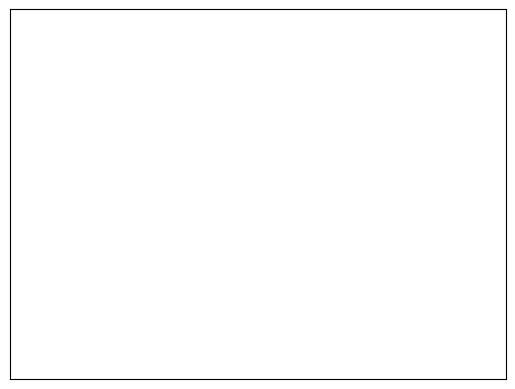

In [10]:
res=backgating_assessment(adata=adata,                          
                      image_folder='processed',
                      pop_obs='population_broad',
                      cells_per_group=100,
                      radius=20,
                      minimum=0.6,
                      max_quantile='q0.99',
                      mode='load_markers',
                      number_top_markers=2,
                      markers_exclude=['CD66b','Met'],
                      specify_blue='DNA1',
                      overview_images=False,
                      hide_cell_titles=True
                     )

In [ ]:
mikeimc_v2.backgating(adata=adata,
           cell_index=list(adata[adata.obs.population_broad=='Microglia, resting'].obs['Master_Index'].sample(5)),
           radius=15,
          image_folder='processed',
          red='iba1',
          green='p2ry12',
          blue='cd163',
          use_masks='mask_dict.csv',
          output_folder='test1',
          green_range=(0.6,8),
          blue_range=(0.4,8),
          red_range=(0.4,20),
          overview_images=True,
          save_subfolder='test')

In [ ]:
mikeimc_v2.backgating_assessment(adata=adata,                          
                      image_folder='processed',
                      pop_obs='population_broad',
                      cells_per_group=25,
                      radius=15,
                      minimum=0.6,
                      max_quantile='q0.99',
                      mode='full',
                      number_top_markers=2,
                      markers_exclude=['CD66b','Met'],
                      specify_blue='DNA1',
                      output_folder='test1'
                     )

In [ ]:
import tkinter as tk
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from skimage import io

def on_yes():
    global answer
    answer = True
    window.destroy()

def on_no():
    global answer
    answer = False
    window.destroy()
    
def show_figure(fig, title='Backgating'):
   
    global window
    global answer
    
    window = tk.Tk()
    window.title(title)

    canvas = FigureCanvasTkAgg(fig, master=window)
    canvas.get_tk_widget().pack(side="top", fill="both", expand=1)

    yes_button = tk.Button(master=window, text="Yes", command=on_yes)
    yes_button.pack(side="left")
    
    no_button = tk.Button(master=window, text="No", command=on_no)
    no_button.pack(side="left")
    
    window.eval('tk::PlaceWindow . center')
    window.lift()

    window.mainloop()



In [ ]:
import tkinter as tk
from tkinter import colorchooser

def choose_colors(color_dict, item, result_labels):
    color = colorchooser.askcolor(title=f"Choose color for {item}", initialcolor=color_dict[item])[1]
    color_dict[item] = color
    result_labels[item].config(bg=color)

def show_colors(color_dict):
    result = tk.Tk()
    result.title("Selected colors")
    result_labels = {}
    for item in color_dict.keys():
        result_labels[item] = tk.Label(result, text=f"{item}:", bg=color_dict[item])
        result_labels[item].pack()
    tk.Button(result, text="OK", command=result.destroy).pack()
    for item in color_dict.keys():
        tk.Button(result, text=item, command=lambda item=item: choose_colors(color_dict, item, result_labels)).pack()
    result.mainloop()

#color_dict = {'item1': 'red', 'item2': 'green', 'item3': 'blue'}
root = tk.Tk()
root.title("Color chooser")
tk.Button(root, text="Choose colors", command=lambda: show_colors(color_dict)).pack()
root.mainloop()
